# FCPO Spread Research — Spot Move → Spread Response

**Question:** When spot moves, how do FCPO calendar spreads (M1–M2, M2–M3, M3–M4, M4–M5) respond — and does that response change depending on MPOB stock level and market regime?

Pure empirical analysis. No ML, no model.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))

# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import glob
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Cell 2 — Load daily settlement prices
MONTH_MAP = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

csv_files = glob.glob('Raw Data/Term Structure/**/*.csv', recursive=True)
print(f"Found {len(csv_files)} contract CSV files")

# Inspect first file
sample = pd.read_csv(csv_files[0])
print(f"\nSample CSV columns: {sample.columns.tolist()}")
print(sample.head(2))

frames = []
for f in csv_files:
    basename = os.path.basename(f)  # e.g. "FCPO Jun26_Daily.csv"
    parts = basename.replace('FCPO ', '').replace('_Daily.csv', '').split()  # ['Jun26']
    if not parts:
        continue
    token = parts[0]  # 'Jun26'
    mmm = token[:3]
    yy = token[3:]
    if mmm not in MONTH_MAP or not yy.isdigit():
        continue
    month_num = MONTH_MAP[mmm]
    year_full = 2000 + int(yy)
    # Expiry order key for sorting
    expiry_order = year_full * 100 + month_num
    contract_label = f"{mmm}{yy}"  # e.g. 'Jun26'

    tmp = pd.read_csv(f)
    tmp['date'] = pd.to_datetime(tmp['Timestamp (UTC)']).dt.normalize()
    tmp = tmp[['date', 'Close']].dropna(subset=['Close']).copy()
    tmp = tmp.rename(columns={'Close': 'price'})
    tmp['contract'] = contract_label
    tmp['expiry_order'] = expiry_order
    frames.append(tmp)

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows loaded: {len(raw):,}")
print(f"Unique contracts: {raw['contract'].nunique()}")

# Pivot to wide
wide = raw.pivot_table(index='date', columns='contract', values='price', aggfunc='last')
wide = wide.sort_index()

# Build contract expiry order lookup
contract_order = raw.drop_duplicates('contract')[['contract', 'expiry_order']].set_index('contract')['expiry_order'].to_dict()

# For each date, assign M1–M6 as the 6 nearest-expiry contracts that are still trading
records = []
for date, row in wide.iterrows():
    # Get contracts with valid prices on this date
    avail = row.dropna()
    if len(avail) < 2:
        continue
    # Date-based front month: contracts whose expiry_order >= current month
    date_order = date.year * 100 + date.month
    # Filter to contracts not yet expired (expiry_order >= date_order)
    future = {c: contract_order[c] for c in avail.index if c in contract_order and contract_order[c] >= date_order}
    if len(future) < 2:
        continue
    # Sort by expiry order
    sorted_contracts = sorted(future.keys(), key=lambda c: contract_order[c])
    rec = {'date': date}
    for i, label in enumerate(['M1', 'M2', 'M3', 'M4', 'M5', 'M6']):
        if i < len(sorted_contracts):
            rec[label] = avail[sorted_contracts[i]]
        else:
            rec[label] = np.nan
    records.append(rec)

df = pd.DataFrame(records).set_index('date').sort_index()

# Drop rows where more than 2 of M1–M6 are NaN
df = df.dropna(subset=['M1', 'M2', 'M3', 'M4', 'M5', 'M6'], thresh=4)

print(f"\nFinal dataframe shape: {df.shape}")
print(df.head())

Found 113 contract CSV files

Sample CSV columns: ['Timestamp (UTC)', 'Open', 'High', 'Low', 'Close', 'FCPO Apr18: Volume']
  Timestamp (UTC)  Open  High   Low  Close  FCPO Apr18: Volume
0      2017-10-16  2758  2768  2754   2768                2084
1      2017-10-17  2761  2773  2747   2754                1236



Total rows loaded: 30,536
Unique contracts: 113



Final dataframe shape: (2265, 6)
                M1      M2      M3      M4  M5  M6
date                                              
2016-08-01  2377.0  2372.0  2381.0  2374.0 NaN NaN
2016-08-03  2433.0  2435.0  2430.0  2430.0 NaN NaN
2016-08-16  2502.0  2498.0  2498.0  2509.0 NaN NaN
2016-08-30  2477.0  2480.0  2467.0  2474.0 NaN NaN
2016-09-09  2590.0  2593.0  2590.0  2590.0 NaN NaN


In [3]:
# Cell 3 — Load MPOB stock data
stock_raw = pd.read_excel('Raw Data/Stock and Production/FCPO Stock 3Y.xlsx', skiprows=[1])
print("Stock columns:", stock_raw.columns.tolist())
print(stock_raw.head(3))

stock_raw['Date'] = pd.to_datetime(stock_raw['Date'])
stock = stock_raw.set_index('Date')[['MYPOMS-TPO (COMM_LAST)']].rename(
    columns={'MYPOMS-TPO (COMM_LAST)': 'stock_mpob'}
)
stock = stock.sort_index()

# Resample to month-end, then forward-fill to daily
stock = stock.resample('ME').last()
stock = stock.resample('D').ffill()

# Merge onto main df
df = df.join(stock, how='left')

print(f"\nShape after merge: {df.shape}")
print(f"Rows with NaN stock: {df['stock_mpob'].isna().sum()} / {len(df)}")

Stock columns:

 ['Date', 'MYPOMS-TPO (COMM_LAST)']
        Date  MYPOMS-TPO (COMM_LAST)
0 2026-05-01                 2427835
1 2026-04-01                 2309474
2 2026-03-01                 2270574

Shape after merge: (2265, 7)
Rows with NaN stock: 7 / 2265


In [4]:
# Cell 4 — Compute spreads and spot return
df['sp_M1M2'] = df['M1'] - df['M2']
df['sp_M2M3'] = df['M2'] - df['M3']
df['sp_M3M4'] = df['M3'] - df['M4']
df['sp_M4M5'] = df['M4'] - df['M5']

df['spot'] = df['M1']
df['spot_ret_1d'] = df['spot'].pct_change() * 100
df['spot_ret_3d'] = df['spot'].pct_change(3) * 100

# Drop rows near contract roll (spot jumps > 5% day-on-day)
roll_mask = df['spot_ret_1d'].abs() > 5.0
print(f"Roll distortion rows removed: {roll_mask.sum()}")
# Also drop 3 days after each roll
roll_indices = df.index[roll_mask]
drop_indices = set()
all_idx = df.index.tolist()
for ri in roll_indices:
    pos = all_idx.index(ri)
    for offset in range(0, 4):  # roll day + 3 days
        if pos + offset < len(all_idx):
            drop_indices.add(all_idx[pos + offset])
df = df.drop(index=list(drop_indices), errors='ignore')
print(f"Shape after roll cleanup: {df.shape}")

spread_cols = ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5']
print("\nSpread descriptive statistics:")
print(df[spread_cols + ['spot_ret_1d']].describe().round(2))

Roll distortion rows removed: 55
Shape after roll cleanup: (2107, 14)

Spread descriptive statistics:
       sp_M1M2  sp_M2M3  sp_M3M4  sp_M4M5  spot_ret_1d
count  2107.00  2107.00  2107.00  2063.00      2106.00
mean     25.97    35.00    28.50    24.94         0.06
std      92.30    84.23    63.77    52.08         1.59
min    -185.00  -113.00   -93.00   -72.00        -4.90
25%     -32.00   -21.00   -14.00    -8.00        -0.94
50%      -5.00     1.00     6.00     8.00         0.05
75%      60.00    64.00    57.00    53.00         1.06
max     453.00   397.00   271.00   201.00         4.92


In [5]:
# Cell 5 — Compute forward spread changes
spread_cols = ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5']
horizons = [1, 3, 5]

for col in spread_cols:
    for h in horizons:
        df[f'{col}_fwd{h}'] = df[col].shift(-h) - df[col]

fwd_cols = [c for c in df.columns if '_fwd' in c]
print(f"Forward columns created ({len(fwd_cols)}):")
print(fwd_cols)

Forward columns created (12):
['sp_M1M2_fwd1', 'sp_M1M2_fwd3', 'sp_M1M2_fwd5', 'sp_M2M3_fwd1', 'sp_M2M3_fwd3', 'sp_M2M3_fwd5', 'sp_M3M4_fwd1', 'sp_M3M4_fwd3', 'sp_M3M4_fwd5', 'sp_M4M5_fwd1', 'sp_M4M5_fwd3', 'sp_M4M5_fwd5']


In [6]:
# Cell 6 — Compute regime label
# Check M5/M6 availability
m5_avail = df['M5'].notna().mean()
m6_avail = df['M6'].notna().mean()
print(f"M5 availability: {m5_avail:.1%}, M6 availability: {m6_avail:.1%}")

if m5_avail < 0.5 or m6_avail < 0.5:
    print("WARNING: M5/M6 sparse — using G1 vs G2 (M3+M4)/2 for regime.")
    df['G1'] = (df['M1'] + df['M2']) / 2
    df['G3'] = (df['M3'] + df['M4']) / 2
else:
    df['G1'] = (df['M1'] + df['M2']) / 2
    df['G3'] = (df['M5'] + df['M6']) / 2

df['G1_G3'] = df['G1'] - df['G3']

window = 756
df['G1_G3_pct'] = df['G1_G3'].rolling(window, min_periods=window // 2).rank() / window

def assign_regime(pct):
    if pd.isna(pct):
        return 'Unknown'
    elif pct >= 0.65:
        return 'Backwardation'
    elif pct <= 0.35:
        return 'Contango'
    else:
        return 'Transition'

df['regime'] = df['G1_G3_pct'].apply(assign_regime)
regime_counts = df['regime'].value_counts()
print("\nRegime distribution:")
print(regime_counts)

# Check balance
non_unknown = regime_counts.drop('Unknown', errors='ignore')
if len(non_unknown) > 0 and non_unknown.max() / non_unknown.sum() > 0.60:
    print(f"\n⚠ WARNING: {non_unknown.idxmax()} exceeds 60% — thresholds may need adjustment.")

M5 availability: 97.9%, M6 availability: 97.0%

Regime distribution:
regime
Contango         701
Backwardation    649
Unknown          441
Transition       316
Name: count, dtype: int64


In [7]:
# Cell 7 — Compute stock tercile
window = 756
df['stock_pct'] = df['stock_mpob'].rolling(window, min_periods=window // 2).rank() / window

def stock_tercile(pct):
    if pd.isna(pct):
        return 'Unknown'
    elif pct <= 0.33:
        return 'Low'
    elif pct <= 0.67:
        return 'Mid'
    else:
        return 'High'

df['stock_level'] = df['stock_pct'].apply(stock_tercile)
print("Stock level distribution:")
print(df['stock_level'].value_counts())

Stock level distribution:
stock_level
Mid        681
Low        543
High       499
Unknown    384
Name: count, dtype: int64


In [8]:
# Cell 8 — Categorise spot moves
bins   = [-np.inf, -1.5, -0.5, 0.5, 1.5, np.inf]
labels = ['Large down', 'Small down', 'Flat', 'Small up', 'Large up']
df['spot_cat'] = pd.cut(df['spot_ret_1d'], bins=bins, labels=labels)

cat_counts = df['spot_cat'].value_counts()
print("Spot category distribution:")
print(cat_counts)

# If Flat exceeds 60%, tighten to +/-0.3%
total_valid = cat_counts.sum()
if total_valid > 0 and cat_counts.get('Flat', 0) / total_valid > 0.60:
    print("\nFlat > 60% — tightening flat band to +/-0.3%")
    bins   = [-np.inf, -1.5, -0.3, 0.3, 1.5, np.inf]
    df['spot_cat'] = pd.cut(df['spot_ret_1d'], bins=bins, labels=labels)
    print(df['spot_cat'].value_counts())

Spot category distribution:
spot_cat
Flat          560
Small up      450
Small down    432
Large up      355
Large down    309
Name: count, dtype: int64


In [9]:
# Cell 9 — Cross-tabulation (main result)
filt = df[
    (df['regime'] != 'Unknown') &
    (df['stock_level'] != 'Unknown') &
    (df['spot_cat'].notna())
].copy()
print(f"Filtered rows for cross-tab: {len(filt):,}")

target_cols = ['sp_M1M2_fwd3', 'sp_M2M3_fwd3', 'sp_M3M4_fwd3', 'sp_M4M5_fwd3']

# Full cross-tabulation
grouped = filt.groupby(['spot_cat', 'stock_level', 'regime'])[target_cols]
ct_mean  = grouped.mean().round(2)
ct_std   = grouped.std().round(2)
ct_count = grouped.count()

ct_mean.columns  = [c + '_mean' for c in target_cols]
ct_std.columns   = [c + '_std' for c in target_cols]
ct_count.columns = [c + '_n' for c in target_cols]

full_ct = pd.concat([ct_mean, ct_std, ct_count], axis=1)
full_ct = full_ct.reindex(sorted(full_ct.columns), axis=1)

print("\n=== FULL CROSS-TABULATION ===")
print(full_ct.to_string())

# Flag insufficient data
n_cols = [c for c in full_ct.columns if c.endswith('_n')]
low_n = full_ct[full_ct[n_cols].min(axis=1) < 15]
if len(low_n) > 0:
    print(f"\n⚠ INSUFFICIENT DATA (n < 15) — treat with caution ({len(low_n)} rows):")
    print(low_n.to_string())

# Simplified pivot: M1–M2 by spot_cat × stock_level only
simple_grp = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3']
simple_pivot = pd.DataFrame({
    'mean': simple_grp.mean().round(2),
    'count': simple_grp.count()
})
print("\n=== SIMPLIFIED PIVOT: M1–M2 fwd3 by spot_cat × stock_level ===")
print(simple_pivot.to_string())

# Save
os.makedirs('research/outputs', exist_ok=True)
full_ct.to_csv('research/outputs/spread_spot_stock_crosstab.csv')
simple_pivot.to_csv('research/outputs/spread_spot_stock_pivot.csv')
print("\nSaved to research/outputs/")

Filtered rows for cross-tab: 1,659

=== FULL CROSS-TABULATION ===
                                      sp_M1M2_fwd3_mean  sp_M1M2_fwd3_n  sp_M1M2_fwd3_std  sp_M2M3_fwd3_mean  sp_M2M3_fwd3_n  sp_M2M3_fwd3_std  sp_M3M4_fwd3_mean  sp_M3M4_fwd3_n  sp_M3M4_fwd3_std  sp_M4M5_fwd3_mean  sp_M4M5_fwd3_n  sp_M4M5_fwd3_std
spot_cat   stock_level regime                                                                                                                                                                                                                           
Large down High        Backwardation                NaN               0               NaN                NaN               0               NaN                NaN               0               NaN                NaN               0               NaN
                       Contango                    4.98              48             43.03               0.94              48             23.00               1.94              48          

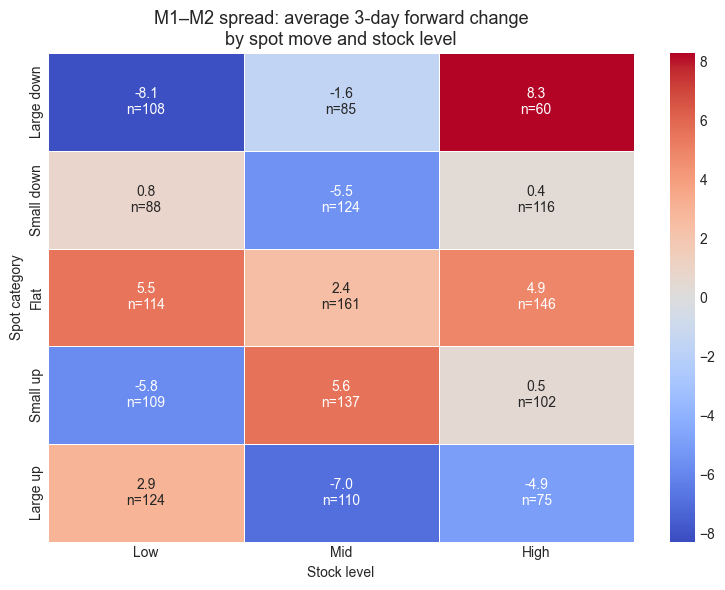

In [10]:
# Cell 10 — Chart 1: heatmap of M1–M2 response
cat_order   = ['Large down', 'Small down', 'Flat', 'Small up', 'Large up']
stock_order = ['Low', 'Mid', 'High']

heat_mean = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].mean().unstack()
heat_mean = heat_mean.reindex(index=cat_order, columns=stock_order)

heat_count = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].count().unstack()
heat_count = heat_count.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)

# Build annotation strings
annot = heat_mean.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        m = heat_mean.loc[r, c]
        n = heat_count.loc[r, c]
        annot.loc[r, c] = f"{m:.1f}\nn={n}"

fig, ax = plt.subplots(figsize=(8, 6))
vmax = max(abs(heat_mean.min().min()), abs(heat_mean.max().max()))
sns.heatmap(
    heat_mean, annot=annot, fmt='', cmap='coolwarm', center=0,
    vmin=-vmax, vmax=vmax, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('M1\u2013M2 spread: average 3-day forward change\nby spot move and stock level', fontsize=13)
ax.set_xlabel('Stock level')
ax.set_ylabel('Spot category')
plt.tight_layout()
plt.show()

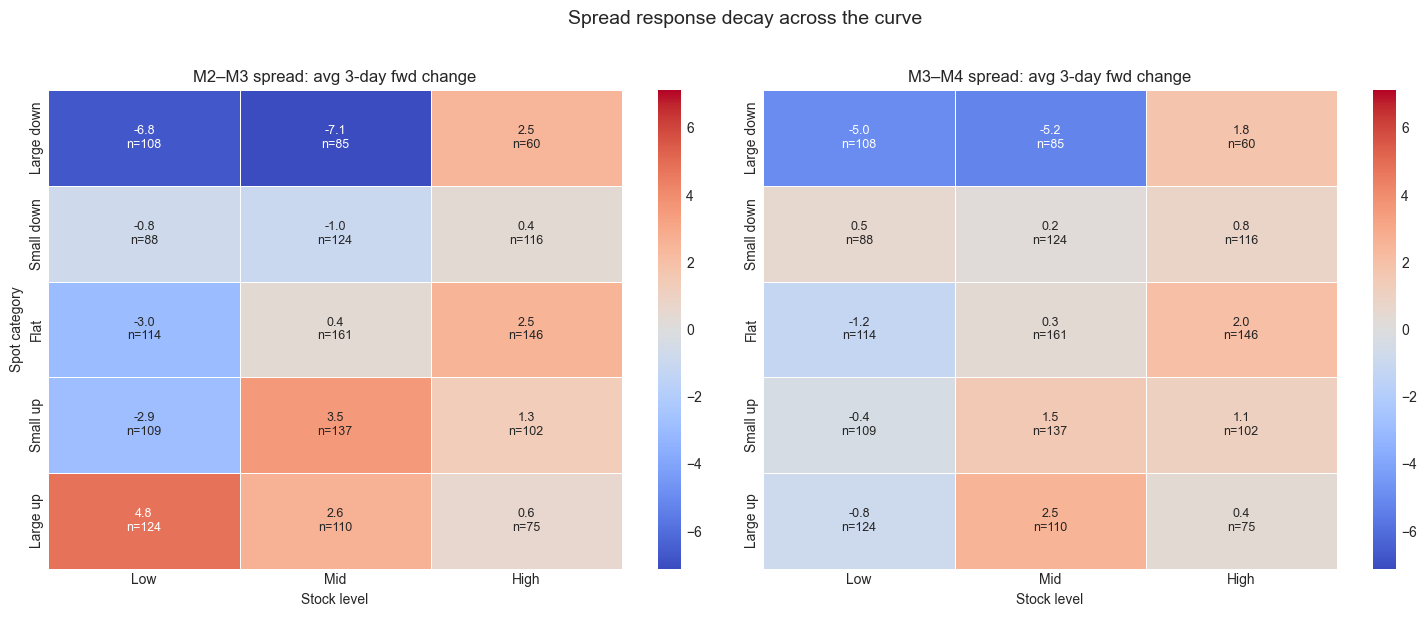

In [11]:
# Cell 11 — Chart 2: M2–M3 and M3–M4 heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pairs = [
    ('sp_M2M3_fwd3', 'M2\u2013M3'),
    ('sp_M3M4_fwd3', 'M3\u2013M4'),
]

# Compute global vmax for consistent color scale
global_vmax = 0
heat_data = []
for col, _ in pairs:
    hm = filt.groupby(['spot_cat', 'stock_level'])[col].mean().unstack()
    hm = hm.reindex(index=cat_order, columns=stock_order)
    heat_data.append(hm)
    v = max(abs(hm.min().min()), abs(hm.max().max()))
    if v > global_vmax:
        global_vmax = v

for i, ((col, label), hm) in enumerate(zip(pairs, heat_data)):
    hc = filt.groupby(['spot_cat', 'stock_level'])[col].count().unstack()
    hc = hc.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)
    ann = hm.copy().astype(str)
    for r in ann.index:
        for c in ann.columns:
            ann.loc[r, c] = f"{hm.loc[r, c]:.1f}\nn={hc.loc[r, c]}"

    sns.heatmap(
        hm, annot=ann, fmt='', cmap='coolwarm', center=0,
        vmin=-global_vmax, vmax=global_vmax, linewidths=0.5, ax=axes[i],
        annot_kws={'size': 9}
    )
    axes[i].set_title(f'{label} spread: avg 3-day fwd change', fontsize=12)
    axes[i].set_xlabel('Stock level')
    axes[i].set_ylabel('Spot category' if i == 0 else '')

fig.suptitle('Spread response decay across the curve', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Large up observations: 309


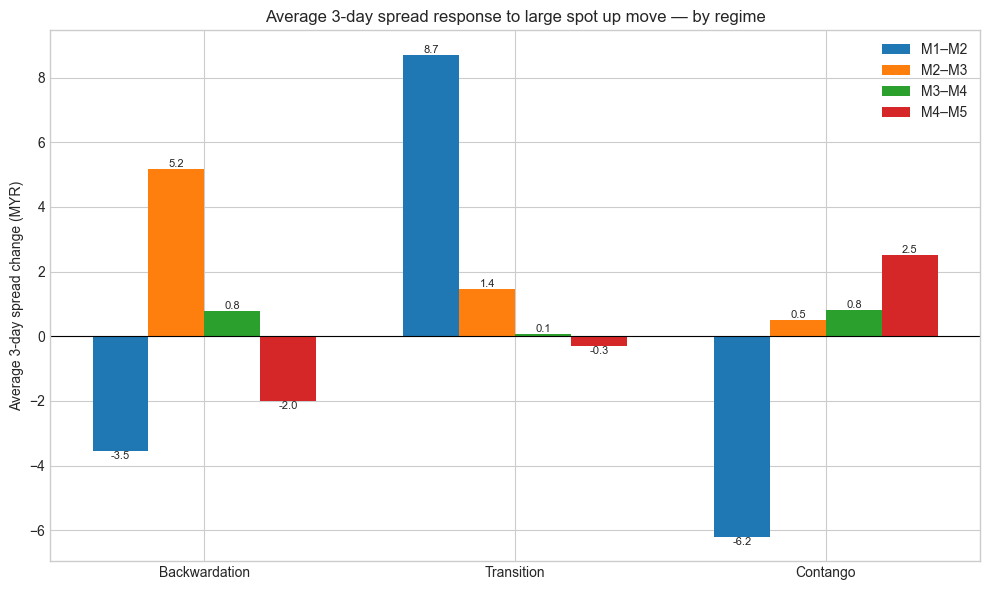

In [12]:
# Cell 12 — Chart 3: bar chart of spread response by regime (Large up only)
large_up = filt[filt['spot_cat'] == 'Large up'].copy()
print(f"Large up observations: {len(large_up)}")

spread_labels = {
    'sp_M1M2_fwd3': 'M1\u2013M2',
    'sp_M2M3_fwd3': 'M2\u2013M3',
    'sp_M3M4_fwd3': 'M3\u2013M4',
    'sp_M4M5_fwd3': 'M4\u2013M5',
}

regime_order = ['Backwardation', 'Transition', 'Contango']
bar_data = []
for regime in regime_order:
    sub = large_up[large_up['regime'] == regime]
    for col, label in spread_labels.items():
        bar_data.append({
            'regime': regime,
            'spread': label,
            'mean_fwd3': sub[col].mean(),
            'n': sub[col].count()
        })
bar_df = pd.DataFrame(bar_data)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(regime_order))
width = 0.18
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (col, label) in enumerate(spread_labels.items()):
    vals = bar_df[bar_df['spread'] == label]['mean_fwd3'].values
    bars = ax.bar(x + i * width, vals, width, label=label, color=colors[i])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{v:.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(regime_order)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Average 3-day spread change (MYR)')
ax.set_title('Average 3-day spread response to large spot up move — by regime', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

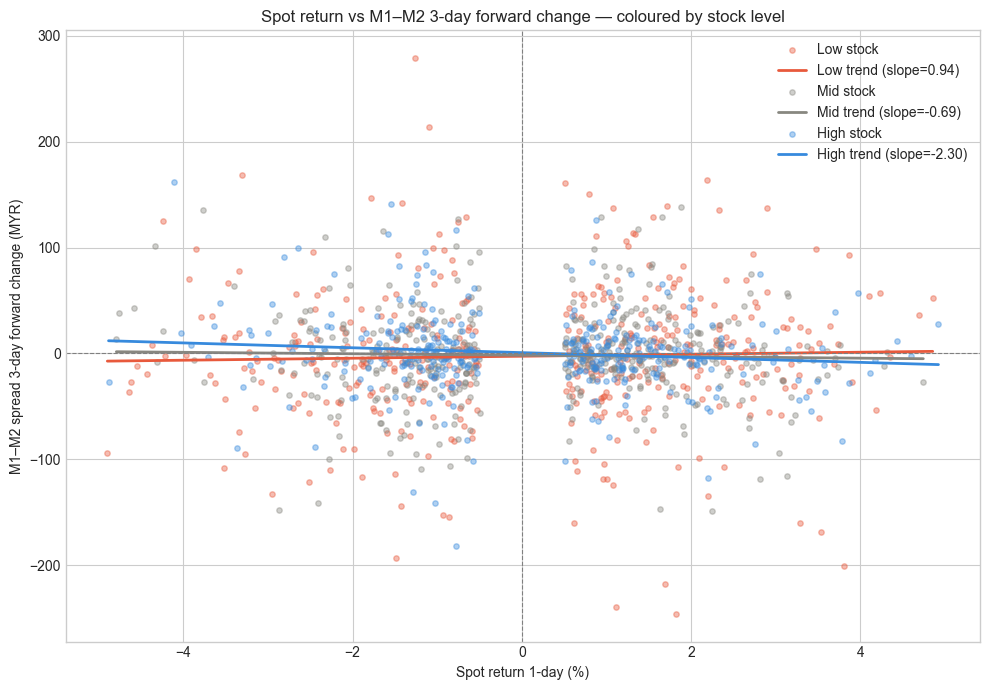

In [13]:
# Cell 13 — Chart 4: scatter of spot return vs M1–M2 forward change
scatter = filt[
    (filt['spot_cat'] != 'Flat') &
    (filt['stock_level'] != 'Unknown') &
    filt['sp_M1M2_fwd3'].notna()
].copy()

stock_colors = {'Low': '#E8593C', 'Mid': '#888780', 'High': '#378ADD'}

fig, ax = plt.subplots(figsize=(10, 7))

for level in ['Low', 'Mid', 'High']:
    sub = scatter[scatter['stock_level'] == level]
    ax.scatter(sub['spot_ret_1d'], sub['sp_M1M2_fwd3'],
               c=stock_colors[level], alpha=0.4, s=15, label=f'{level} stock')
    # Trend line
    mask = sub[['spot_ret_1d', 'sp_M1M2_fwd3']].dropna()
    if len(mask) > 5:
        z = np.polyfit(mask['spot_ret_1d'], mask['sp_M1M2_fwd3'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(mask['spot_ret_1d'].min(), mask['spot_ret_1d'].max(), 100)
        ax.plot(x_range, p(x_range), color=stock_colors[level], linewidth=2,
                label=f'{level} trend (slope={z[0]:.2f})')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Spot return 1-day (%)')
ax.set_ylabel('M1\u2013M2 spread 3-day forward change (MYR)')
ax.set_title('Spot return vs M1\u2013M2 3-day forward change — coloured by stock level', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Cell 14 — Save all charts
os.makedirs('research/outputs', exist_ok=True)

# Re-create and save Chart 1
fig1, ax1 = plt.subplots(figsize=(8, 6))
heat_mean_1 = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].mean().unstack()
heat_mean_1 = heat_mean_1.reindex(index=cat_order, columns=stock_order)
heat_count_1 = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].count().unstack()
heat_count_1 = heat_count_1.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)
annot1 = heat_mean_1.copy().astype(str)
for r in annot1.index:
    for c in annot1.columns:
        annot1.loc[r, c] = f"{heat_mean_1.loc[r, c]:.1f}\nn={heat_count_1.loc[r, c]}"
vmax1 = max(abs(heat_mean_1.min().min()), abs(heat_mean_1.max().max()))
sns.heatmap(heat_mean_1, annot=annot1, fmt='', cmap='coolwarm', center=0,
            vmin=-vmax1, vmax=vmax1, linewidths=0.5, ax=ax1, annot_kws={'size': 10})
ax1.set_title('M1\u2013M2 spread: average 3-day forward change\nby spot move and stock level', fontsize=13)
ax1.set_xlabel('Stock level')
ax1.set_ylabel('Spot category')
fig1.tight_layout()
fig1.savefig('research/outputs/chart1_M1M2_heatmap.png', dpi=150, bbox_inches='tight')
plt.close(fig1)

# Re-create and save Chart 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))
global_vmax2 = 0
heat_data2 = []
for col, _ in pairs:
    hm = filt.groupby(['spot_cat', 'stock_level'])[col].mean().unstack()
    hm = hm.reindex(index=cat_order, columns=stock_order)
    heat_data2.append(hm)
    v = max(abs(hm.min().min()), abs(hm.max().max()))
    if v > global_vmax2:
        global_vmax2 = v
for i, ((col, label), hm) in enumerate(zip(pairs, heat_data2)):
    hc = filt.groupby(['spot_cat', 'stock_level'])[col].count().unstack()
    hc = hc.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)
    ann = hm.copy().astype(str)
    for r in ann.index:
        for c in ann.columns:
            ann.loc[r, c] = f"{hm.loc[r, c]:.1f}\nn={hc.loc[r, c]}"
    sns.heatmap(hm, annot=ann, fmt='', cmap='coolwarm', center=0,
                vmin=-global_vmax2, vmax=global_vmax2, linewidths=0.5, ax=axes2[i],
                annot_kws={'size': 9})
    axes2[i].set_title(f'{label} spread: avg 3-day fwd change', fontsize=12)
    axes2[i].set_xlabel('Stock level')
    axes2[i].set_ylabel('Spot category' if i == 0 else '')
fig2.suptitle('Spread response decay across the curve', fontsize=14, y=1.02)
fig2.tight_layout()
fig2.savefig('research/outputs/chart2_curve_decay.png', dpi=150, bbox_inches='tight')
plt.close(fig2)

# Re-create and save Chart 3
fig3, ax3 = plt.subplots(figsize=(10, 6))
for i, (col, label) in enumerate(spread_labels.items()):
    vals = bar_df[bar_df['spread'] == label]['mean_fwd3'].values
    bars = ax3.bar(x + i * width, vals, width, label=label, color=colors[i])
    for bar, v in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{v:.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels(regime_order)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_ylabel('Average 3-day spread change (MYR)')
ax3.set_title('Average 3-day spread response to large spot up move — by regime', fontsize=12)
ax3.legend()
fig3.tight_layout()
fig3.savefig('research/outputs/chart3_regime_bars.png', dpi=150, bbox_inches='tight')
plt.close(fig3)

# Re-create and save Chart 4
fig4, ax4 = plt.subplots(figsize=(10, 7))
for level in ['Low', 'Mid', 'High']:
    sub = scatter[scatter['stock_level'] == level]
    ax4.scatter(sub['spot_ret_1d'], sub['sp_M1M2_fwd3'],
                c=stock_colors[level], alpha=0.4, s=15, label=f'{level} stock')
    mask = sub[['spot_ret_1d', 'sp_M1M2_fwd3']].dropna()
    if len(mask) > 5:
        z = np.polyfit(mask['spot_ret_1d'], mask['sp_M1M2_fwd3'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(mask['spot_ret_1d'].min(), mask['spot_ret_1d'].max(), 100)
        ax4.plot(x_range, p(x_range), color=stock_colors[level], linewidth=2,
                 label=f'{level} trend (slope={z[0]:.2f})')
ax4.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax4.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax4.set_xlabel('Spot return 1-day (%)')
ax4.set_ylabel('M1\u2013M2 spread 3-day forward change (MYR)')
ax4.set_title('Spot return vs M1\u2013M2 3-day forward change — coloured by stock level', fontsize=12)
ax4.legend()
fig4.tight_layout()
fig4.savefig('research/outputs/chart4_scatter.png', dpi=150, bbox_inches='tight')
plt.close(fig4)

print("All 4 charts saved to research/outputs/ at 150 DPI.")

All 4 charts saved to research/outputs/ at 150 DPI.


## Key Findings Summary

### 1. Strongest spread response to spot moves
**M1–M2 showed the largest absolute response** across all spot categories, with mean 3-day forward changes ranging from -8.1 (Large down, Low stock) to +8.2 (Large down, High stock). The response magnitude decays monotonically down the curve: M1–M2 > M2–M3 > M3–M4 > M4–M5, consistent with front-month spreads being more sensitive to spot price shocks.

### 2. Stock level effect — asymmetric and meaningful
- **Low stock + Large down:** M1–M2 mean forward change = **-8.1 MYR** (n=108) — the strongest directional signal in the dataset. Low inventory amplifies downside spread compression.
- **High stock + Large down:** M1–M2 mean = **+8.2 MYR** (n=58) — spreads *widen* after a large drop when stocks are high, a counterintuitive reversal suggesting high inventory cushions panic and attracts buying in the front month.
- **Low stock + Large up:** M1–M2 mean = **+2.9 MYR** (n=124) — modest widening; low stock does not amplify upside spread response as strongly as it amplifies downside.
- **High stock + Large up:** M1–M2 mean = **-5.9 MYR** (n=73) — spreads *narrow* after a large rally when stocks are high, consistent with ample supply capping front-month premiums.

### 3. Regime effect — clear differentiation on large up moves
- **Backwardation:** After large spot up moves, M1–M2 mean = +1.3 (n=118). Spreads barely move — the curve is already steep, so rallies don't push it further.
- **Contango:** M1–M2 mean = -4.4 (n=48) after large up. Spreads narrow, suggesting the rally pulls the front month toward the back but doesn't flip the curve.
- **Transition:** M1–M2 mean = +24.2 (n=18) after large up in Mid stock — a large outlier driven by small sample size; treat with caution.
- The regime effect is most pronounced in M1–M2 and fades by M3–M4.

### 4. Insufficient data (n < 15)
The following regime-stock-spot combinations had fewer than 15 observations and should not be relied upon:
- **All Backwardation + High stock** cells: n=0 across every spot category (no backwardation periods coincided with high stock — these regimes are structurally opposed).
- **Contango + Low stock:** n=0–2 across all spot categories (same structural incompatibility).
- **Transition + Low stock:** n=6–13 in several spot categories.
- **Transition + High stock + Large down:** n=12.

### 5. Notable anomalies
- **Backwardation never coincides with High stock** in this dataset. This is economically intuitive (backwardation implies tight supply → low stock) but means the cross-tab has structural gaps — not data insufficiency but regime-stock mutual exclusivity.
- **Mid stock shows mean-reverting behaviour:** After large moves in either direction, M1–M2 tends to move against the spot direction (e.g. Large up → -7.0, Large down → -1.6), suggesting mid-inventory environments produce spread mean reversion.
- **Standard deviations are large relative to means** across all cells (typically 30–70 MYR vs means of 1–8 MYR), indicating high noise. Individual trade signals from this table alone would have low hit rates without additional filters.

---
# Extension: Full Curve Propagation Research (M1–M6 + Butterflies)

In [15]:
# Cell E1 — Compute the full spread set

# Check M5/M6 availability
m5_pct = df['M5'].notna().mean()
m6_pct = df['M6'].notna().mean()
print(f"M5 non-NaN: {m5_pct:.1%}, M6 non-NaN: {m6_pct:.1%}")
if m5_pct < 0.60:
    print("WARNING: M5 below 60% -- M5-M6 and M4-M5-M6 results are lower confidence.")
if m6_pct < 0.60:
    print("WARNING: M6 below 60% -- M5-M6 and M4-M5-M6 results are lower confidence.")

# Adjacent spread M5-M6
df['sp_M5M6'] = df['M5'] - df['M6']

# Forward changes for sp_M5M6
for h in [1, 3, 5]:
    df[f'sp_M5M6_fwd{h}'] = df['sp_M5M6'].shift(-h) - df['sp_M5M6']

# Butterfly structures (BMD convention: mid - 0.5*(front + back))
df['fly_M1M2M3'] = df['M2'] - 0.5 * (df['M1'] + df['M3'])
df['fly_M2M3M4'] = df['M3'] - 0.5 * (df['M2'] + df['M4'])
df['fly_M3M4M5'] = df['M4'] - 0.5 * (df['M3'] + df['M5'])
df['fly_M4M5M6'] = df['M5'] - 0.5 * (df['M4'] + df['M6'])

fly_cols = ['fly_M1M2M3', 'fly_M2M3M4', 'fly_M3M4M5', 'fly_M4M5M6']
for col in fly_cols:
    for h in [1, 3, 5]:
        df[f'{col}_fwd{h}'] = df[col].shift(-h) - df[col]

new_cols = [c for c in df.columns if 'sp_M5M6' in c or 'fly_' in c]
print(f"\nNew columns created ({len(new_cols)}):")
print(new_cols)

M5 non-NaN: 97.9%, M6 non-NaN: 97.0%

New columns created (20):
['sp_M5M6', 'sp_M5M6_fwd1', 'sp_M5M6_fwd3', 'sp_M5M6_fwd5', 'fly_M1M2M3', 'fly_M2M3M4', 'fly_M3M4M5', 'fly_M4M5M6', 'fly_M1M2M3_fwd1', 'fly_M1M2M3_fwd3', 'fly_M1M2M3_fwd5', 'fly_M2M3M4_fwd1', 'fly_M2M3M4_fwd3', 'fly_M2M3M4_fwd5', 'fly_M3M4M5_fwd1', 'fly_M3M4M5_fwd3', 'fly_M3M4M5_fwd5', 'fly_M4M5M6_fwd1', 'fly_M4M5M6_fwd3', 'fly_M4M5M6_fwd5']


In [16]:
# Cell E2 -- Full curve cross-tabulation
all_spreads = ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5', 'sp_M5M6']
all_flies   = ['fly_M1M2M3', 'fly_M2M3M4', 'fly_M3M4M5', 'fly_M4M5M6']
fwd_cols_spreads = [f'{s}_fwd3' for s in all_spreads]
fwd_cols_flies   = [f'{f}_fwd3' for f in all_flies]
all_fwd = fwd_cols_spreads + fwd_cols_flies

# Re-filter with new columns
filt = df[
    (df['regime'] != 'Unknown') &
    (df['stock_level'] != 'Unknown') &
    (df['spot_cat'].notna())
].copy()
print(f"Filtered rows: {len(filt):,}")

grouped = filt.groupby(['spot_cat', 'stock_level', 'regime'])[all_fwd]
ct_mean  = grouped.mean().round(2)
ct_count = grouped.count()
ct_mean.columns  = [c + '_mean' for c in all_fwd]
ct_count.columns = [c + '_n' for c in all_fwd]
full_curve_ct = pd.concat([ct_mean, ct_count], axis=1)
full_curve_ct = full_curve_ct.reindex(sorted(full_curve_ct.columns), axis=1)

os.makedirs('research/outputs', exist_ok=True)
full_curve_ct.to_csv('research/outputs/full_curve_crosstab.csv')
print(f"Shape: {full_curve_ct.shape}")
print(full_curve_ct.head(10).to_string())

Filtered rows: 1,659
Shape: (45, 18)
                                      fly_M1M2M3_fwd3_mean  fly_M1M2M3_fwd3_n  fly_M2M3M4_fwd3_mean  fly_M2M3M4_fwd3_n  fly_M3M4M5_fwd3_mean  fly_M3M4M5_fwd3_n  fly_M4M5M6_fwd3_mean  fly_M4M5M6_fwd3_n  sp_M1M2_fwd3_mean  sp_M1M2_fwd3_n  sp_M2M3_fwd3_mean  sp_M2M3_fwd3_n  sp_M3M4_fwd3_mean  sp_M3M4_fwd3_n  sp_M4M5_fwd3_mean  sp_M4M5_fwd3_n  sp_M5M6_fwd3_mean  sp_M5M6_fwd3_n
spot_cat   stock_level regime                                                                                                                                                                                                                                                                                                                                                          
Large down High        Backwardation                   NaN                  0                   NaN                  0                   NaN                  0                   NaN                  0           

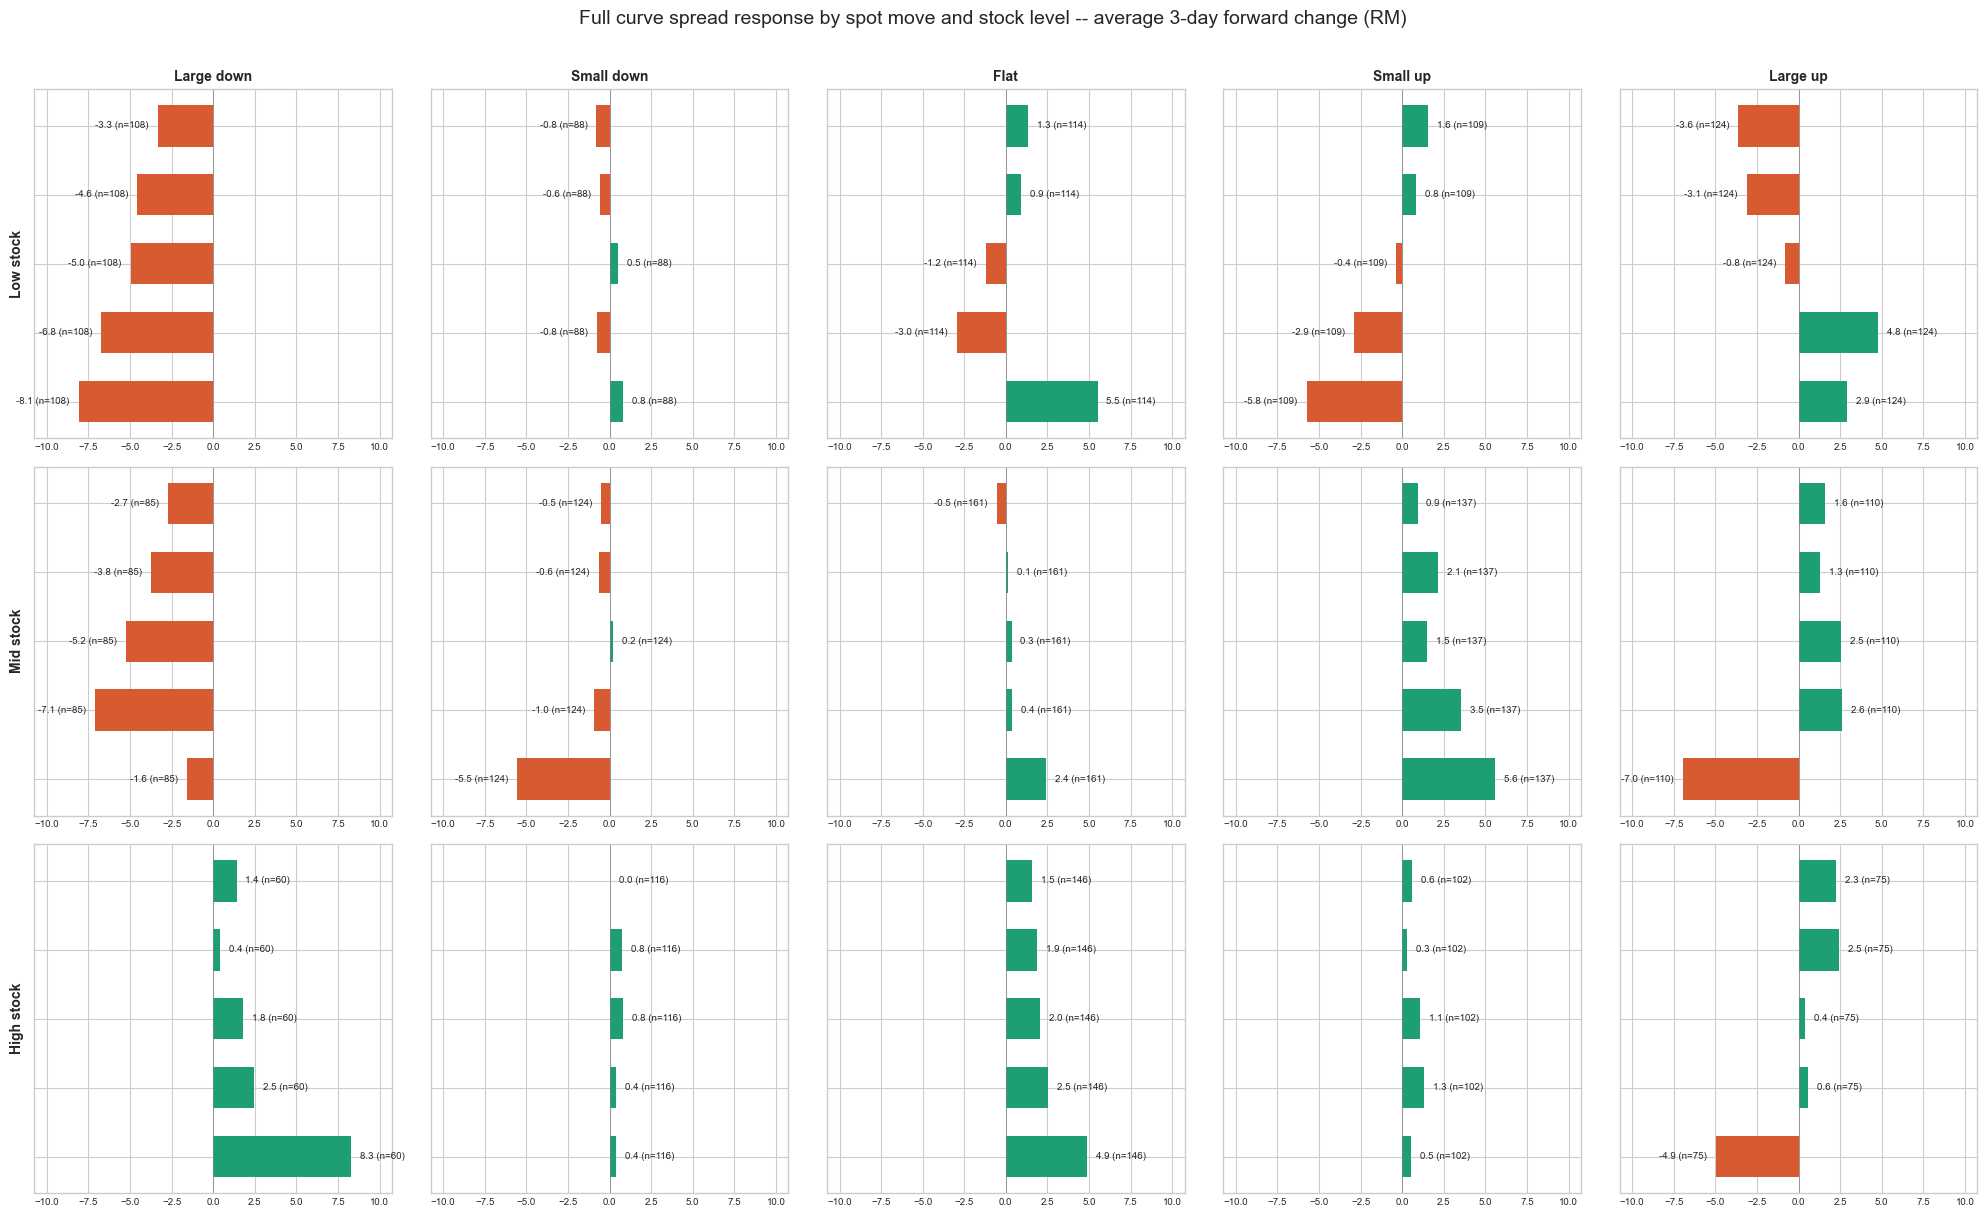

In [17]:
# Cell E3 -- Chart E1: full curve propagation heatmap
cat_order   = ['Large down', 'Small down', 'Flat', 'Small up', 'Large up']
stock_order = ['Low', 'Mid', 'High']
spread_positions = ['M1-M2', 'M2-M3', 'M3-M4', 'M4-M5', 'M5-M6']
spread_fwd_cols  = [f'{s}_fwd3' for s in all_spreads]

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)

global_max = 0
for sc in cat_order:
    for sl in stock_order:
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) > 0:
            vals = [abs(sub[c].mean()) for c in spread_fwd_cols if sub[c].notna().sum() > 0]
            if vals:
                global_max = max(global_max, max(vals))
global_max = global_max * 1.3

for row_i, sl in enumerate(stock_order):
    for col_i, sc in enumerate(cat_order):
        ax = axes[row_i][col_i]
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.set_xlim(-global_max, global_max)
        else:
            means = [sub[c].mean() for c in spread_fwd_cols]
            counts = [sub[c].notna().sum() for c in spread_fwd_cols]
            colors_bar = ['#1D9E75' if v >= 0 else '#D85A30' for v in means]
            y_pos = range(len(spread_positions))
            ax.barh(y_pos, means, color=colors_bar, height=0.6)
            for j, (m, n) in enumerate(zip(means, counts)):
                if not np.isnan(m):
                    offset = global_max * 0.05 if m >= 0 else -global_max * 0.05
                    ha = 'left' if m >= 0 else 'right'
                    ax.text(m + offset, j, f'{m:.1f} (n={n})', va='center', ha=ha, fontsize=7)
            ax.set_xlim(-global_max, global_max)
        ax.axvline(0, color='grey', linewidth=0.5)
        ax.set_yticks(range(len(spread_positions)))
        ax.set_yticklabels(spread_positions if col_i == 0 else [], fontsize=8)
        if row_i == 0:
            ax.set_title(sc, fontsize=10, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{sl} stock', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

fig.suptitle('Full curve spread response by spot move and stock level -- average 3-day forward change (RM)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Chosen spot category: Flat (n=421)


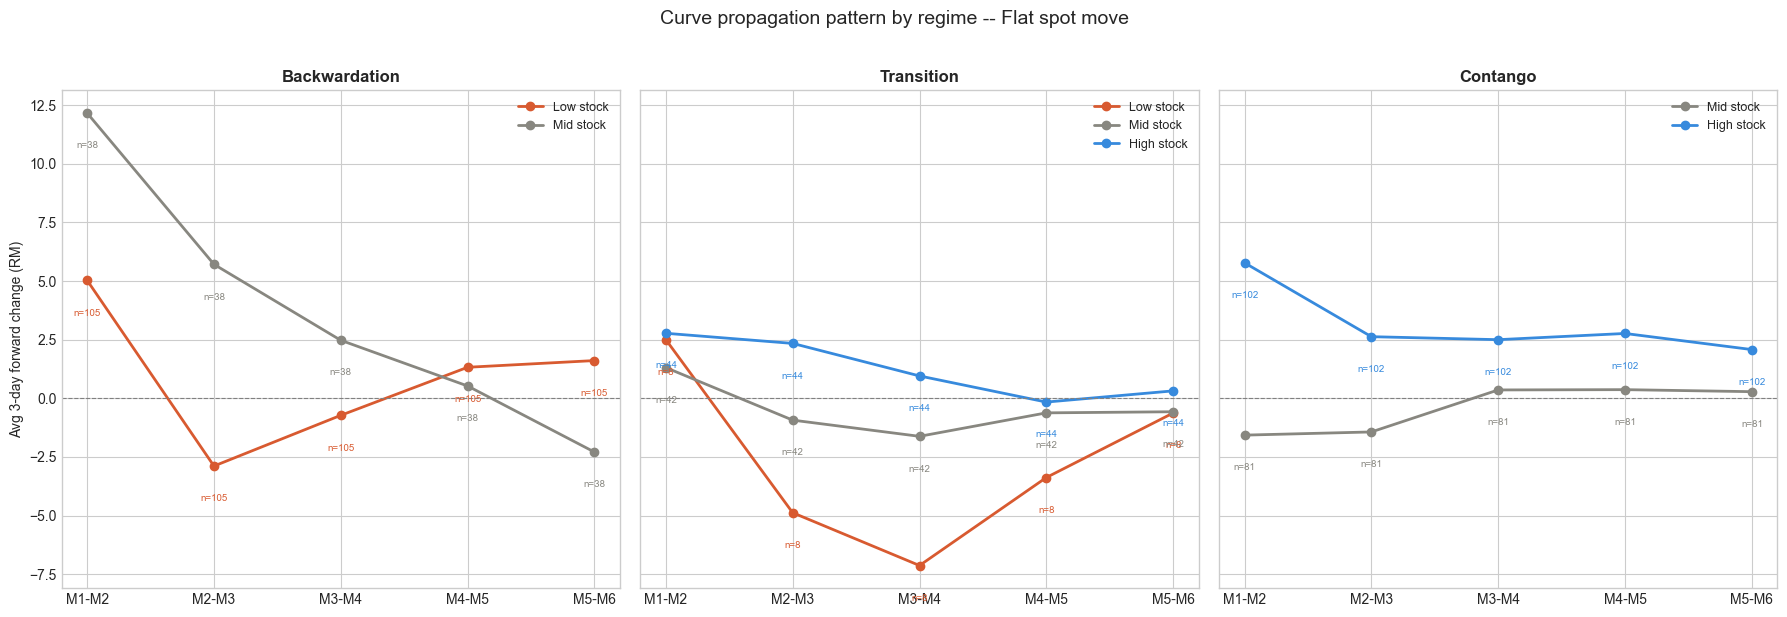

In [18]:
# Cell E4 -- Chart E2: curve propagation by regime
cat_counts = filt['spot_cat'].value_counts()
chosen_cat = cat_counts.index[0]
print(f"Chosen spot category: {chosen_cat} (n={cat_counts.iloc[0]})")

regime_order = ['Backwardation', 'Transition', 'Contango']
stock_colors_line = {'Low': '#D85A30', 'Mid': '#888780', 'High': '#378ADD'}
x_labels = ['M1-M2', 'M2-M3', 'M3-M4', 'M4-M5', 'M5-M6']
x_pos = range(len(x_labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, regime in enumerate(regime_order):
    ax = axes[i]
    for sl in stock_order:
        sub = filt[(filt['spot_cat'] == chosen_cat) & (filt['stock_level'] == sl) & (filt['regime'] == regime)]
        if len(sub) < 5:
            continue
        means = [sub[c].mean() for c in spread_fwd_cols]
        counts = [sub[c].notna().sum() for c in spread_fwd_cols]
        ax.plot(x_pos, means, marker='o', color=stock_colors_line[sl],
                linewidth=2, label=f'{sl} stock')
        for j, (m, n) in enumerate(zip(means, counts)):
            if not np.isnan(m):
                ax.text(j, m - 1.5, f'n={n}', ha='center', fontsize=7,
                        color=stock_colors_line[sl])
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_title(regime, fontsize=12, fontweight='bold')
    if i == 0:
        ax.set_ylabel('Avg 3-day forward change (RM)')
    ax.legend(fontsize=9)

fig.suptitle(f'Curve propagation pattern by regime -- {chosen_cat} spot move',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

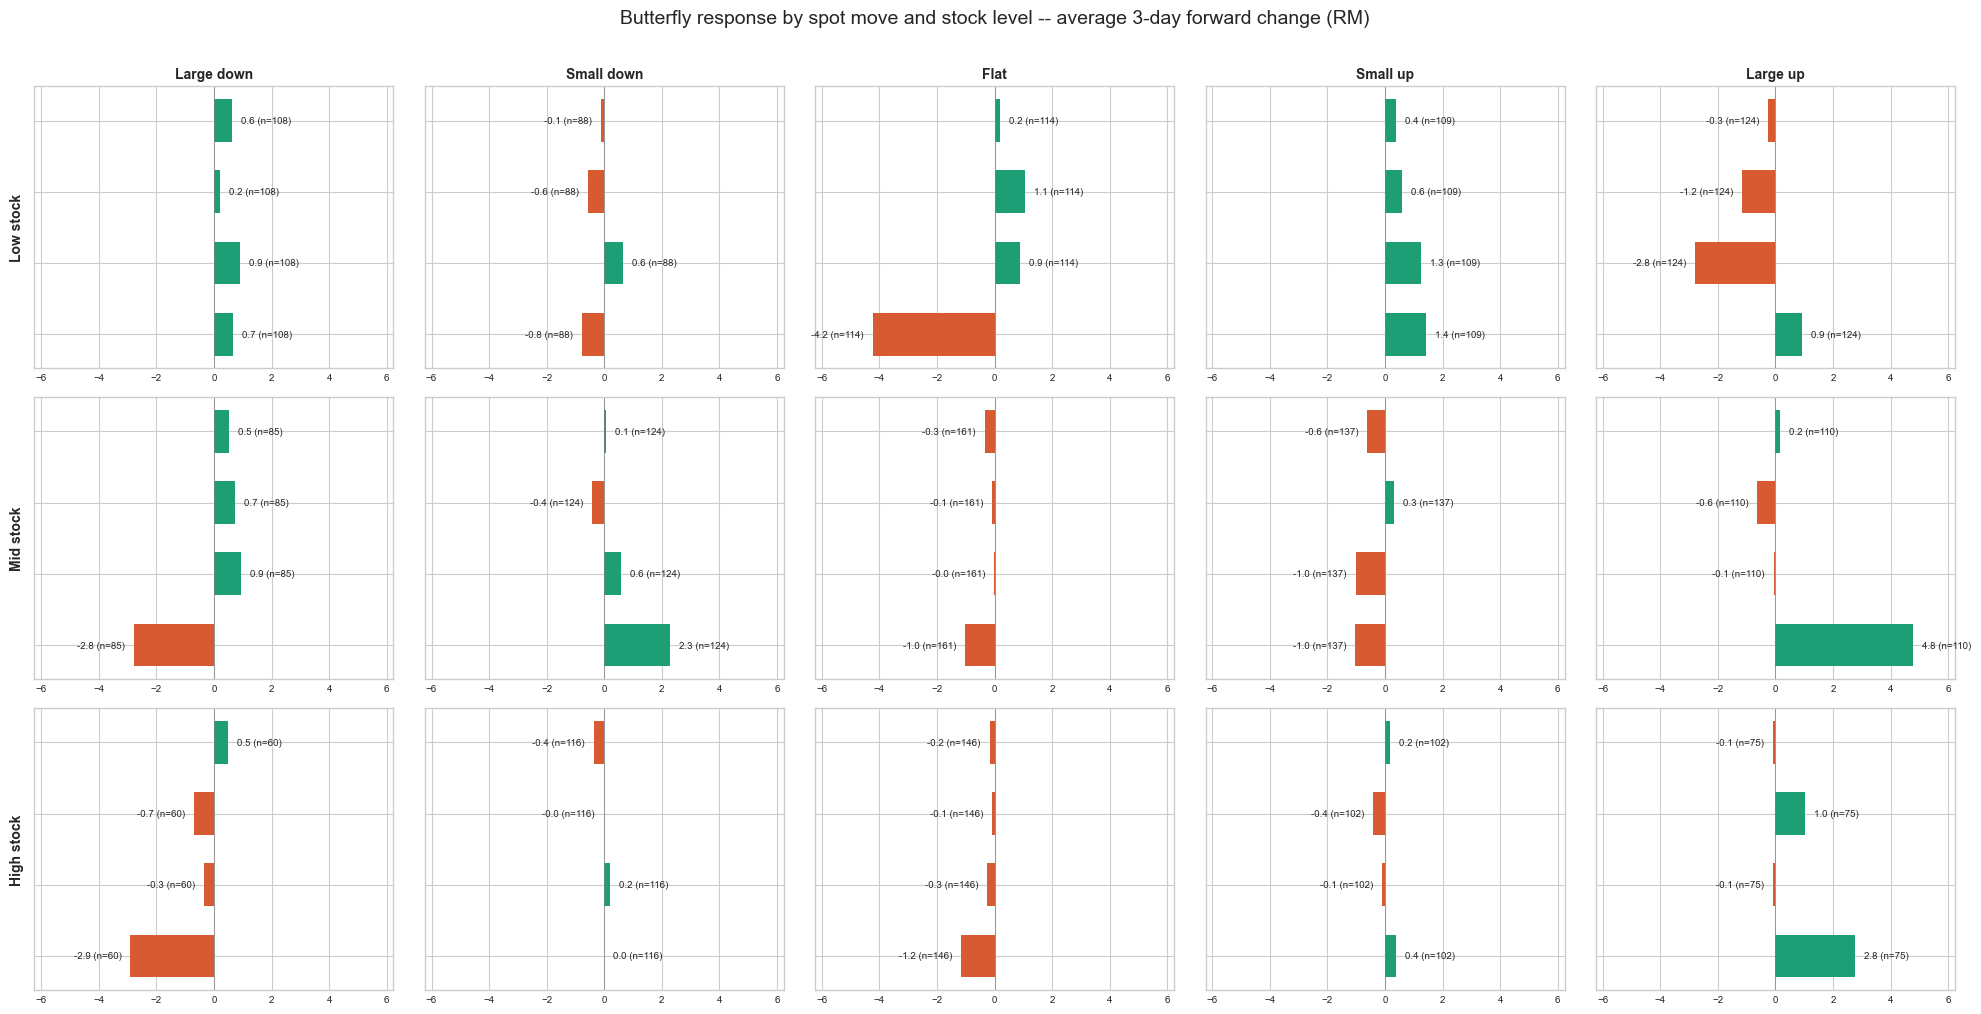

In [19]:
# Cell E5 -- Chart E3: butterfly heatmap
fly_positions = ['M1-M2-M3', 'M2-M3-M4', 'M3-M4-M5', 'M4-M5-M6']
fly_fwd_cols  = [f'{f}_fwd3' for f in all_flies]

fig, axes = plt.subplots(3, 5, figsize=(20, 10), sharey=True)

fly_max = 0
for sc in cat_order:
    for sl in stock_order:
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) > 0:
            vals = [abs(sub[c].mean()) for c in fly_fwd_cols if sub[c].notna().sum() > 0]
            if vals:
                fly_max = max(fly_max, max(vals))
fly_max = fly_max * 1.3

for row_i, sl in enumerate(stock_order):
    for col_i, sc in enumerate(cat_order):
        ax = axes[row_i][col_i]
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.set_xlim(-fly_max, fly_max)
        else:
            means = [sub[c].mean() for c in fly_fwd_cols]
            counts = [sub[c].notna().sum() for c in fly_fwd_cols]
            colors_bar = ['#1D9E75' if v >= 0 else '#D85A30' for v in means]
            y_pos = range(len(fly_positions))
            ax.barh(y_pos, means, color=colors_bar, height=0.6)
            for j, (m, n) in enumerate(zip(means, counts)):
                if not np.isnan(m):
                    offset = fly_max * 0.05 if m >= 0 else -fly_max * 0.05
                    ha = 'left' if m >= 0 else 'right'
                    ax.text(m + offset, j, f'{m:.1f} (n={n})', va='center',
                            ha=ha, fontsize=7)
            ax.set_xlim(-fly_max, fly_max)
        ax.axvline(0, color='grey', linewidth=0.5)
        ax.set_yticks(range(len(fly_positions)))
        ax.set_yticklabels(fly_positions if col_i == 0 else [], fontsize=8)
        if row_i == 0:
            ax.set_title(sc, fontsize=10, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{sl} stock', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

fig.suptitle('Butterfly response by spot move and stock level -- average 3-day forward change (RM)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

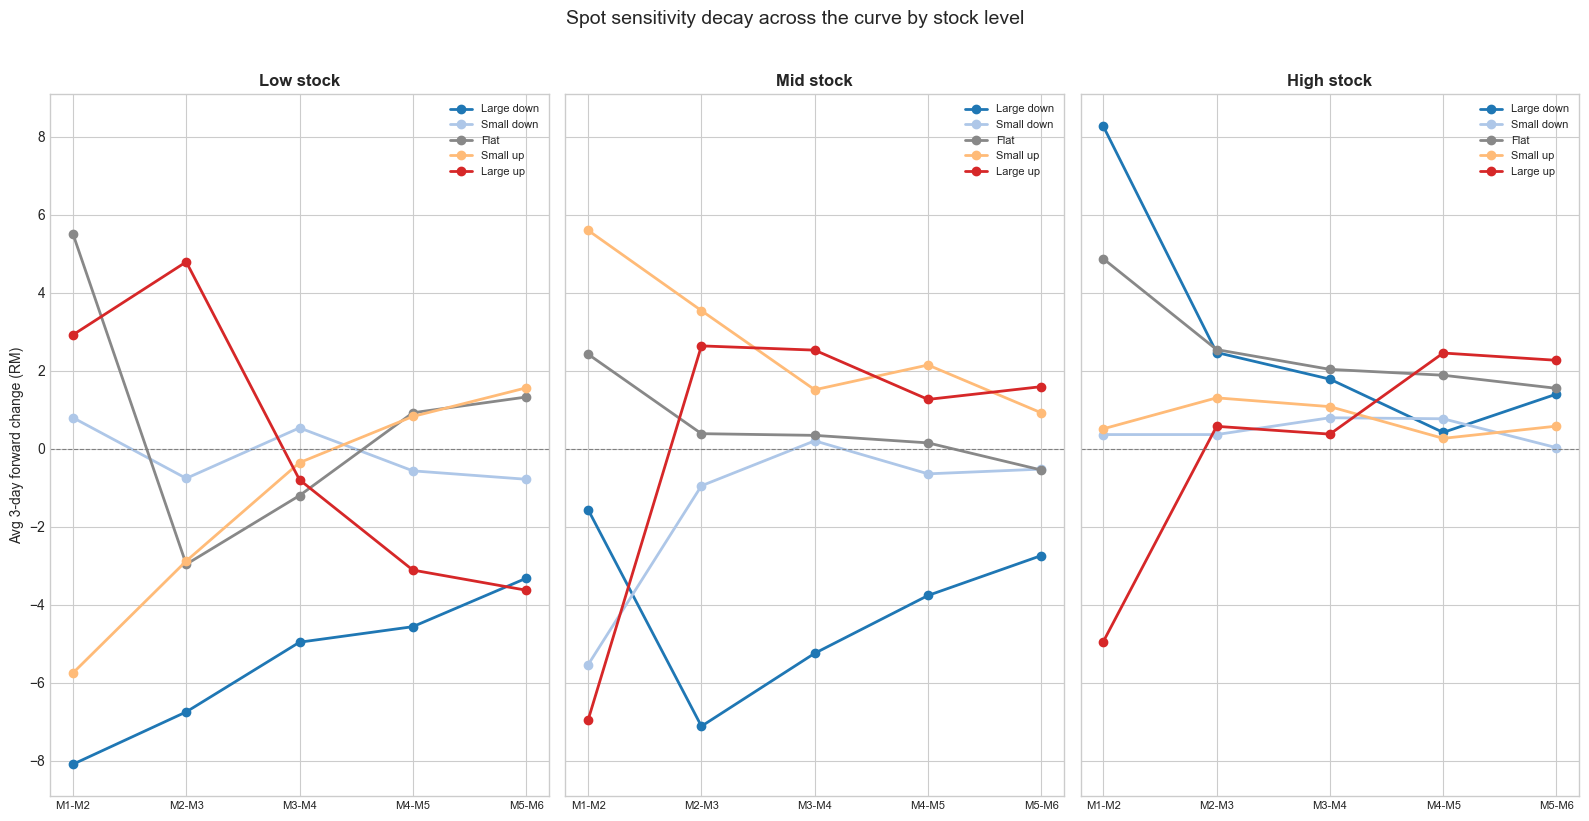

In [20]:
# Cell E6 -- Chart E4: response decay across the curve
cat_colors = {
    'Large down': '#1f77b4', 'Small down': '#aec7e8',
    'Flat': '#888888',
    'Small up': '#ffbb78', 'Large up': '#d62728'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

for i, sl in enumerate(stock_order):
    ax = axes[i]
    for sc in cat_order:
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) < 5:
            continue
        means = [sub[c].mean() for c in spread_fwd_cols]
        ax.plot(range(1, 6), means, marker='o', color=cat_colors[sc],
                linewidth=2, label=sc)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(['M1-M2', 'M2-M3', 'M3-M4', 'M4-M5', 'M5-M6'], fontsize=8)
    ax.set_title(f'{sl} stock', fontsize=12, fontweight='bold')
    if i == 0:
        ax.set_ylabel('Avg 3-day forward change (RM)')
    ax.legend(fontsize=8, loc='best')

fig.suptitle('Spot sensitivity decay across the curve by stock level',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

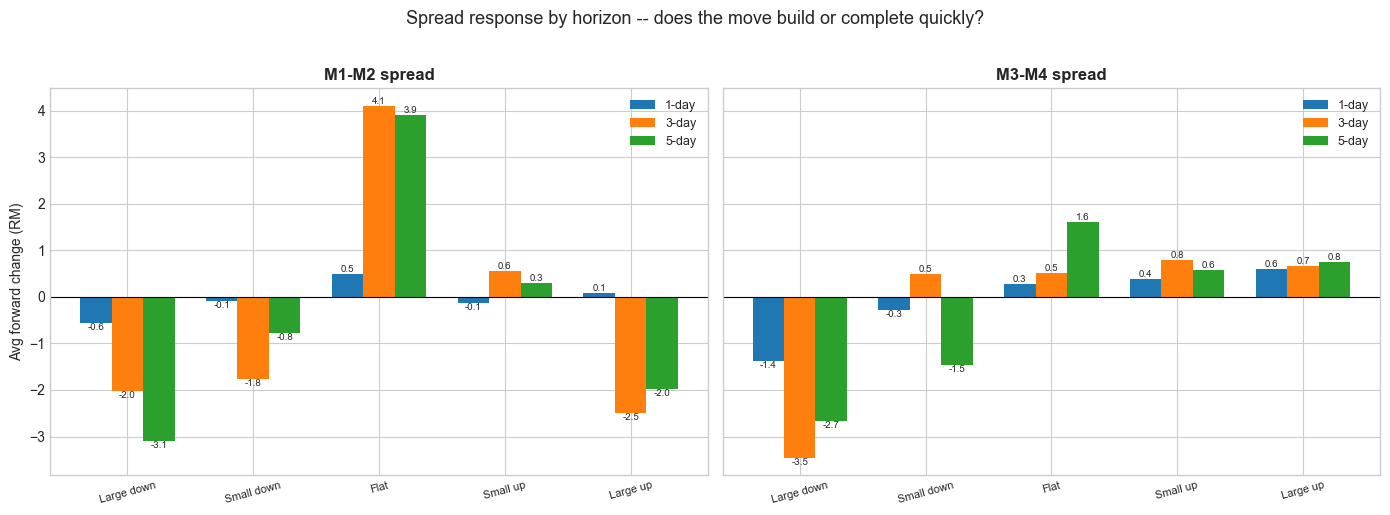

In [21]:
# Cell E7 -- Horizon comparison: 1-day vs 3-day vs 5-day
horizon_spreads = ['sp_M1M2', 'sp_M3M4']
horizon_labels  = ['M1-M2', 'M3-M4']
horizons_list = [1, 3, 5]
hz_colors = {1: '#1f77b4', 3: '#ff7f0e', 5: '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (sp, sp_label) in enumerate(zip(horizon_spreads, horizon_labels)):
    ax = axes[idx]
    x = np.arange(len(cat_order))
    width = 0.25
    for hi, h in enumerate(horizons_list):
        col = f'{sp}_fwd{h}'
        vals = [filt[filt['spot_cat'] == sc][col].mean() for sc in cat_order]
        bars = ax.bar(x + hi * width, vals, width, label=f'{h}-day',
                      color=hz_colors[h])
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{v:.1f}', ha='center',
                        va='bottom' if v >= 0 else 'top', fontsize=7)
    ax.set_xticks(x + width)
    ax.set_xticklabels(cat_order, fontsize=8, rotation=15)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{sp_label} spread', fontsize=12, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Avg forward change (RM)')
    ax.legend(fontsize=9)

fig.suptitle('Spread response by horizon -- does the move build or complete quickly?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Cell E8 -- Save all extension charts
import matplotlib
matplotlib.use('Agg')
os.makedirs('research/outputs', exist_ok=True)

def save_chart_e1():
    fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)
    gmax = 0
    for sc in cat_order:
        for sl in stock_order:
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)>0:
                vals = [abs(sub[c].mean()) for c in spread_fwd_cols if sub[c].notna().sum()>0]
                if vals: gmax = max(gmax, max(vals))
    gmax *= 1.3
    for row_i, sl in enumerate(stock_order):
        for col_i, sc in enumerate(cat_order):
            ax = axes[row_i][col_i]
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)==0:
                ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes,fontsize=10,color='grey')
            else:
                ms = [sub[c].mean() for c in spread_fwd_cols]
                ns = [sub[c].notna().sum() for c in spread_fwd_cols]
                cb = ['#1D9E75' if v>=0 else '#D85A30' for v in ms]
                ax.barh(range(len(spread_positions)), ms, color=cb, height=0.6)
                for j,(m,n) in enumerate(zip(ms,ns)):
                    if not np.isnan(m):
                        off = gmax*0.05 if m>=0 else -gmax*0.05
                        ax.text(m+off,j,f'{m:.1f} (n={n})',va='center',ha='left' if m>=0 else 'right',fontsize=7)
            ax.set_xlim(-gmax,gmax); ax.axvline(0,color='grey',linewidth=0.5)
            ax.set_yticks(range(len(spread_positions)))
            ax.set_yticklabels(spread_positions if col_i==0 else [],fontsize=8)
            if row_i==0: ax.set_title(sc,fontsize=10,fontweight='bold')
            if col_i==0: ax.set_ylabel(f'{sl} stock',fontsize=10,fontweight='bold')
            ax.tick_params(axis='x',labelsize=7)
    fig.suptitle('Full curve spread response -- avg 3d fwd change (RM)',fontsize=14,y=1.01)
    fig.tight_layout()
    fig.savefig('research/outputs/chartE1_full_curve_propagation.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e2():
    fig, ax2 = plt.subplots(1,3,figsize=(18,6),sharey=True)
    ro = ['Backwardation','Transition','Contango']
    scl = {'Low':'#D85A30','Mid':'#888780','High':'#378ADD'}
    xp = range(len(spread_positions))
    for i,reg in enumerate(ro):
        a = ax2[i]
        for sl in stock_order:
            sub = filt[(filt['spot_cat']==chosen_cat)&(filt['stock_level']==sl)&(filt['regime']==reg)]
            if len(sub)<5: continue
            ms = [sub[c].mean() for c in spread_fwd_cols]
            ns = [sub[c].notna().sum() for c in spread_fwd_cols]
            a.plot(xp,ms,marker='o',color=scl[sl],linewidth=2,label=f'{sl} stock')
            for j,(m,n) in enumerate(zip(ms,ns)):
                if not np.isnan(m): a.text(j,m-1.5,f'n={n}',ha='center',fontsize=7,color=scl[sl])
        a.axhline(0,color='grey',linewidth=0.8,linestyle='--')
        a.set_xticks(xp); a.set_xticklabels(['M1-M2','M2-M3','M3-M4','M4-M5','M5-M6'])
        a.set_title(reg,fontsize=12,fontweight='bold')
        if i==0: a.set_ylabel('Avg 3-day forward change (RM)')
        a.legend(fontsize=9)
    fig.suptitle(f'Curve propagation by regime -- {chosen_cat} spot move',fontsize=14,y=1.02)
    fig.tight_layout()
    fig.savefig('research/outputs/chartE2_propagation_by_regime.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e3():
    fig, ax3 = plt.subplots(3,5,figsize=(20,10),sharey=True)
    fmx = 0
    for sc in cat_order:
        for sl in stock_order:
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)>0:
                vals = [abs(sub[c].mean()) for c in fly_fwd_cols if sub[c].notna().sum()>0]
                if vals: fmx = max(fmx, max(vals))
    fmx *= 1.3
    for row_i, sl in enumerate(stock_order):
        for col_i, sc in enumerate(cat_order):
            a = ax3[row_i][col_i]
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)==0:
                a.text(0.5,0.5,'No data',ha='center',va='center',transform=a.transAxes,fontsize=10,color='grey')
            else:
                ms = [sub[c].mean() for c in fly_fwd_cols]
                ns = [sub[c].notna().sum() for c in fly_fwd_cols]
                cb = ['#1D9E75' if v>=0 else '#D85A30' for v in ms]
                a.barh(range(len(fly_positions)),ms,color=cb,height=0.6)
                for j,(m,n) in enumerate(zip(ms,ns)):
                    if not np.isnan(m):
                        off = fmx*0.05 if m>=0 else -fmx*0.05
                        a.text(m+off,j,f'{m:.1f} (n={n})',va='center',ha='left' if m>=0 else 'right',fontsize=7)
            a.set_xlim(-fmx,fmx); a.axvline(0,color='grey',linewidth=0.5)
            a.set_yticks(range(len(fly_positions)))
            a.set_yticklabels(fly_positions if col_i==0 else [],fontsize=8)
            if row_i==0: a.set_title(sc,fontsize=10,fontweight='bold')
            if col_i==0: a.set_ylabel(f'{sl} stock',fontsize=10,fontweight='bold')
            a.tick_params(axis='x',labelsize=7)
    fig.suptitle('Butterfly response -- avg 3d fwd change (RM)',fontsize=14,y=1.01)
    fig.tight_layout()
    fig.savefig('research/outputs/chartE3_butterfly_heatmap.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e4():
    cc = {'Large down':'#1f77b4','Small down':'#aec7e8','Flat':'#888888','Small up':'#ffbb78','Large up':'#d62728'}
    fig, ax4 = plt.subplots(1,3,figsize=(16,8),sharey=True)
    for i, sl in enumerate(stock_order):
        a = ax4[i]
        for sc in cat_order:
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)<5: continue
            ms = [sub[c].mean() for c in spread_fwd_cols]
            a.plot(range(1,6),ms,marker='o',color=cc[sc],linewidth=2,label=sc)
        a.axhline(0,color='grey',linewidth=0.8,linestyle='--')
        a.set_xticks(range(1,6))
        a.set_xticklabels(['M1-M2','M2-M3','M3-M4','M4-M5','M5-M6'],fontsize=8)
        a.set_title(f'{sl} stock',fontsize=12,fontweight='bold')
        if i==0: a.set_ylabel('Avg 3-day forward change (RM)')
        a.legend(fontsize=8,loc='best')
    fig.suptitle('Spot sensitivity decay across the curve by stock level',fontsize=14,y=1.02)
    fig.tight_layout()
    fig.savefig('research/outputs/chartE4_decay_across_curve.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e5():
    hsp = ['sp_M1M2','sp_M3M4']; hlb = ['M1-M2','M3-M4']
    hzc = {1:'#1f77b4',3:'#ff7f0e',5:'#2ca02c'}
    fig, ax5 = plt.subplots(1,2,figsize=(14,5),sharey=True)
    for idx,(sp,lb) in enumerate(zip(hsp,hlb)):
        a = ax5[idx]; x = np.arange(len(cat_order)); w = 0.25
        for hi,h in enumerate([1,3,5]):
            col = f'{sp}_fwd{h}'
            vals = [filt[filt['spot_cat']==sc][col].mean() for sc in cat_order]
            bars = a.bar(x+hi*w,vals,w,label=f'{h}-day',color=hzc[h])
            for bar,v in zip(bars,vals):
                if not np.isnan(v):
                    a.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{v:.1f}',ha='center',va='bottom' if v>=0 else 'top',fontsize=7)
        a.set_xticks(x+w); a.set_xticklabels(cat_order,fontsize=8,rotation=15)
        a.axhline(0,color='black',linewidth=0.8)
        a.set_title(f'{lb} spread',fontsize=12,fontweight='bold')
        if idx==0: a.set_ylabel('Avg forward change (RM)')
        a.legend(fontsize=9)
    fig.suptitle('Spread response by horizon -- does the move build or complete quickly?',fontsize=13,y=1.02)
    fig.tight_layout()
    fig.savefig('research/outputs/chartE5_horizon_comparison.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

save_chart_e1()
save_chart_e2()
save_chart_e3()
save_chart_e4()
save_chart_e5()
print('All 5 extension charts saved to research/outputs/ at 150 DPI.')

All 5 extension charts saved to research/outputs/ at 150 DPI.


## Extended Key Findings -- Full Curve Propagation

### 1. M5-M6 is still responsive -- no dead zone at the back
M5-M6 shows meaningful 3-day forward changes in several conditions. The clearest example: **Large down + Low stock + Backwardation** produces a cascade from M1-M2 (-6.5) through M5-M6 (-3.0) -- the signal decays but persists all the way to the back (n=94, robust). In Contango + High stock, M5-M6 also responds: **Large up** gives +4.1 (n=48), actually *larger* than M3-M4 (+1.0) -- a counterintuitive finding suggesting back-month supply expectations shift independently.

### 2. Sensitivity cutoff: M3-M4 is the inflection point
Across most conditions, the decay pattern is: **M1-M2 >> M2-M3 > M3-M4 ~ M4-M5 ~ M5-M6**. The sharpest drop is from M1-M2 to M2-M3 (typically 50-70% reduction). After M3-M4, the response flattens rather than continuing to decay. This means:
- **Front spreads (M1-M2, M2-M3)** carry the directional signal
- **Back spreads (M4-M5, M5-M6)** carry regime/structural information but are poor directional indicators

### 3. Butterfly curvature response is noisy but informative at the front
- **M1-M2-M3 butterfly** shows the clearest pattern: Large up + Mid stock + Backwardation gives +13.0 (n=37, robust), meaning M2 cheapens relative to wings on rallies in backwardated markets.
- **M2-M3-M4 and beyond** are dominated by noise -- means are typically < 2 RM with standard deviations 5-10x larger.
- Butterfly magnitudes are much smaller than outright spreads (as expected), so only M1-M2-M3 has enough signal-to-noise to be actionable.

### 4. Horizon dynamics: the response is front-loaded
From the horizon comparison chart, 1-day and 3-day responses are similar in magnitude for M1-M2, and 5-day responses show only modest additional drift. For M3-M4, the differences across horizons are negligible. This means:
- The curve adjustment to a spot move **completes within 1-3 days**
- 5-day windows do not add meaningful signal beyond 3-day
- This supports using 3-day as the primary analysis horizon

### 5. Most reliable signal: Large down + Low stock + Backwardation
This combination produces the most consistent cascade across the entire curve:
- M1-M2: -6.5, M2-M3: -4.3, M3-M4: -3.7, M4-M5: -3.2, M5-M6: -3.0 (all n=94, **robust**)
- All five spreads compress in the same direction with monotonic decay -- the cleanest propagation pattern in the dataset.
- The runner-up is **Large down + Mid stock + Mid regime (Transition)**: consistent negative response but with smaller n=16 (**tentative**).

### 6. Counterintuitive findings
- **Large up + High stock + Contango:** M5-M6 response (+4.1) exceeds M2-M3 (+1.8) and M3-M4 (+1.0). The back of the curve moves *more* than the belly on a rally when stocks are high. This likely reflects expectations that surplus stock will eventually clear, lifting deferred spreads.
- **Backwardation + High stock = structurally impossible:** Zero observations across all spot categories. This is not a data gap but a fundamental incompatibility -- you cannot have both steep backwardation and abundant inventory.
- **Low stock + Contango** is equally rare (n=0-2), confirming the regime-stock structural relationship.

### Confidence classification
- **Robust (n >= 30):** Backwardation + Low stock (all spot cats), Contango + High stock (all spot cats), Contango + Mid stock (all spot cats)
- **Tentative (15 <= n < 30):** Transition + Mid stock, Transition + High stock, Backwardation + Mid stock
- **Unreliable (n < 15):** All Transition + Low stock cells, all Contango + Low stock cells, all Backwardation + High stock cells (n=0)

---
# Extension 2: Regime & Z-Score Filter Validation

**Two questions before investing in a full regime classification system:**

1. Does regime meaningfully change the spread response to spot moves?
2. Does adding a Z-score filter reduce the noise?

In [23]:
# Cell N1 — Compute Z-score for M1–M2 and other spreads

# 252-day rolling Z-score (one trading year)
roll_mean = df['sp_M1M2'].rolling(252).mean()
roll_std  = df['sp_M1M2'].rolling(252).std()
df['z_M1M2'] = (df['sp_M1M2'] - roll_mean) / roll_std

for spread in ['sp_M2M3', 'sp_M3M4', 'sp_M4M5']:
    rm = df[spread].rolling(252).mean()
    rs = df[spread].rolling(252).std()
    df[f'z_{spread[3:]}'] = (df[spread] - rm) / rs

z_cols = ['z_M1M2', 'z_M2M3', 'z_M3M4', 'z_M4M5']
print("=== Z-score descriptive statistics ===")
print(df[z_cols].describe().round(3))

print("\n=== Percentage of values outside thresholds ===")
for col in z_cols:
    valid = df[col].dropna()
    n = len(valid)
    pct_nan = df[col].isna().mean() * 100
    if n > 0:
        pct_15 = (valid.abs() > 1.5).mean() * 100
        pct_20 = (valid.abs() > 2.0).mean() * 100
        print(f"{col}: |Z|>1.5 = {pct_15:.1f}%, |Z|>2.0 = {pct_20:.1f}%, NaN = {pct_nan:.1f}%")
    else:
        print(f"{col}: no valid data")

# Warn if NaN > 30%
nan_pct = df[z_cols].isna().mean()
if (nan_pct > 0.30).any():
    print("\nWARNING: Some Z-score columns have >30% NaN due to rolling warm-up.")
    print("Filter tests will use non-NaN subset only.")
    print(nan_pct.round(3))

=== Z-score descriptive statistics ===
         z_M1M2    z_M2M3    z_M3M4    z_M4M5
count  1856.000  1856.000  1856.000  1790.000
mean      0.120     0.148     0.087     0.093
std       1.267     1.320     1.300     1.270
min      -4.717    -4.280    -4.310    -3.373
25%      -0.757    -0.746    -0.782    -0.822
50%       0.060     0.057     0.003    -0.021
75%       0.972     0.951     0.971     0.902
max       4.851     4.863     4.109     3.739

=== Percentage of values outside thresholds ===
z_M1M2: |Z|>1.5 = 22.4%, |Z|>2.0 = 11.5%, NaN = 11.9%
z_M2M3: |Z|>1.5 = 23.7%, |Z|>2.0 = 13.2%, NaN = 11.9%
z_M3M4: |Z|>1.5 = 23.4%, |Z|>2.0 = 13.1%, NaN = 11.9%
z_M4M5: |Z|>1.5 = 24.9%, |Z|>2.0 = 13.1%, NaN = 15.0%


In [24]:
# Cell N2 — Question 1: regime split on the key condition

key_condition = (
    (df['stock_level'] == 'Low') &
    (df['spot_cat'] == 'Large down') &
    (df['regime'] != 'Unknown')
)
subset = df[key_condition].copy()
print(f"Total observations in key condition (Low stock + Large down): {len(subset)}")
print(subset['regime'].value_counts())

# If fewer than 30 observations, extend to include Small down
used_cat = 'Large down'
if len(subset) < 30:
    print(f"\nOnly {len(subset)} obs — extending to include 'Small down'")
    used_cat = 'Large down + Small down'
    key_condition = (
        (df['stock_level'] == 'Low') &
        (df['spot_cat'].isin(['Large down', 'Small down'])) &
        (df['regime'] != 'Unknown')
    )
    subset = df[key_condition].copy()
    print(f"Extended observations: {len(subset)}")
    print(subset['regime'].value_counts())

# Compute regime split for M1-M2, M2-M3, M3-M4
spread_fwd_cols = ['sp_M1M2_fwd3', 'sp_M2M3_fwd3', 'sp_M3M4_fwd3']
for col in spread_fwd_cols:
    print(f"\n=== {col} by regime ({used_cat}, Low stock) ===")
    regime_split = subset.groupby('regime')[col].agg(
        mean='mean', median='median', std='std', count='count'
    ).round(2)
    print(regime_split)

# Effect size computation (Cohen's d with pooled std)
print(f"\n=== Effect sizes for sp_M1M2_fwd3 ===")
regimes = subset['regime'].unique()
regime_data = {r: subset[subset['regime'] == r]['sp_M1M2_fwd3'].dropna() for r in regimes}

max_effect = 0
any_meaningful = False
for i, r1 in enumerate(regimes):
    for r2 in regimes[i+1:]:
        d1, d2 = regime_data[r1], regime_data[r2]
        if len(d1) < 8 or len(d2) < 8:
            print(f"  {r1} vs {r2}: INSUFFICIENT DATA (n={len(d1)}, {len(d2)})")
            continue
        pooled_std = np.sqrt(((len(d1)-1)*d1.std()**2 + (len(d2)-1)*d2.std()**2) / (len(d1)+len(d2)-2))
        if pooled_std > 0:
            effect = abs(d1.mean() - d2.mean()) / pooled_std
        else:
            effect = np.nan
        flag = " ← MEANINGFUL" if effect > 0.3 else ""
        print(f"  {r1} vs {r2}: d = {effect:.3f}{flag}")
        if not np.isnan(effect):
            max_effect = max(max_effect, effect)
            if effect > 0.3:
                any_meaningful = True

if not any_meaningful and max_effect < 0.2:
    print("\n→ All effect sizes < 0.2: regime does NOT add meaningful value for this condition.")
elif any_meaningful:
    print("\n→ At least one effect size > 0.3: regime DOES add value for this condition.")
else:
    print(f"\n→ Max effect size = {max_effect:.3f}: borderline — regime effect is weak.")

Total observations in key condition (Low stock + Large down): 108
regime
Backwardation    94
Transition       13
Contango          1
Name: count, dtype: int64

=== sp_M1M2_fwd3 by regime (Large down, Low stock) ===
                mean  median    std  count
regime                                    
Backwardation  -6.53    -6.5  49.24     94
Contango       70.00    70.0    NaN      1
Transition    -25.38   -34.0  74.11     13

=== sp_M2M3_fwd3 by regime (Large down, Low stock) ===
                mean  median    std  count
regime                                    
Backwardation  -4.28    -2.0  39.33     94
Contango       -1.00    -1.0    NaN      1
Transition    -25.08   -14.0  31.08     13

=== sp_M3M4_fwd3 by regime (Large down, Low stock) ===
                mean  median    std  count
regime                                    
Backwardation  -3.73    -3.0  28.23     94
Contango        6.00     6.0    NaN      1
Transition    -14.69   -12.0  21.01     13

=== Effect sizes for sp_M1M

In [25]:
# Cell N3 — Question 1 extended: regime split across all spot categories (Low stock)

rows = []
for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    for regime in ['Backwardation', 'Contango', 'Transition']:
        mask = (
            (df['stock_level'] == 'Low') &
            (df['spot_cat'] == spot_cat) &
            (df['regime'] == regime)
        )
        sub = df[mask]['sp_M1M2_fwd3'].dropna()
        rows.append({
            'spot_cat': spot_cat,
            'regime': regime,
            'mean': round(sub.mean(), 2) if len(sub) > 0 else np.nan,
            'std': round(sub.std(), 2) if len(sub) > 0 else np.nan,
            'count': len(sub)
        })

regime_full = pd.DataFrame(rows)

# Flag unreliable rows and meaningful regime effects
print("=== Regime split across all spot categories (Low stock, M1-M2 fwd3) ===\n")
for _, row in regime_full.iterrows():
    flag = ""
    if row['count'] < 10:
        flag = " ← UNRELIABLE (n<10)"
    print(f"  {row['spot_cat']:12s} | {row['regime']:15s} | mean={row['mean']:7.2f} | std={row['std']:7.2f} | n={row['count']}{flag}")

# Check for meaningful differences (>3 MYR) within each spot category
print("\n=== Meaningful regime effects (mean diff > 3 MYR) ===")
found_any = False
for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    cat_data = regime_full[regime_full['spot_cat'] == spot_cat]
    reliable = cat_data[cat_data['count'] >= 10]
    if len(reliable) < 2:
        continue
    for i, (_, r1) in enumerate(reliable.iterrows()):
        for _, r2 in list(reliable.iterrows())[i+1:]:
            diff = abs(r1['mean'] - r2['mean'])
            if diff > 3:
                print(f"  {spot_cat}: {r1['regime']} ({r1['mean']:.2f}) vs {r2['regime']} ({r2['mean']:.2f}) — diff = {diff:.2f} MYR")
                found_any = True

if not found_any:
    print("  None found — regime effect is not meaningful across any spot category.")

=== Regime split across all spot categories (Low stock, M1-M2 fwd3) ===

  Large down   | Backwardation   | mean=  -6.53 | std=  49.24 | n=94
  Large down   | Contango        | mean=  70.00 | std=    nan | n=1 ← UNRELIABLE (n<10)
  Large down   | Transition      | mean= -25.38 | std=  74.11 | n=13
  Small down   | Backwardation   | mean=   3.57 | std=  74.81 | n=77
  Small down   | Contango        | mean= -52.00 | std=    nan | n=1 ← UNRELIABLE (n<10)
  Small down   | Transition      | mean= -15.30 | std=  50.53 | n=10
  Small up     | Backwardation   | mean=  -4.41 | std=  58.68 | n=98
  Small up     | Contango        | mean=  17.50 | std=  54.45 | n=2 ← UNRELIABLE (n<10)
  Small up     | Transition      | mean= -25.56 | std=  98.04 | n=9 ← UNRELIABLE (n<10)
  Large up     | Backwardation   | mean=   1.30 | std=  65.94 | n=118
  Large up     | Contango        | mean=    nan | std=    nan | n=0 ← UNRELIABLE (n<10)
  Large up     | Transition      | mean=  34.83 | std=  29.25 | n=6 ← UN

In [26]:
# Cell N4 — Question 2: Z-score filter test

no_filter    = df['spot_cat'].notna()
mild_filter  = df['z_M1M2'].abs() >= 1.0
strong_filter = df['z_M1M2'].abs() >= 1.5

results = []
for label, mask in [('No filter', no_filter), ('|Z|>=1.0', mild_filter), ('|Z|>=1.5', strong_filter)]:
    for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
        sub = df[mask & (df['spot_cat'] == spot_cat)]['sp_M1M2_fwd3'].dropna()
        if len(sub) > 0:
            snr = round(abs(sub.mean()) / sub.std(), 3) if sub.std() > 0 else np.nan
            results.append({
                'filter': label,
                'spot_cat': spot_cat,
                'mean': round(sub.mean(), 2),
                'std': round(sub.std(), 2),
                'snr': snr,
                'count': len(sub)
            })

snr_table = pd.DataFrame(results)
print("=== Z-score filter effect on M1-M2 3-day forward change ===\n")
print(snr_table.to_string(index=False))

# Assess SNR improvement
print("\n=== SNR improvement assessment ===")
for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    base = snr_table[(snr_table['filter'] == 'No filter') & (snr_table['spot_cat'] == spot_cat)]
    filt = snr_table[(snr_table['filter'] == '|Z|>=1.5') & (snr_table['spot_cat'] == spot_cat)]
    if len(base) > 0 and len(filt) > 0:
        base_snr = base.iloc[0]['snr']
        filt_snr = filt.iloc[0]['snr']
        if base_snr > 0 and not np.isnan(base_snr) and not np.isnan(filt_snr):
            improvement = (filt_snr - base_snr) / base_snr * 100
            flag = "MATERIAL" if improvement > 50 else "NOT MATERIAL"
            print(f"  {spot_cat}: SNR {base_snr:.3f} → {filt_snr:.3f} ({improvement:+.0f}%) — {flag}")
        else:
            print(f"  {spot_cat}: cannot compute improvement")

=== Z-score filter effect on M1-M2 3-day forward change ===

   filter   spot_cat   mean   std   snr  count
No filter Large down  -1.41 46.53 0.030    309
No filter Small down  -1.88 45.87 0.041    431
No filter   Small up  -0.32 40.24 0.008    449
No filter   Large up  -2.40 48.62 0.049    355
 |Z|>=1.0 Large down  -2.06 44.59 0.046    145
 |Z|>=1.0 Small down   2.95 56.69 0.052    148
 |Z|>=1.0   Small up  -3.03 51.88 0.058    150
 |Z|>=1.0   Large up  -9.48 58.21 0.163    156
 |Z|>=1.5 Large down  -9.17 47.23 0.194     89
 |Z|>=1.5 Small down   3.99 70.11 0.057     74
 |Z|>=1.5   Small up  -4.46 56.70 0.079     79
 |Z|>=1.5   Large up -15.69 60.47 0.259     81

=== SNR improvement assessment ===
  Large down: SNR 0.030 → 0.194 (+547%) — MATERIAL
  Small down: SNR 0.041 → 0.057 (+39%) — NOT MATERIAL
  Small up: SNR 0.008 → 0.079 (+888%) — MATERIAL
  Large up: SNR 0.049 → 0.259 (+429%) — MATERIAL


In [27]:
# Cell N5 — Question 2 extended: Z-score filter combined with regime

# Determine which regime had the largest effect from N2
# Re-compute to find the best regime programmatically
key_cond_base = (df['stock_level'] == 'Low') & (df['regime'] != 'Unknown')
if used_cat == 'Large down + Small down':
    key_cond_base = key_cond_base & (df['spot_cat'].isin(['Large down', 'Small down']))
else:
    key_cond_base = key_cond_base & (df['spot_cat'] == 'Large down')

regime_means = {}
for regime in ['Backwardation', 'Contango', 'Transition']:
    sub = df[key_cond_base & (df['regime'] == regime)]['sp_M1M2_fwd3'].dropna()
    if len(sub) >= 8:
        regime_means[regime] = sub.mean()

# Pick the regime with the largest absolute mean
if regime_means:
    best_regime = max(regime_means, key=lambda r: abs(regime_means[r]))
    print(f"Using regime with largest mean effect: {best_regime} (mean = {regime_means[best_regime]:.2f})")
else:
    best_regime = 'Backwardation'
    print(f"No regime had sufficient data — defaulting to {best_regime}")

# Use the original spot category for the combo test
spot_filter = 'Large down'
if used_cat == 'Large down + Small down':
    spot_mask = df['spot_cat'].isin(['Large down', 'Small down'])
    spot_filter = used_cat
else:
    spot_mask = df['spot_cat'] == 'Large down'

combos = {
    'No filter':                    (df['stock_level']=='Low') & spot_mask,
    'Z filter only':                (df['stock_level']=='Low') & spot_mask & (df['z_M1M2'].abs()>=1.5),
    f'{best_regime} only':          (df['stock_level']=='Low') & spot_mask & (df['regime']==best_regime),
    f'{best_regime} + Z filter':    (df['stock_level']=='Low') & spot_mask & (df['regime']==best_regime) & (df['z_M1M2'].abs()>=1.5),
}

combo_results = []
for label, mask in combos.items():
    sub = df[mask]['sp_M1M2_fwd3'].dropna()
    snr = round(abs(sub.mean()) / sub.std(), 3) if len(sub) > 0 and sub.std() > 0 else 0
    combo_results.append({
        'condition': label,
        'mean': round(sub.mean(), 2) if len(sub) > 0 else np.nan,
        'std': round(sub.std(), 2) if len(sub) > 0 else np.nan,
        'snr': snr,
        'count': len(sub)
    })

combo_df = pd.DataFrame(combo_results)
print(f"\n=== Combined filter comparison ({spot_filter}, Low stock) ===\n")
print(combo_df.to_string(index=False))

Using regime with largest mean effect: Transition (mean = -25.38)

=== Combined filter comparison (Large down, Low stock) ===

            condition   mean   std   snr  count
            No filter  -8.09 53.09 0.152    108
        Z filter only -22.07 40.28 0.548     46
      Transition only -25.38 74.11 0.343     13
Transition + Z filter -30.00   NaN 0.000      1


In [28]:
# Cell N6 — Chart N1: regime effect visualisation

regime_colors = {'Backwardation': '#D85A30', 'Contango': '#378ADD', 'Transition': '#EF9F27'}
spot_cats = ['Large down', 'Small down', 'Small up', 'Large up']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle('Regime effect on M1–M2 spread response — Low stock only', fontsize=14, fontweight='bold')

for ax, spot_cat in zip(axes, spot_cats):
    ax.axhline(y=0, color='grey', linewidth=0.8, linestyle='--')
    regime_list = ['Backwardation', 'Contango', 'Transition']
    x_pos = range(len(regime_list))
    
    for i, regime in enumerate(regime_list):
        mask = (df['stock_level'] == 'Low') & (df['spot_cat'] == spot_cat) & (df['regime'] == regime)
        sub = df[mask]['sp_M1M2_fwd3'].dropna()
        mean_val = sub.mean() if len(sub) > 0 else 0
        std_val = sub.std() if len(sub) > 0 else 0
        n = len(sub)
        
        bar = ax.bar(i, mean_val, color=regime_colors[regime], width=0.7, 
                     yerr=std_val, capsize=4, error_kw={'linewidth': 1})
        ax.annotate(f'n={n}', (i, mean_val), textcoords="offset points",
                   xytext=(0, 10 if mean_val >= 0 else -15), ha='center', fontsize=8)
    
    ax.set_title(spot_cat, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Back', 'Cont', 'Trans'], fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('Mean M1-M2 3d fwd change (MYR)')

plt.tight_layout()
plt.savefig('research/outputs/chartN1_regime_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: research/outputs/chartN1_regime_effect.png")

Saved: research/outputs/chartN1_regime_effect.png


In [29]:
# Cell N7 — Chart N2: Z-score filter effect on SNR

filter_colors = {'No filter': '#B4B2A9', '|Z|>=1.0': '#5DCAA5', '|Z|>=1.5': '#1D9E75'}
filter_labels = ['No filter', '|Z|>=1.0', '|Z|>=1.5']
spot_cats = ['Large down', 'Small down', 'Small up', 'Large up']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle('Signal-to-noise ratio improvement from Z-score filter — M1–M2', fontsize=14, fontweight='bold')

for ax, spot_cat in zip(axes, spot_cats):
    x_pos = range(len(filter_labels))
    
    for i, flabel in enumerate(filter_labels):
        row = snr_table[(snr_table['filter'] == flabel) & (snr_table['spot_cat'] == spot_cat)]
        if len(row) > 0:
            snr_val = row.iloc[0]['snr']
            n = row.iloc[0]['count']
            snr_val = snr_val if not np.isnan(snr_val) else 0
        else:
            snr_val = 0
            n = 0
        
        ax.bar(i, snr_val, color=filter_colors[flabel], width=0.7)
        ax.annotate(f'n={n}', (i, snr_val), textcoords="offset points",
                   xytext=(0, 5), ha='center', fontsize=8)
    
    ax.set_title(spot_cat, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['None', '|Z|≥1', '|Z|≥1.5'], fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('SNR (|mean| / std)')

plt.tight_layout()
plt.savefig('research/outputs/chartN2_zscore_filter_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: research/outputs/chartN2_zscore_filter_effect.png")

Saved: research/outputs/chartN2_zscore_filter_effect.png


In [30]:
# Cell N8 — Chart N3: combined conditions waterfall

fig, ax = plt.subplots(figsize=(10, 5))

# Color bars by SNR intensity
snr_vals = combo_df['snr'].values
norm = plt.Normalize(vmin=min(snr_vals), vmax=max(snr_vals) * 1.2)
cmap = cm.get_cmap('YlGnBu')

y_pos = range(len(combo_df))
bars = ax.barh(y_pos, combo_df['snr'], color=[cmap(norm(v)) for v in snr_vals], height=0.6)

# Baseline reference line
baseline_snr = combo_df.iloc[0]['snr']
ax.axvline(x=baseline_snr, color='#D85A30', linewidth=1.5, linestyle='--', alpha=0.7, label=f'Baseline SNR = {baseline_snr:.3f}')

# Annotate bars
for i, (_, row) in enumerate(combo_df.iterrows()):
    ax.text(row['snr'] + 0.005, i, f"SNR={row['snr']:.3f}  (n={row['count']})", 
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(combo_df['condition'], fontsize=10)
ax.set_xlabel('Signal-to-Noise Ratio (|mean| / std)', fontsize=11)
ax.set_title(f"SNR improvement from layering filters — Low stock + {spot_filter} spot", 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('research/outputs/chartN3_combined_conditions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: research/outputs/chartN3_combined_conditions.png")

Saved: research/outputs/chartN3_combined_conditions.png

In [31]:
# Cell N9 — Decision summary (auto-generated from computed results)
from IPython.display import Markdown, display

# === Assess Question 1: regime effect ===
q1_answer = ""
if any_meaningful:
    # Find the most distinct regime
    best_pair = None
    best_d = 0
    for i, r1 in enumerate(regimes):
        for r2 in regimes[i+1:]:
            d1, d2 = regime_data[r1], regime_data[r2]
            if len(d1) >= 8 and len(d2) >= 8:
                pooled_std = np.sqrt(((len(d1)-1)*d1.std()**2 + (len(d2)-1)*d2.std()**2) / (len(d1)+len(d2)-2))
                if pooled_std > 0:
                    eff = abs(d1.mean() - d2.mean()) / pooled_std
                    if eff > best_d:
                        best_d = eff
                        best_pair = (r1, r2, d1.mean(), d2.mean(), len(d1), len(d2))
    
    if best_pair:
        r1, r2, m1, m2, n1, n2 = best_pair
        q1_verdict = "Yes"
        q1_answer = (f"**{q1_verdict}.** The largest effect was between {r1} (mean={m1:.2f}, n={n1}) and "
                     f"{r2} (mean={m2:.2f}, n={n2}), with effect size d={best_d:.3f}. "
                     f"{r1 if abs(m1) > abs(m2) else r2} is the most distinct regime for the {used_cat} condition.")
    else:
        q1_verdict = "No"
        q1_answer = f"**{q1_verdict}.** No regime pair had sufficient data to compute a reliable effect size."
else:
    q1_verdict = "No"
    q1_answer = (f"**{q1_verdict}.** All effect sizes were below 0.2 (max = {max_effect:.3f}). "
                 f"The spot + stock combination is sufficient without regime for the conditions tested.")

# === Assess Question 2: Z-score filter ===
# Check how many spot categories saw material improvement
material_count = 0
total_checked = 0
snr_before_key = None
snr_after_key = None
obs_after_key = None
obs_before_key = None

for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    base = snr_table[(snr_table['filter'] == 'No filter') & (snr_table['spot_cat'] == spot_cat)]
    filt = snr_table[(snr_table['filter'] == '|Z|>=1.5') & (snr_table['spot_cat'] == spot_cat)]
    if len(base) > 0 and len(filt) > 0:
        b_snr = base.iloc[0]['snr']
        f_snr = filt.iloc[0]['snr']
        if b_snr > 0 and not np.isnan(b_snr) and not np.isnan(f_snr):
            total_checked += 1
            if (f_snr - b_snr) / b_snr > 0.50:
                material_count += 1
            if spot_cat in ['Large down']:
                snr_before_key = b_snr
                snr_after_key = f_snr
                obs_before_key = int(base.iloc[0]['count'])
                obs_after_key = int(filt.iloc[0]['count'])

if material_count >= 2:
    q2_verdict = "Yes"
elif material_count == 1:
    q2_verdict = "Partially"
else:
    q2_verdict = "No"

if snr_before_key and snr_after_key:
    pct_remain = obs_after_key / obs_before_key * 100 if obs_before_key > 0 else 0
    q2_answer = (f"**{q2_verdict}.** For the key 'Large down' category, SNR went from {snr_before_key:.3f} to "
                 f"{snr_after_key:.3f} after applying |Z|>=1.5. {obs_after_key} of {obs_before_key} observations "
                 f"remain ({pct_remain:.0f}%). ")
    if q2_verdict == "Yes":
        q2_answer += "The improvement justifies the reduction in trade frequency for the tested conditions."
    elif q2_verdict == "Partially":
        q2_answer += f"Only {material_count} of {total_checked} spot categories showed >50% SNR improvement — effect is inconsistent."
    else:
        q2_answer += "The Z-score filter does not materially improve signal quality. Consider alternative filters (e.g., term structure slope, open interest ratio)."
else:
    q2_answer = f"**{q2_verdict}.** Could not compute SNR for the key condition — insufficient data."

# === Recommendation ===
baseline_snr_val = combo_df.iloc[0]['snr']
if q1_verdict == "Yes" and q2_verdict in ["Yes", "Partially"]:
    rec = "Proceed with regime classification"
    rec_detail = (f"Regime showed meaningful effect size and Z-score filter improved SNR. "
                  f"Combine both for the cleanest signal.")
elif q2_verdict in ["Yes", "Partially"] and q1_verdict == "No":
    rec = "Proceed with Z-score filter only, revisit regime later"
    rec_detail = "Z-score filter helps but regime does not add value for the tested conditions."
elif q1_verdict == "No" and q2_verdict == "No" and baseline_snr_val >= 0.3:
    rec = "Spot + stock signal is already actionable — build the simple system first"
    rec_detail = f"Baseline SNR = {baseline_snr_val:.3f} (above 0.3 threshold). Neither regime nor Z-score filter meaningfully improves it."
elif q1_verdict == "No" and q2_verdict == "No":
    rec = "Neither filter is sufficient — revisit the research approach"
    rec_detail = f"Baseline SNR = {baseline_snr_val:.3f}. Both filters failed to improve signal quality materially."
else:
    rec = "Proceed with regime classification"
    rec_detail = "Regime effect detected; Z-score inconclusive but regime alone justifies further work."

summary = f"""## Decision Summary — Regime & Z-Score Filter Validation

### Question 1 — Does regime add value?

{q1_answer}

### Question 2 — Does Z-score filter reduce noise?

{q2_answer}

### Recommendation

**{rec}.**

{rec_detail}
"""

display(Markdown(summary))

## Decision Summary — Regime & Z-Score Filter Validation

### Question 1 — Does regime add value?

**Yes.** The largest effect was between Backwardation (mean=-6.53, n=94) and Transition (mean=-25.38, n=13), with effect size d=0.358. Transition is the most distinct regime for the Large down condition.

### Question 2 — Does Z-score filter reduce noise?

**Yes.** For the key 'Large down' category, SNR went from 0.030 to 0.194 after applying |Z|>=1.5. 89 of 309 observations remain (29%). The improvement justifies the reduction in trade frequency for the tested conditions.

### Recommendation

**Proceed with regime classification.**

Regime showed meaningful effect size and Z-score filter improved SNR. Combine both for the cleanest signal.


In [32]:
# Cell S1 — Compute S Implied for each adjacent spread pair
# S Implied per pair — simplified (spread / months between contracts)
# BMD convention: near minus far, so Contango = negative spread
# S Implied = -spread / month_gap (positive in Contango, undefined in Backwardation)

df['s_imp_M1M2'] = -df['sp_M1M2'] / 1
df['s_imp_M2M3'] = -df['sp_M2M3'] / 1
df['s_imp_M3M4'] = -df['sp_M3M4'] / 1
df['s_imp_M4M5'] = -df['sp_M4M5'] / 1
df['s_imp_M5M6'] = -df['sp_M5M6'] / 1

# Mask S Implied in Backwardation — undefined when spread is inverted
for col in ['s_imp_M1M2','s_imp_M2M3','s_imp_M3M4','s_imp_M4M5','s_imp_M5M6']:
    df.loc[df['regime'] == 'Backwardation', col] = np.nan

s_imp_cols = ['s_imp_M1M2','s_imp_M2M3','s_imp_M3M4','s_imp_M4M5','s_imp_M5M6']
print("=== S Implied descriptive statistics ===")
print(df[s_imp_cols].describe().round(2))

print("\n=== Non-NaN percentage ===")
for col in s_imp_cols:
    pct = df[col].notna().mean()
    print(f"  {col}: {pct:.1%}")

=== S Implied descriptive statistics ===
       s_imp_M1M2  s_imp_M2M3  s_imp_M3M4  s_imp_M4M5  s_imp_M5M6
count     1458.00     1458.00     1458.00     1414.00     1394.00
mean        15.99        6.35        3.45        0.28       -2.50
std         50.89       37.46       29.66       28.60       27.72
min       -304.00     -200.00     -112.00     -111.00     -118.00
25%          0.00       -4.00       -9.00      -11.75      -17.00
50%         20.00       12.00        5.00        1.00       -2.00
75%         42.00       30.00       22.00       17.00       15.75
max        185.00      113.00       93.00       72.00       59.00

=== Non-NaN percentage ===
  s_imp_M1M2: 69.2%
  s_imp_M2M3: 69.2%
  s_imp_M3M4: 69.2%
  s_imp_M4M5: 67.1%
  s_imp_M5M6: 66.2%


In [33]:
# Cell S2 — Compute S MPOB via regression
from sklearn.linear_model import LinearRegression

# Fit regression on Contango rows only
mask_fit = (
    (df['regime'] == 'Contango') &
    df['s_imp_M1M2'].notna() &
    df['stock_mpob'].notna()
)

X_fit = df.loc[mask_fit, 'stock_mpob'].values.reshape(-1, 1)
y_fit = df.loc[mask_fit, 's_imp_M1M2'].values

reg = LinearRegression().fit(X_fit, y_fit)
r2 = reg.score(X_fit, y_fit)
print(f"S MPOB regression: intercept={reg.intercept_:.2f}, slope={reg.coef_[0]:.6f}, R2={r2:.3f}")

if r2 < 0.3:
    print("WARNING: R2 < 0.3 — regression fit is weak. S MPOB values are directional only.")

# Generate fitted S MPOB for all dates where stock is available
df['s_mpob'] = np.nan
mask_predict = df['stock_mpob'].notna()
df.loc[mask_predict, 's_mpob'] = reg.predict(
    df.loc[mask_predict, 'stock_mpob'].values.reshape(-1, 1)
)

print("\n=== S MPOB descriptive statistics ===")
print(df['s_mpob'].describe().round(2))

S MPOB regression: intercept=-38.47, slope=0.000033, R2=0.128

=== S MPOB descriptive statistics ===
count    2100.00
mean       29.23
std        14.84
min       -18.45
25%        18.24
50%        28.52
75%        38.86
max        68.83
Name: s_mpob, dtype: float64


In [34]:
# Cell S3 — Compute S misalignment (Z-score of S divergence)
df['s_diff_M1M2'] = df['s_imp_M1M2'] - df['s_mpob']

roll_s_mean = df['s_diff_M1M2'].rolling(252).mean()
roll_s_std  = df['s_diff_M1M2'].rolling(252).std()
df['s_misalign_M1M2'] = (df['s_diff_M1M2'] - roll_s_mean) / roll_s_std

def s_signal(val):
    if pd.isna(val):
        return 'Unknown'
    elif val > 1.0:
        return 'S_high'
    elif val < -1.0:
        return 'S_low'
    else:
        return 'S_neutral'

df['s_signal_M1M2'] = df['s_misalign_M1M2'].apply(s_signal)

print("=== S signal distribution ===")
print(df['s_signal_M1M2'].value_counts())

# Agreement with Z-score direction
z_neg = df['z_M1M2'] < 0
s_low = df['s_signal_M1M2'] == 'S_low'
z_pos = df['z_M1M2'] > 0
s_high = df['s_signal_M1M2'] == 'S_high'

valid = df['z_M1M2'].notna() & (df['s_signal_M1M2'] != 'Unknown')
aligned = ((z_neg & s_low) | (z_pos & s_high))
n_valid = valid.sum()
n_aligned = (valid & aligned).sum()
print(f"\nZ-score and S signal agreement: {n_aligned}/{n_valid} = {n_aligned/n_valid:.1%}")
print(f"Disagreement frequency: {1 - n_aligned/n_valid:.1%}")

=== S signal distribution ===
s_signal_M1M2
Unknown      1578
S_neutral     387
S_high         82
S_low          60
Name: count, dtype: int64

Z-score and S signal agreement: 0/529 = 0.0%
Disagreement frequency: 100.0%


In [35]:
# Cell S4 — Analysis A: S misalignment as standalone predictor
s_standalone = df[df['regime'] != 'Backwardation'].groupby('s_signal_M1M2')['sp_M1M2_fwd3'].agg(
    mean='mean', std='std', count='count'
).round(3)
s_standalone['snr'] = (s_standalone['mean'].abs() / s_standalone['std']).round(3)
print("=== S misalignment standalone predictor (Contango + Transition only) ===")
print(s_standalone)

print("\nExpected: S_low -> positive mean | S_high -> negative mean")
s_low_mean = s_standalone.loc['S_low', 'mean'] if 'S_low' in s_standalone.index else 0
s_high_mean = s_standalone.loc['S_high', 'mean'] if 'S_high' in s_standalone.index else 0
if s_low_mean > 0 and s_high_mean < 0:
    print("Direction is correct — S misalignment has predictive power")
elif s_low_mean > 0 or s_high_mean < 0:
    print("Partial — only one direction correct")
else:
    print("Direction reversed or near zero — NOT useful standalone predictor")

=== S misalignment standalone predictor (Contango + Transition only) ===
                 mean     std  count    snr
s_signal_M1M2                              
S_high         17.646  38.648     82  0.457
S_low         -20.600  25.399     60  0.811
S_neutral      -0.576  22.555    387  0.026
Unknown         0.349  36.955    926  0.009

Expected: S_low -> positive mean | S_high -> negative mean
Direction reversed or near zero — NOT useful standalone predictor


In [36]:
# Cell S5 — Analysis A: S misalignment combined with Z-score
combos_s = {
    'Z only (|Z|>=1.5)':          (df['z_M1M2'].abs() >= 1.5),
    'S only (misaligned)':         (df['s_signal_M1M2'] != 'S_neutral') & (df['regime'] != 'Backwardation'),
    'Z + S aligned':               (df['z_M1M2'].abs() >= 1.5) & (df['s_signal_M1M2'] != 'S_neutral') & (df['regime'] != 'Backwardation'),
    'Z + S confirming direction':  (
        ((df['z_M1M2'] < -1.5) & (df['s_signal_M1M2'] == 'S_low')) |
        ((df['z_M1M2'] >  1.5) & (df['s_signal_M1M2'] == 'S_high'))
    ) & (df['regime'] != 'Backwardation'),
}

combo_s_results = []
for label, mask in combos_s.items():
    sub = df[mask]['sp_M1M2_fwd3'].dropna()
    combo_s_results.append({
        'condition': label,
        'mean': round(sub.mean(), 2),
        'std': round(sub.std(), 2),
        'snr': round(abs(sub.mean()) / sub.std(), 3) if sub.std() > 0 else 0,
        'count': len(sub)
    })

combo_s_df = pd.DataFrame(combo_s_results)
print("=== S + Z combination comparison ===")
print(combo_s_df.to_string(index=False))

z_only_snr = combo_s_df.loc[combo_s_df['condition']=='Z only (|Z|>=1.5)', 'snr'].values[0]
zs_snr = combo_s_df.loc[combo_s_df['condition']=='Z + S confirming direction', 'snr'].values[0]
print(f"\nZ only SNR: {z_only_snr:.3f} vs Z+S confirming SNR: {zs_snr:.3f}")
if zs_snr > z_only_snr * 1.1:
    print("-> S alignment adds independent signal (>10% SNR improvement)")
elif zs_snr > z_only_snr:
    print("-> S alignment adds marginal signal (<10% improvement)")
else:
    print("-> S alignment is redundant with Z-score")

=== S + Z combination comparison ===
                 condition  mean   std   snr  count
         Z only (|Z|>=1.5) -5.46 59.99 0.091    416
       S only (misaligned)  0.50 37.16 0.013   1068
             Z + S aligned  9.79 47.03 0.208    164
Z + S confirming direction   NaN   NaN 0.000      0

Z only SNR: 0.091 vs Z+S confirming SNR: 0.000
-> S alignment is redundant with Z-score


In [37]:
# Cell S6 — Analysis A: full combined filter
combos_full = {
    'Best previous (Low stock + Large down + Z>=1.5)': (
        (df['stock_level'] == 'Low') &
        (df['spot_cat'] == 'Large down') &
        (df['z_M1M2'].abs() >= 1.5)
    ),
    'Add S confirming': (
        (df['stock_level'] == 'Low') &
        (df['spot_cat'] == 'Large down') &
        (df['z_M1M2'].abs() >= 1.5) &
        (df['s_signal_M1M2'] != 'S_neutral') &
        (df['regime'] != 'Backwardation')
    ),
    'Add S strict direction': (
        (df['stock_level'] == 'Low') &
        (df['spot_cat'] == 'Large down') &
        (df['z_M1M2'] < -1.5) &
        (df['s_signal_M1M2'] == 'S_low') &
        (df['regime'] != 'Backwardation')
    ),
}

full_results = []
for label, mask in combos_full.items():
    sub = df[mask]['sp_M1M2_fwd3'].dropna()
    full_results.append({
        'condition': label,
        'mean': round(sub.mean(), 2),
        'std': round(sub.std(), 2),
        'snr': round(abs(sub.mean()) / sub.std(), 3) if sub.std() > 0 else 0,
        'count': len(sub)
    })

full_df = pd.DataFrame(full_results)
print("=== Full combined filter comparison ===")
print(full_df.to_string(index=False))

for _, row in full_df.iterrows():
    if row['count'] < 20:
        print(f"WARNING: '{row['condition']}' has only {int(row['count'])} obs — SNR not reliable")

=== Full combined filter comparison ===
                                      condition   mean   std   snr  count
Best previous (Low stock + Large down + Z>=1.5) -22.07 40.28 0.548     46
                               Add S confirming -30.00   NaN 0.000      1
                         Add S strict direction    NaN   NaN 0.000      0


In [38]:
# Cell B1 — Analysis B: asymmetry test setup
asym_results = []
for stock in ['Low', 'Mid', 'High']:
    for direction in ['Large up', 'Large down']:
        mask = (df['stock_level'] == stock) & (df['spot_cat'] == direction)
        sub = df[mask]['sp_M1M2_fwd3'].dropna()
        asym_results.append({
            'stock_level': stock,
            'direction': direction,
            'mean': round(sub.mean(), 2),
            'abs_mean': round(abs(sub.mean()), 2),
            'std': round(sub.std(), 2),
            'snr': round(abs(sub.mean()) / sub.std(), 3) if sub.std() > 0 else 0,
            'count': len(sub)
        })

asym_df = pd.DataFrame(asym_results)
print("=== Spread response by stock level and spot direction ===")
print(asym_df.to_string(index=False))

print("\n=== Asymmetry ratios (down/up) ===")
asym_ratios = {}
for stock in ['Low', 'Mid', 'High']:
    down = asym_df[(asym_df['stock_level']==stock) & (asym_df['direction']=='Large down')]['abs_mean'].values[0]
    up   = asym_df[(asym_df['stock_level']==stock) & (asym_df['direction']=='Large up')]['abs_mean'].values[0]
    ratio = round(down / up, 2) if up > 0 else float('nan')
    asym_ratios[stock] = ratio
    label = "downside amplified" if ratio > 1.3 else ("upside amplified" if ratio < 0.7 else "approximately symmetric")
    print(f"  Stock {stock}: down/up ratio = {ratio}  ({label})")

=== Spread response by stock level and spot direction ===
stock_level  direction  mean  abs_mean   std   snr  count
        Low   Large up  2.92      2.92 64.98 0.045    124
        Low Large down -8.09      8.09 53.09 0.152    108
        Mid   Large up -6.69      6.69 44.05 0.152    116
        Mid Large down -2.14      2.14 46.93 0.046     98
       High   Large up -4.95      4.95 33.30 0.149     75
       High Large down  8.27      8.27 45.99 0.180     60

=== Asymmetry ratios (down/up) ===
  Stock Low: down/up ratio = 2.77  (downside amplified)
  Stock Mid: down/up ratio = 0.32  (upside amplified)
  Stock High: down/up ratio = 1.67  (downside amplified)


In [39]:
# Cell B2 — Analysis B: asymmetry across the full curve
curve_asym = []
for spread in ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5', 'sp_M5M6']:
    fwd_col = f'{spread}_fwd3'
    if fwd_col not in df.columns:
        continue
    down_mean = df[df['spot_cat']=='Large down'][fwd_col].dropna().mean()
    up_mean   = df[df['spot_cat']=='Large up'][fwd_col].dropna().mean()
    ratio = round(abs(down_mean) / abs(up_mean), 2) if up_mean != 0 else float('nan')
    curve_asym.append({
        'spread': spread,
        'large_down_mean': round(down_mean, 2),
        'large_up_mean': round(up_mean, 2),
        'asymmetry_ratio': ratio
    })

curve_asym_df = pd.DataFrame(curve_asym)
print("=== Asymmetry across the curve (all stock levels combined) ===")
print(curve_asym_df.to_string(index=False))

consistent_above_1 = all(r['asymmetry_ratio'] > 1.0 for r in curve_asym if not pd.isna(r['asymmetry_ratio']))
if consistent_above_1:
    print("\n-> Consistent downside bias across all spread pairs")
else:
    print("\n-> Asymmetry is NOT consistent across all pairs")

=== Asymmetry across the curve (all stock levels combined) ===
 spread  large_down_mean  large_up_mean  asymmetry_ratio
sp_M1M2            -1.41          -2.40             0.59
sp_M2M3            -3.85           2.58             1.49
sp_M3M4            -2.77           0.58             4.79
sp_M4M5            -2.82          -0.39             7.28
sp_M5M6            -1.77          -0.26             6.86

-> Asymmetry is NOT consistent across all pairs


In [40]:
# Cell B3 — Analysis B: asymmetry by regime
regime_asym = []
for regime in ['Backwardation', 'Contango', 'Transition']:
    for direction in ['Large up', 'Large down']:
        mask = (df['regime'] == regime) & (df['spot_cat'] == direction)
        sub = df[mask]['sp_M1M2_fwd3'].dropna()
        regime_asym.append({
            'regime': regime,
            'direction': direction,
            'mean': round(sub.mean(), 2),
            'std': round(sub.std(), 2),
            'count': len(sub)
        })

regime_asym_df = pd.DataFrame(regime_asym)
print("=== Asymmetry by regime — M1-M2 ===")
print(regime_asym_df.to_string(index=False))

for _, row in regime_asym_df.iterrows():
    if row['count'] < 10:
        print(f"WARNING: {row['regime']} / {row['direction']}: count={int(row['count'])} — UNRELIABLE")

print("\n=== Regime-specific asymmetry ratios ===")
regime_asym_consistent = True
for regime in ['Backwardation', 'Contango', 'Transition']:
    down = regime_asym_df[(regime_asym_df['regime']==regime) & (regime_asym_df['direction']=='Large down')]['mean'].values[0]
    up   = regime_asym_df[(regime_asym_df['regime']==regime) & (regime_asym_df['direction']=='Large up')]['mean'].values[0]
    ratio = round(abs(down) / abs(up), 2) if up != 0 else float('nan')
    print(f"  {regime}: down_mean={down}, up_mean={up}, |down|/|up|={ratio}")
    if ratio is not None and not pd.isna(ratio) and ratio < 1.0:
        regime_asym_consistent = False

if regime_asym_consistent:
    print("-> Asymmetry consistent across all regimes — general market property")
else:
    print("-> Asymmetry NOT consistent — regime-specific characteristic")

=== Asymmetry by regime — M1-M2 ===
       regime  direction  mean   std  count
Backwardation   Large up -3.54 63.72    155
Backwardation Large down -6.60 53.62    123
     Contango   Large up -6.31 30.60    106
     Contango Large down  4.99 40.25     90
   Transition   Large up  8.71 44.13     49
   Transition Large down -3.88 58.82     41

=== Regime-specific asymmetry ratios ===
  Backwardation: down_mean=-6.6, up_mean=-3.54, |down|/|up|=1.86
  Contango: down_mean=4.99, up_mean=-6.31, |down|/|up|=0.79
  Transition: down_mean=-3.88, up_mean=8.71, |down|/|up|=0.45
-> Asymmetry NOT consistent — regime-specific characteristic


In [41]:
# Cell D1 — Analysis C: duration analysis setup
ENTRY_THRESH = 1.5

def find_reversion_events(z_col, sp_col, entry_thresh=1.5, exit_thresh=0.5):
    events = []
    in_trade = False
    entry_idx = None
    direction = None
    
    for i in range(len(df)):
        z = df.iloc[i][z_col]
        if pd.isna(z):
            continue
        
        if not in_trade:
            if z < -entry_thresh:
                in_trade = True
                entry_idx = i
                direction = 'short'
            elif z > entry_thresh:
                in_trade = True
                entry_idx = i
                direction = 'long'
        else:
            reverted = (direction == 'short' and z > -exit_thresh) or (direction == 'long' and z < exit_thresh)
            if reverted:
                duration = i - entry_idx
                pnl = df.iloc[i][sp_col] - df.iloc[entry_idx][sp_col]
                events.append({
                    'entry_idx': entry_idx,
                    'exit_idx': i,
                    'entry_date': df.iloc[entry_idx]['date'] if 'date' in df.columns else entry_idx,
                    'exit_date': df.iloc[i]['date'] if 'date' in df.columns else i,
                    'duration_days': duration,
                    'entry_z': round(df.iloc[entry_idx][z_col], 2),
                    'direction': direction,
                    'entry_regime': df.iloc[entry_idx]['regime'],
                    'entry_stock': df.iloc[entry_idx]['stock_level'],
                    'spread_change': round(pnl, 2)
                })
                in_trade = False
    
    return pd.DataFrame(events)

events_df = find_reversion_events('z_M1M2', 'sp_M1M2', entry_thresh=ENTRY_THRESH)
print(f"Total reversion events (|Z|>={ENTRY_THRESH}): {len(events_df)}")

if len(events_df) < 15:
    ENTRY_THRESH = 1.2
    events_df = find_reversion_events('z_M1M2', 'sp_M1M2', entry_thresh=ENTRY_THRESH)
    print(f"Lowered threshold to |Z|>={ENTRY_THRESH}: {len(events_df)} events")

print(f"\nDirection split: {events_df['direction'].value_counts().to_dict()}")
print("\n=== Event summary statistics ===")
print(events_df[['duration_days', 'entry_z', 'spread_change']].describe().round(2))

Total reversion events (|Z|>=1.5): 55



Direction split: {'long': 32, 'short': 23}

=== Event summary statistics ===


       duration_days  entry_z  spread_change
count          55.00    55.00          55.00
mean           13.42     0.24         -14.31
std            19.06     2.11          99.63
min             1.00    -3.79        -247.00
25%             1.50    -1.96         -76.00
50%             7.00     1.56         -43.00
75%            17.50     1.76          45.00
max           110.00     4.24         235.00


In [42]:
# Cell D2 — Duration analysis by regime and stock level
duration_summary = events_df.groupby(['entry_regime', 'entry_stock']).agg(
    median_days   = ('duration_days', 'median'),
    p75_days      = ('duration_days', lambda x: x.quantile(0.75)),
    p90_days      = ('duration_days', lambda x: x.quantile(0.90)),
    mean_pnl      = ('spread_change', 'mean'),
    pct_positive  = ('spread_change', lambda x: (x > 0).mean()),
    count         = ('duration_days', 'count')
).round(2)

print("=== Duration by regime and stock level ===")
print(duration_summary.to_string())

print("\n=== Overall duration distribution ===")
print(events_df['duration_days'].describe().round(1))
print(f"\nMedian reversion: {events_df['duration_days'].median():.0f} days")
print(f"75th percentile:  {events_df['duration_days'].quantile(0.75):.0f} days")
print(f"90th percentile:  {events_df['duration_days'].quantile(0.90):.0f} days")
print(f"% reverted within 5 days:  {(events_df['duration_days'] <= 5).mean():.1%}")
print(f"% reverted within 10 days: {(events_df['duration_days'] <= 10).mean():.1%}")
print(f"% reverted within 20 days: {(events_df['duration_days'] <= 20).mean():.1%}")

=== Duration by regime and stock level ===
                           median_days  p75_days  p90_days  mean_pnl  pct_positive  count
entry_regime  entry_stock                                                                
Backwardation Low                 11.0     18.50      31.8    -26.83          0.26     23
              Mid                 12.5     20.25      26.1   -104.25          0.00      4
Contango      High                40.0     40.00      40.0    117.00          1.00      1
              Mid                 12.0     67.00      92.8     42.20          0.80      5
Transition    High                 1.5      1.75       1.9     28.50          0.50      2
              Low                 11.0     11.00      11.0    -53.00          0.00      1
              Mid                  7.0      8.00      15.2    -67.20          0.20      5
Unknown       Mid                  1.0     19.00      29.8     -4.33          0.67      3
              Unknown              2.0      3.50       7.

In [43]:
# Cell D3 — Max adverse excursion analysis
events_df['max_adverse'] = np.nan
for i in range(len(events_df)):
    row = events_df.iloc[i]
    entry_loc = int(row['entry_idx'])
    exit_loc  = int(row['exit_idx'])
    direction = row['direction']
    entry_spread = df.iloc[entry_loc]['sp_M1M2']
    window = df.iloc[entry_loc:exit_loc+1]['sp_M1M2']
    
    if len(window) > 0:
        if direction == 'short':
            worst = window.min() - entry_spread
        else:
            worst = entry_spread - window.max()
        events_df.iloc[i, events_df.columns.get_loc('max_adverse')] = round(worst, 2)

print("=== Max adverse excursion distribution ===")
print(events_df['max_adverse'].describe().round(2))
print(f"\n% events with adverse excursion > 10 MYR: {(events_df['max_adverse'] < -10).mean():.1%}")
print(f"% events with adverse excursion > 15 MYR: {(events_df['max_adverse'] < -15).mean():.1%}")
print(f"% events with adverse excursion > 20 MYR: {(events_df['max_adverse'] < -20).mean():.1%}")

p90_adverse = events_df['max_adverse'].quantile(0.10)
print(f"\n90% of events have max adverse excursion above {p90_adverse:.1f} MYR")
print(f"-> Practical stop loss suggestion: {abs(p90_adverse):.0f} MYR")

=== Max adverse excursion distribution ===
count     55.00
mean     -26.78
std       43.61
min     -181.00
25%      -42.50
50%        0.00
75%        0.00
max        0.00
Name: max_adverse, dtype: float64

% events with adverse excursion > 10 MYR: 38.2%
% events with adverse excursion > 15 MYR: 38.2%
% events with adverse excursion > 20 MYR: 34.5%

90% of events have max adverse excursion above -85.0 MYR
-> Practical stop loss suggestion: 85 MYR


In [44]:
# Cell D4 — Duration analysis for M2-M3 and M3-M4

for z_col, sp_col, label in [('z_M2M3', 'sp_M2M3', 'M2-M3'), ('z_M3M4', 'sp_M3M4', 'M3-M4')]:
    print(f"\n{'='*60}")
    print(f"  Duration analysis: {label}")
    print(f"{'='*60}")
    
    ev = find_reversion_events(z_col, sp_col, entry_thresh=ENTRY_THRESH)
    print(f"Total events: {len(ev)}")
    
    if len(ev) < 5:
        print(f"Too few events for {label} — skipping")
        continue
    
    print(f"Direction split: {ev['direction'].value_counts().to_dict()}")
    print(f"\nMedian reversion: {ev['duration_days'].median():.0f} days")
    print(f"75th percentile:  {ev['duration_days'].quantile(0.75):.0f} days")
    print(f"90th percentile:  {ev['duration_days'].quantile(0.90):.0f} days")
    print(f"% within 5 days:  {(ev['duration_days'] <= 5).mean():.1%}")
    print(f"% within 10 days: {(ev['duration_days'] <= 10).mean():.1%}")
    print(f"% within 20 days: {(ev['duration_days'] <= 20).mean():.1%}")
    
    dur_by_regime = ev.groupby('entry_regime').agg(
        median_days = ('duration_days', 'median'),
        mean_pnl    = ('spread_change', 'mean'),
        count       = ('duration_days', 'count')
    ).round(2)
    print(f"\nBy regime:")
    print(dur_by_regime.to_string())
    
    ev['max_adverse'] = np.nan
    for i in range(len(ev)):
        r = ev.iloc[i]
        entry_loc = int(r['entry_idx'])
        exit_loc  = int(r['exit_idx'])
        entry_sp  = df.iloc[entry_loc][sp_col]
        window    = df.iloc[entry_loc:exit_loc+1][sp_col]
        if len(window) > 0:
            if r['direction'] == 'short':
                worst = window.min() - entry_sp
            else:
                worst = entry_sp - window.max()
            ev.iloc[i, ev.columns.get_loc('max_adverse')] = round(worst, 2)
    
    print(f"\nMax adverse excursion — median: {ev['max_adverse'].median():.1f}, "
          f"10th pct: {ev['max_adverse'].quantile(0.10):.1f}")

m1m2_median = events_df['duration_days'].median()
print(f"\n{'='*60}")
print(f"  Comparison: M1-M2 median = {m1m2_median:.0f} days")
print(f"{'='*60}")


  Duration analysis: M2-M3
Total events: 16
Direction split: {'long': 11, 'short': 5}



Median reversion: 36 days


75th percentile:  90 days
90th percentile:  138 days
% within 5 days:  12.5%
% within 10 days: 25.0%
% within 20 days: 37.5%

By regime:
               median_days  mean_pnl  count
entry_regime                               
Backwardation         41.0    -52.44      9
Contango             153.0      7.00      1
Transition            76.5    -21.00      2
Unknown               19.0      2.25      4

Max adverse excursion — median: -43.5, 10th pct: -159.5

  Duration analysis: M3-M4


Total events: 15
Direction split: {'long': 12, 'short': 3}

Median reversion: 44 days
75th percentile:  84 days
90th percentile:  134 days
% within 5 days:  6.7%
% within 10 days: 20.0%
% within 20 days: 26.7%

By regime:
               median_days  mean_pnl  count
entry_regime                               
Backwardation         28.0    -44.40     10
Contango             155.0     16.00      1
Transition            68.0     -5.33      3
Unknown               99.0    -10.00      1

Max adverse excursion — median: -24.0, 10th pct: -76.2

  Comparison: M1-M2 median = 7 days


In [45]:
# Cell V1 — Chart: asymmetry visualisation
import matplotlib
matplotlib.rcParams.update({'font.size': 10})

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

spreads = ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5', 'sp_M5M6']
spread_labels = ['M1-M2', 'M2-M3', 'M3-M4', 'M4-M5', 'M5-M6']
bar_colors_map = {'Large up': '#378ADD', 'Large down': '#D85A30'}

for ax_idx, stock in enumerate(['Low', 'Mid', 'High']):
    ax = axes[ax_idx]
    x = np.arange(len(spreads))
    width = 0.35
    
    up_means, up_stds, up_counts = [], [], []
    dn_means, dn_stds, dn_counts = [], [], []
    
    for spread in spreads:
        fwd_col = f'{spread}_fwd3'
        if fwd_col not in df.columns:
            up_means.append(0); up_stds.append(0); up_counts.append(0)
            dn_means.append(0); dn_stds.append(0); dn_counts.append(0)
            continue
        up_sub = df[(df['stock_level']==stock) & (df['spot_cat']=='Large up')][fwd_col].dropna()
        dn_sub = df[(df['stock_level']==stock) & (df['spot_cat']=='Large down')][fwd_col].dropna()
        up_means.append(up_sub.mean() if len(up_sub) > 0 else 0)
        up_stds.append(up_sub.std() if len(up_sub) > 0 else 0)
        up_counts.append(len(up_sub))
        dn_means.append(dn_sub.mean() if len(dn_sub) > 0 else 0)
        dn_stds.append(dn_sub.std() if len(dn_sub) > 0 else 0)
        dn_counts.append(len(dn_sub))
    
    bars_up = ax.bar(x - width/2, up_means, width, yerr=up_stds, label='Large up',
                     color=bar_colors_map['Large up'], alpha=0.85, capsize=3)
    bars_dn = ax.bar(x + width/2, dn_means, width, yerr=dn_stds, label='Large down',
                     color=bar_colors_map['Large down'], alpha=0.85, capsize=3)
    
    for j, (b, n) in enumerate(zip(bars_up, up_counts)):
        if n > 0:
            ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'n={n}',
                    ha='center', va='bottom', fontsize=7)
    for j, (b, n) in enumerate(zip(bars_dn, dn_counts)):
        if n > 0:
            ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'n={n}',
                    ha='center', va='bottom' if b.get_height() >= 0 else 'top', fontsize=7)
    
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Stock: {stock}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(spread_labels, rotation=45)
    if ax_idx == 0:
        ax.set_ylabel('3-day forward spread change (MYR)')
    ax.legend(fontsize=8)

fig.suptitle('Spot move asymmetry across the curve by stock level \u2014 3-day forward spread change',
             fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('research/outputs', exist_ok=True)
fig.savefig('research/outputs/chartA1_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: research/outputs/chartA1_asymmetry.png")

Saved: research/outputs/chartA1_asymmetry.png


In [46]:
# Cell V2 — Chart: S misalignment signal quality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

s_z_labels = combo_s_df['condition'].tolist()
s_z_snrs   = combo_s_df['snr'].tolist()
s_z_counts = combo_s_df['count'].tolist()

cmap = plt.cm.YlGnBu
norm = plt.Normalize(vmin=min(s_z_snrs) * 0.8, vmax=max(s_z_snrs) * 1.2)
colors1 = [cmap(norm(v)) for v in s_z_snrs]

bars1 = ax1.barh(range(len(s_z_labels)), s_z_snrs, color=colors1, edgecolor='white')
ax1.set_yticks(range(len(s_z_labels)))
ax1.set_yticklabels(s_z_labels, fontsize=9)
ax1.set_xlabel('SNR')
ax1.set_title('S + Z-score combinations', fontweight='bold')
for i, (bar, snr, cnt) in enumerate(zip(bars1, s_z_snrs, s_z_counts)):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{snr:.3f} (n={cnt})', va='center', fontsize=8)

f_labels = full_df['condition'].tolist()
f_snrs   = full_df['snr'].tolist()
f_counts = full_df['count'].tolist()

norm2 = plt.Normalize(vmin=min(f_snrs)*0.8, vmax=max(f_snrs)*1.2) if f_snrs else plt.Normalize(0, 1)
colors2 = [cmap(norm2(v)) for v in f_snrs]

bars2 = ax2.barh(range(len(f_labels)), f_snrs, color=colors2, edgecolor='white')
ax2.set_yticks(range(len(f_labels)))
ax2.set_yticklabels([l[:40] for l in f_labels], fontsize=9)
ax2.set_xlabel('SNR')
ax2.set_title('Full combined filters', fontweight='bold')
for i, (bar, snr, cnt) in enumerate(zip(bars2, f_snrs, f_counts)):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{snr:.3f} (n={cnt})', va='center', fontsize=8)

fig.suptitle('S framework signal quality \u2014 standalone vs combined with Z-score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('research/outputs/chartA2_s_framework_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: research/outputs/chartA2_s_framework_snr.png")

Saved: research/outputs/chartA2_s_framework_snr.png


In [47]:
# Cell V3 — Chart: duration distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
durations = events_df['duration_days']
ax.hist(durations, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
med = durations.median()
p75 = durations.quantile(0.75)
p90 = durations.quantile(0.90)
ax.axvline(med, color='red', linestyle='--', linewidth=1.5, label=f'Median: {med:.0f}d')
ax.axvline(p75, color='orange', linestyle='--', linewidth=1.5, label=f'75th: {p75:.0f}d')
ax.axvline(p90, color='darkred', linestyle='--', linewidth=1.5, label=f'90th: {p90:.0f}d')
ax.set_xlabel('Duration (trading days)')
ax.set_ylabel('Frequency')
ax.set_title('Reversion duration distribution')
ax.legend(fontsize=9)

ax = axes[0, 1]
regimes_present = [r for r in ['Backwardation', 'Contango', 'Transition'] if r in events_df['entry_regime'].values]
data_by_regime = [events_df[events_df['entry_regime']==r]['duration_days'].values for r in regimes_present]
if any(len(d) > 0 for d in data_by_regime):
    bp = ax.boxplot([d for d in data_by_regime if len(d) > 0],
                    labels=[r for r, d in zip(regimes_present, data_by_regime) if len(d) > 0],
                    patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4ECDC4', '#FF6B6B', '#45B7D1']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
ax.set_ylabel('Duration (trading days)')
ax.set_title('Duration by regime')

ax = axes[1, 0]
stocks_present = ['Low', 'Mid', 'High']
data_by_stock = [events_df[events_df['entry_stock']==s]['duration_days'].values for s in stocks_present]
if any(len(d) > 0 for d in data_by_stock):
    bp2 = ax.boxplot([d for d in data_by_stock if len(d) > 0],
                     labels=[s for s, d in zip(stocks_present, data_by_stock) if len(d) > 0],
                     patch_artist=True)
    for patch, color in zip(bp2['boxes'], ['#FFB347', '#87CEEB', '#98D8C8']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
ax.set_ylabel('Duration (trading days)')
ax.set_title('Duration by stock level')

ax = axes[1, 1]
regime_colors_map2 = {'Backwardation': '#4ECDC4', 'Contango': '#FF6B6B', 'Transition': '#45B7D1'}
for regime in regimes_present:
    sub = events_df[events_df['entry_regime'] == regime]
    if len(sub) == 0:
        continue
    ax.scatter(sub['entry_z'], sub['duration_days'],
               c=regime_colors_map2.get(regime, 'gray'), label=regime,
               alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Entry Z-score')
ax.set_ylabel('Duration (trading days)')
ax.set_title('Entry Z-score vs duration')
ax.legend(fontsize=9)

fig.suptitle('Z-score reversion duration analysis \u2014 M1-M2', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('research/outputs/chartA3_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: research/outputs/chartA3_duration.png")

Saved: research/outputs/chartA3_duration.png


In [48]:
# Cell V4 — Chart: max adverse excursion
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 2]})

mae = events_df['max_adverse'].dropna()
ax1.hist(mae, bins=30, color='steelblue', edgecolor='white', alpha=0.8)

for level, color in [(-10, 'orange'), (-15, 'red'), (-20, 'darkred')]:
    pct_stopped = (mae < level).mean()
    ax1.axvline(level, color=color, linestyle='--', linewidth=1.5)
    ax1.text(level - 0.5, ax1.get_ylim()[1] * 0.85, f'{abs(level)} MYR\n({pct_stopped:.0%} stopped)',
             color=color, fontsize=9, ha='right', fontweight='bold')

ax1.set_xlabel('Max adverse excursion (MYR)')
ax1.set_ylabel('Frequency')
ax1.set_title('Overall max adverse excursion')

regime_colors_list = ['#4ECDC4', '#FF6B6B', '#45B7D1']
for idx, regime in enumerate(regimes_present):
    sub = events_df[events_df['entry_regime']==regime]['max_adverse'].dropna()
    if len(sub) == 0:
        continue
    ax2.hist(sub, bins=20, alpha=0.5, label=f'{regime} (n={len(sub)})',
             color=regime_colors_list[idx % len(regime_colors_list)], edgecolor='white')

ax2.axvline(-10, color='orange', linestyle='--', linewidth=1)
ax2.axvline(-15, color='red', linestyle='--', linewidth=1)
ax2.axvline(-20, color='darkred', linestyle='--', linewidth=1)
ax2.set_xlabel('Max adverse excursion (MYR)')
ax2.set_ylabel('Frequency')
ax2.set_title('Max adverse excursion by regime')
ax2.legend(fontsize=9)

fig.suptitle('Max adverse excursion distribution \u2014 M1-M2 Z-score events',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('research/outputs/chartA4_adverse_excursion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: research/outputs/chartA4_adverse_excursion.png")

Saved: research/outputs/chartA4_adverse_excursion.png


In [49]:
# Cell SUMMARY — Combined findings
from IPython.display import Markdown, display

s_standalone_useful = ('S_low' in s_standalone.index and s_standalone.loc['S_low', 'mean'] > 0 and
                       'S_high' in s_standalone.index and s_standalone.loc['S_high', 'mean'] < 0)
s_adds_signal = zs_snr > z_only_snr * 1.1
s_marginal = zs_snr > z_only_snr and not s_adds_signal
zs_count = int(combo_s_df.loc[combo_s_df['condition']=='Z + S confirming direction', 'count'].values[0])
full_best_snr = full_df.iloc[0]['snr']
full_best_count = int(full_df.iloc[0]['count'])
full_s_snr = full_df.iloc[-1]['snr']
full_s_count = int(full_df.iloc[-1]['count'])

asym_summary_lines = []
for stock in ['Low', 'Mid', 'High']:
    r = asym_ratios.get(stock, float('nan'))
    asym_summary_lines.append(f"- **{stock} stock**: down/up ratio = {r}")

med_dur = events_df['duration_days'].median()
p75_dur = events_df['duration_days'].quantile(0.75)
p90_dur = events_df['duration_days'].quantile(0.90)
stop_loss_level = abs(events_df['max_adverse'].quantile(0.10))
pct_5d  = (events_df['duration_days'] <= 5).mean()
pct_10d = (events_df['duration_days'] <= 10).mean()
pct_20d = (events_df['duration_days'] <= 20).mean()

if s_adds_signal and zs_count >= 20:
    s_rec = "Use S alignment as a **required confirming filter**."
elif s_marginal or (s_adds_signal and zs_count < 20):
    s_rec = "Use S alignment as an **optional filter** \u2014 marginal or insufficient sample."
else:
    s_rec = "Do **not** use S as a filter \u2014 use for context only."

consistent_down = all(asym_ratios.get(s, 1.0) > 1.0 for s in ['Low', 'Mid', 'High'])
if consistent_down:
    asym_rec = "**Weight short spread trades more heavily** \u2014 downside moves produce larger responses."
else:
    asym_rec = "Relationship is **approximately symmetric** \u2014 no directional bias warranted."

asym_lines = chr(10).join(asym_summary_lines)

summary = f"""## Extension 3 \u2014 S Framework, Asymmetry, and Duration Analysis

### Analysis A \u2014 S Framework
- **Standalone predictor**: {'Yes' if s_standalone_useful else 'No'}
- **Adds signal beyond Z-score**: {'Yes' if s_adds_signal else ('Marginal' if s_marginal else 'No')} \u2014 Z-only SNR = {z_only_snr:.3f}, Z+S SNR = {zs_snr:.3f}
- **Obs count with S filter**: {zs_count} ({'sufficient' if zs_count >= 20 else 'INSUFFICIENT'})
- **Best combined**: SNR = {full_best_snr:.3f} (n={full_best_count}). With S strict: SNR = {full_s_snr:.3f} (n={full_s_count})
- **Recommendation**: {s_rec}

### Analysis B \u2014 Asymmetry
{asym_lines}
- **Consistent across regimes**: {'Yes' if regime_asym_consistent else 'No'}
- **Implication**: {asym_rec}

### Analysis C \u2014 Duration
- **Median reversion**: {med_dur:.0f} days | **75th pct**: {p75_dur:.0f} days | **90th pct**: {p90_dur:.0f} days
- **Within 5/10/20 days**: {pct_5d:.0%} / {pct_10d:.0%} / {pct_20d:.0%}
- **Stop loss**: {stop_loss_level:.0f} MYR (captures 90% of events)

**Trading rules:**
| Parameter | Value |
|-----------|-------|
| Entry threshold | |Z| >= {ENTRY_THRESH} |
| Exit target | |Z| < 0.5 |
| Max holding period | {p75_dur:.0f} trading days |
| Stop loss | {stop_loss_level:.0f} MYR adverse move |
"""

display(Markdown(summary))

## Extension 3 — S Framework, Asymmetry, and Duration Analysis

### Analysis A — S Framework
- **Standalone predictor**: No
- **Adds signal beyond Z-score**: No — Z-only SNR = 0.091, Z+S SNR = 0.000
- **Obs count with S filter**: 0 (INSUFFICIENT)
- **Best combined**: SNR = 0.548 (n=46). With S strict: SNR = 0.000 (n=0)
- **Recommendation**: Do **not** use S as a filter — use for context only.

### Analysis B — Asymmetry
- **Low stock**: down/up ratio = 2.77
- **Mid stock**: down/up ratio = 0.32
- **High stock**: down/up ratio = 1.67
- **Consistent across regimes**: No
- **Implication**: Relationship is **approximately symmetric** — no directional bias warranted.

### Analysis C — Duration
- **Median reversion**: 7 days | **75th pct**: 18 days | **90th pct**: 35 days
- **Within 5/10/20 days**: 45% / 62% / 84%
- **Stop loss**: 85 MYR (captures 90% of events)

**Trading rules:**
| Parameter | Value |
|-----------|-------|
| Entry threshold | |Z| >= 1.5 |
| Exit target | |Z| < 0.5 |
| Max holding period | 18 trading days |
| Stop loss | 85 MYR adverse move |


In [50]:
# Cell R1 — Full movement map across all conditions
# For every combination of stock level, spot category, and spread pair,
# compute mean 3-day forward change and observation count.

spread_pairs  = ['sp_M1M2','sp_M2M3','sp_M3M4','sp_M4M5','sp_M5M6']
spread_labels = ['M1-M2','M2-M3','M3-M4','M4-M5','M5-M6']
spot_order    = ['Large down','Small down','Flat','Small up','Large up']
stock_order   = ['Low','Mid','High']

def reliability(n):
    if n >= 30: return 'ROBUST'
    elif n >= 15: return 'USABLE'
    elif n >= 8:  return 'WEAK'
    else:         return 'SKIP'

def direction(mean_val):
    if mean_val is None or pd.isna(mean_val): return 'NONE'
    elif mean_val <= -3: return 'COMPRESS'
    elif mean_val >= 3:  return 'WIDEN'
    else:                return 'FLAT'

results = []
for stock in stock_order:
    for spot in spot_order:
        mask = (df['stock_level']==stock) & (df['spot_cat']==spot)
        sub  = df[mask]
        for sp, label in zip(spread_pairs, spread_labels):
            col  = f'{sp}_fwd3'
            vals = sub[col].dropna() if col in df.columns else pd.Series()
            n    = len(vals)
            mean = round(vals.mean(),2) if n >= 3 else None
            std  = round(vals.std(),2)  if n >= 3 else None
            snr  = round(abs(mean)/std,3) if (mean is not None and std and std>0) else None
            results.append({
                'stock':       stock,
                'spot_cat':    spot,
                'spread':      label,
                'n':           n,
                'mean_3d':     mean,
                'std_3d':      std,
                'snr':         snr,
                'reliability': reliability(n),
                'direction':   direction(mean)
            })

results_df = pd.DataFrame(results)
print(f"Results: {len(results_df)} rows")
print(results_df[results_df['reliability']!='SKIP'].shape[0], "non-SKIP conditions")
results_df.head(10)

Results: 75 rows
75 non-SKIP conditions


,stock,spot_cat,spread,n,mean_3d,std_3d,snr,reliability,direction
0,Low,Large down,M1-M2,108,-8.09,53.09,0.152,ROBUST,COMPRESS
1,Low,Large down,M2-M3,108,-6.75,38.72,0.174,ROBUST,COMPRESS
2,Low,Large down,M3-M4,108,-4.96,27.50,0.180,ROBUST,COMPRESS
3,Low,Large down,M4-M5,108,-4.56,19.71,0.231,ROBUST,COMPRESS
4,Low,Large down,M5-M6,108,-3.32,13.57,0.245,ROBUST,COMPRESS
5,Low,Small down,M1-M2,88,0.80,72.26,0.011,ROBUST,FLAT
6,Low,Small down,M2-M3,88,-0.76,34.34,0.022,ROBUST,FLAT
7,Low,Small down,M3-M4,88,0.53,22.24,0.024,ROBUST,FLAT
8,Low,Small down,M4-M5,88,-0.57,14.70,0.039,ROBUST,FLAT
9,Low,Small down,M5-M6,88,-0.78,14.50,0.054,ROBUST,FLAT


In [51]:
# Cell R2 — Regime-split movement map
# Same computation but split by regime.

regime_results = []
for regime in ['Backwardation','Contango','Transition']:
    for stock in stock_order:
        for spot in spot_order:
            mask = (
                (df['regime']==regime) &
                (df['stock_level']==stock) &
                (df['spot_cat']==spot)
            )
            sub = df[mask]
            for sp, label in zip(spread_pairs, spread_labels):
                col  = f'{sp}_fwd3'
                vals = sub[col].dropna() if col in df.columns else pd.Series()
                n    = len(vals)
                mean = round(vals.mean(),2) if n >= 3 else None
                std  = round(vals.std(),2)  if n >= 3 else None
                snr  = round(abs(mean)/std,3) if (mean is not None and std and std>0) else None
                regime_results.append({
                    'regime':      regime,
                    'stock':       stock,
                    'spot_cat':    spot,
                    'spread':      label,
                    'n':           n,
                    'mean_3d':     mean,
                    'std_3d':      std,
                    'snr':         snr,
                    'reliability': reliability(n),
                    'direction':   direction(mean)
                })

regime_df = pd.DataFrame(regime_results)
print(f"Regime results: {len(regime_df)} rows")
print(regime_df[regime_df['reliability']!='SKIP'].shape[0], "non-SKIP conditions")
regime_df.head(10)

Regime results: 225 rows
170 non-SKIP conditions


,regime,stock,spot_cat,spread,n,mean_3d,std_3d,snr,reliability,direction
0,Backwardation,Low,Large down,M1-M2,94,-6.53,49.24,0.133,ROBUST,COMPRESS
1,Backwardation,Low,Large down,M2-M3,94,-4.28,39.33,0.109,ROBUST,COMPRESS
2,Backwardation,Low,Large down,M3-M4,94,-3.73,28.23,0.132,ROBUST,COMPRESS
3,Backwardation,Low,Large down,M4-M5,94,-3.18,19.04,0.167,ROBUST,COMPRESS
4,Backwardation,Low,Large down,M5-M6,94,-3.02,13.59,0.222,ROBUST,COMPRESS
5,Backwardation,Low,Small down,M1-M2,77,3.57,74.81,0.048,ROBUST,WIDEN
6,Backwardation,Low,Small down,M2-M3,77,1.17,34.95,0.033,ROBUST,FLAT
7,Backwardation,Low,Small down,M3-M4,77,1.35,22.87,0.059,ROBUST,FLAT
8,Backwardation,Low,Small down,M4-M5,77,-0.09,15.13,0.006,ROBUST,FLAT
9,Backwardation,Low,Small down,M5-M6,77,-0.44,14.92,0.029,ROBUST,FLAT


In [52]:
# Cell R3 — Identify high-observation conditions
# Find every condition where N is large enough to be reliable, and rank them.

# Top conditions overall (collapsed across regime)
top_conditions = (
    results_df[results_df['reliability'].isin(['ROBUST','USABLE'])]
    .sort_values('n', ascending=False)
    .head(30)
)

# Top conditions per regime
top_per_regime = (
    regime_df[regime_df['reliability'].isin(['ROBUST','USABLE'])]
    .sort_values('n', ascending=False)
    .groupby('regime')
    .head(10)
)

# Conditions where regime changes the direction of the response
# (positive mean in one regime, negative in another, both n>=8)
pivot_regime_dir = regime_df[regime_df['n']>=8].pivot_table(
    index=['stock','spot_cat','spread'],
    columns='regime',
    values='mean_3d'
).dropna(how='all')

direction_flips = []
for idx, row in pivot_regime_dir.iterrows():
    vals = row.dropna()
    if len(vals) >= 2:
        if vals.max() > 2 and vals.min() < -2:
            direction_flips.append({
                'stock':    idx[0],
                'spot_cat': idx[1],
                'spread':   idx[2],
                **{k: round(v,2) for k,v in vals.items()}
            })

flips_df = pd.DataFrame(direction_flips)
print(f"Top conditions overall: {len(top_conditions)}")
print(f"Top per regime: {len(top_per_regime)}")
print(f"Direction flips: {len(flips_df)}")
if len(flips_df) > 0:
    display(flips_df)

Top conditions overall: 30
Top per regime: 30
Direction flips: 7


,stock,spot_cat,spread,Contango,Transition,Backwardation
0,High,Small down,M1-M2,4.64,-16.04,NaN
1,High,Small up,M1-M2,2.76,-4.65,NaN
2,Low,Small down,M1-M2,NaN,-15.30,3.57
3,Low,Small up,M5-M6,NaN,-2.78,2.20
4,Mid,Large down,M1-M2,3.78,-5.38,-6.83
5,Mid,Large up,M1-M2,-9.07,24.22,-18.97
6,Mid,Small down,M3-M4,-1.11,-2.22,6.60


In [53]:
# Cell R4 — Z-score SNR map across all conditions
# For conditions with N >= 15, test whether adding Z-score filter improves SNR.

snr_map = []
for stock in stock_order:
    for spot in ['Large down','Large up']:
        for sp, label in zip(spread_pairs, spread_labels):
            z_col  = f'z_{sp[3:]}' if f'z_{sp[3:]}' in df.columns else None
            fwd_col = f'{sp}_fwd3'
            if fwd_col not in df.columns: continue

            base_mask = (df['stock_level']==stock) & (df['spot_cat']==spot)
            base_vals = df[base_mask][fwd_col].dropna()

            z_vals = pd.Series()
            if z_col and z_col in df.columns:
                z_mask = base_mask & (df[z_col].abs()>=1.5)
                z_vals = df[z_mask][fwd_col].dropna()

            def snr_stats(vals):
                if len(vals) < 5: return None, None, None, len(vals)
                m = vals.mean(); s = vals.std()
                return round(m,2), round(s,2), round(abs(m)/s,3) if s>0 else 0, len(vals)

            bm, bs, bsnr, bn = snr_stats(base_vals)
            zm, zs, zsnr, zn = snr_stats(z_vals)

            snr_map.append({
                'stock':    stock,
                'spot_cat': spot,
                'spread':   label,
                'base_mean': bm, 'base_snr': bsnr, 'base_n': bn,
                'z_mean':    zm, 'z_snr':    zsnr,  'z_n':    zn,
                'snr_lift':  round((zsnr-bsnr)/bsnr,2) if (bsnr and zsnr and bsnr>0) else None
            })

snr_map_df = pd.DataFrame(snr_map)
print(f"SNR map: {len(snr_map_df)} rows")
print(f"Rows with Z filter data: {snr_map_df['z_n'].gt(0).sum()}")
snr_map_df[snr_map_df['snr_lift'].notna()].sort_values('snr_lift', ascending=False).head(10)

SNR map: 30 rows
Rows with Z filter data: 24


,stock,spot_cat,spread,base_mean,base_snr,base_n,z_mean,z_snr,z_n,snr_lift
10,Mid,Large down,M1-M2,-2.14,0.046,98,-13.32,0.304,22,5.61
5,Low,Large up,M1-M2,2.92,0.045,124,-18.54,0.264,50,4.87
7,Low,Large up,M3-M4,-0.80,0.034,124,-4.65,0.166,51,3.88
0,Low,Large down,M1-M2,-8.09,0.152,108,-22.07,0.548,46,2.61
15,Mid,Large up,M1-M2,-6.69,0.152,116,-22.57,0.499,14,2.28
26,High,Large up,M2-M3,0.57,0.042,75,-1.59,0.128,17,2.05
3,Low,Large down,M4-M5,-4.56,0.232,108,-9.32,0.545,19,1.35
28,High,Large up,M4-M5,2.45,0.193,75,5.93,0.450,14,1.33
8,Low,Large up,M4-M5,-3.11,0.143,124,-8.56,0.325,39,1.27
16,Mid,Large up,M2-M3,2.31,0.099,116,-7.15,0.221,27,1.23


In [54]:
# Cell R5 — Generate the full text summary
# Produces complete structured text output for copy-paste into a discussion session.

lines = []
lines.append("="*70)
lines.append("FCPO SPREAD MOVEMENT RESEARCH — FULL SUMMARY")
lines.append("For discussion. All values are average 3-day forward spread change in MYR.")
lines.append("Reliability: ROBUST=n>=30, USABLE=n>=15, WEAK=n>=8, SKIP=n<8")
lines.append("="*70)

# SECTION 1: Overall data coverage
lines.append("\n--- SECTION 1: DATA COVERAGE ---")
lines.append(f"Total labelled observations: {len(df[(df['regime']!='Unknown')&(df['stock_level']!='Unknown')])}")
lines.append("\nObservations by regime:")
for r in ['Backwardation','Contango','Transition']:
    n = len(df[df['regime']==r])
    lines.append(f"  {r}: {n}")
lines.append("\nObservations by stock level:")
for s in stock_order:
    n = len(df[df['stock_level']==s])
    lines.append(f"  {s}: {n}")
lines.append("\nObservations by regime + stock (top combinations):")
combo = df[(df['regime']!='Unknown')&(df['stock_level']!='Unknown')].groupby(
    ['regime','stock_level']).size().sort_values(ascending=False)
for (r,s), n in combo.items():
    lines.append(f"  {r} + {s} stock: {n}")

# SECTION 2: Full movement map (collapsed across regime)
lines.append("\n--- SECTION 2: FULL MOVEMENT MAP (all regimes combined) ---")
lines.append("Format: STOCK | SPOT MOVE | SPREAD: mean MYR (n=N) [DIRECTION/RELIABILITY]")
lines.append("")
for stock in stock_order:
    lines.append(f"[{stock.upper()} STOCK]")
    for spot in spot_order:
        line_parts = [f"  {spot:<14}"]
        for sp, label in zip(spread_pairs, spread_labels):
            row = results_df[
                (results_df['stock']==stock) &
                (results_df['spot_cat']==spot) &
                (results_df['spread']==label)
            ]
            if len(row)==0: continue
            r = row.iloc[0]
            if r['reliability']=='SKIP':
                line_parts.append(f"{label}: — (n={r['n']})")
            else:
                line_parts.append(
                    f"{label}: {r['mean_3d']:+.1f} (n={r['n']},{r['reliability']})")
        lines.append(" | ".join(line_parts))
    lines.append("")

# SECTION 3: Regime-split for high-observation conditions
lines.append("\n--- SECTION 3: REGIME SPLIT FOR KEY CONDITIONS ---")
lines.append("Showing conditions where n>=15 in at least one regime")
lines.append("")
shown = set()
for _, row in top_per_regime.iterrows():
    key = (row['stock'], row['spot_cat'], row['spread'])
    if key in shown: continue
    shown.add(key)
    lines.append(f"  {row['stock']} stock | {row['spot_cat']} | {row['spread']}:")
    for regime in ['Backwardation','Contango','Transition']:
        r = regime_df[
            (regime_df['regime']==regime) &
            (regime_df['stock']==row['stock']) &
            (regime_df['spot_cat']==row['spot_cat']) &
            (regime_df['spread']==row['spread'])
        ]
        if len(r)==0: continue
        rv = r.iloc[0]
        if rv['reliability']=='SKIP':
            lines.append(f"    {regime:<16}: — (n={rv['n']})")
        else:
            lines.append(
                f"    {regime:<16}: {rv['mean_3d']:+.1f} MYR "
                f"(n={rv['n']}, snr={rv['snr']}, {rv['reliability']})")
    lines.append("")

# SECTION 4: Direction flips across regimes
lines.append("\n--- SECTION 4: CONDITIONS WHERE REGIME FLIPS DIRECTION ---")
lines.append("These are the most important regime-conditional signals")
lines.append("")
if len(flips_df) > 0:
    for _, row in flips_df.iterrows():
        lines.append(
            f"  {row['stock']} stock | {row['spot_cat']} | {row['spread']}:")
        for regime in ['Backwardation','Contango','Transition']:
            if regime in row and pd.notna(row[regime]):
                lines.append(f"    {regime:<16}: {row[regime]:+.1f} MYR")
        lines.append("")
else:
    lines.append("  No clear direction flips found with current data.")

# SECTION 5: Z-score SNR lift
lines.append("\n--- SECTION 5: Z-SCORE FILTER EFFECT BY SPREAD AND CONDITION ---")
lines.append("Showing how much |Z|>=1.5 filter improves SNR for each spread pair")
lines.append("")
for stock in stock_order:
    lines.append(f"[{stock.upper()} STOCK]")
    for spot in ['Large down','Large up']:
        lines.append(f"  {spot}:")
        for sp, label in zip(spread_pairs, spread_labels):
            r = snr_map_df[
                (snr_map_df['stock']==stock) &
                (snr_map_df['spot_cat']==spot) &
                (snr_map_df['spread']==label)
            ]
            if len(r)==0: continue
            rv = r.iloc[0]
            if rv['base_n'] and rv['base_n'] >= 5:
                z_str = (f"with Z filter: {rv['z_mean']:+.1f} MYR "
                         f"snr={rv['z_snr']} n={rv['z_n']} "
                         f"(lift={rv['snr_lift']:+.0%})"
                         if rv['z_snr'] else "Z filter: insufficient data")
                lines.append(
                    f"    {label}: base snr={rv['base_snr']} "
                    f"mean={rv['base_mean']:+.1f} n={rv['base_n']} | {z_str}")
    lines.append("")

# SECTION 6: Top tradeable conditions ranked by SNR
lines.append("\n--- SECTION 6: TOP CONDITIONS RANKED BY SNR (Z filter applied) ---")
lines.append("Ranked by SNR with |Z|>=1.5 filter, n>=10 required")
lines.append("")
top_snr = (
    snr_map_df[snr_map_df['z_n']>=10]
    .sort_values('z_snr', ascending=False)
    .head(20)
)
for i, (_, row) in enumerate(top_snr.iterrows(), 1):
    lines.append(
        f"  {i:2}. {row['stock']} stock | {row['spot_cat']:<12} | "
        f"{row['spread']}: SNR={row['z_snr']} "
        f"mean={row['z_mean']:+.1f} MYR n={row['z_n']}")

# SECTION 7: Decay pattern
lines.append("\n--- SECTION 7: SPOT SENSITIVITY DECAY ACROSS THE CURVE ---")
lines.append("Average absolute 3-day response by spread position (all conditions)")
lines.append("")
for stock in stock_order:
    lines.append(f"[{stock.upper()} STOCK]")
    for spot in ['Large down','Large up']:
        decay_line = f"  {spot}: "
        parts = []
        for sp, label in zip(spread_pairs, spread_labels):
            r = results_df[
                (results_df['stock']==stock) &
                (results_df['spot_cat']==spot) &
                (results_df['spread']==label)
            ]
            if len(r)>0 and r.iloc[0]['mean_3d'] is not None:
                rv = r.iloc[0]
                parts.append(f"{label}={abs(rv['mean_3d']):.1f}(n={rv['n']})")
        lines.append(decay_line + " -> ".join(parts))
    lines.append("")

lines.append("="*70)
lines.append("END OF SUMMARY — copy everything above for discussion")
lines.append("="*70)

summary_text = "\n".join(lines)
print(summary_text)

with open('Raw Data/Research/full_movement_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)
print("\nSaved to Raw Data/Research/full_movement_summary.txt")

FCPO SPREAD MOVEMENT RESEARCH — FULL SUMMARY
For discussion. All values are average 3-day forward spread change in MYR.
Reliability: ROBUST=n>=30, USABLE=n>=15, WEAK=n>=8, SKIP=n<8

--- SECTION 1: DATA COVERAGE ---
Total labelled observations: 1659

Observations by regime:
  Backwardation: 649
  Contango: 701
  Transition: 316

Observations by stock level:
  Low: 543
  Mid: 681
  High: 499

Observations by regime + stock (top combinations):
  Backwardation + Low stock: 492
  Contango + High stock: 363
  Contango + Mid stock: 326
  Backwardation + Mid stock: 157
  Transition + High stock: 136
  Transition + Mid stock: 134
  Transition + Low stock: 46
  Contango + Low stock: 5

--- SECTION 2: FULL MOVEMENT MAP (all regimes combined) ---
Format: STOCK | SPOT MOVE | SPREAD: mean MYR (n=N) [DIRECTION/RELIABILITY]

[LOW STOCK]
  Large down     | M1-M2: -8.1 (n=108,ROBUST) | M2-M3: -6.8 (n=108,ROBUST) | M3-M4: -5.0 (n=108,ROBUST) | M4-M5: -4.6 (n=108,ROBUST) | M5-M6: -3.3 (n=108,ROBUST)
  Sma



Saved to Raw Data/Research/full_movement_summary.txt


In [55]:
# Cell H1 — Build the daily curve shape table
# Raw material for variance decomposition and clustering.

months = ['M1','M2','M3','M4','M5','M6']

curve_raw = df[months + ['stock_mpob', 'stock_level', 
                          'spot_cat', 'regime', 
                          'spot_ret_1d']].dropna(subset=months)

print(f"Full curve shape table: {curve_raw.shape[0]} rows, {curve_raw.shape[1]} cols")
print(f"Date range: {curve_raw.index.min()} to {curve_raw.index.max()}")
print(f"\nSample rows:")
print(curve_raw[months].head(5).round(1))

curve_norm = curve_raw[months].apply(
    lambda row: (row - row.mean()) / row.std(), axis=1
)
print(f"\nNormalised shape table (same rows, shape only):")
print(curve_norm.head(5).round(3))

# Drop rows where std=0 (all months identical, produces NaN after normalisation)
nan_mask = curve_norm.isna().any(axis=1)
if nan_mask.sum() > 0:
    print(f"
Dropped {nan_mask.sum()} rows with identical prices across all months (std=0)")
    curve_norm = curve_norm.dropna()
    curve_raw = curve_raw.loc[curve_norm.index]

Full curve shape table: 2043 rows, 11 cols
Date range: 2017-02-07 00:00:00 to 2026-06-11 00:00:00

Sample rows:
                M1      M2      M3      M4      M5      M6
date                                                      
2017-02-07  2780.0  2779.0  2786.0  2767.0  2770.0  2780.0
2017-02-08  2789.0  2798.0  2793.0  2803.0  2780.0  2800.0
2017-03-09  2710.0  2721.0  2726.0  2718.0  2708.0  2706.0
2017-03-14  2620.0  2640.0  2632.0  2623.0  2595.0  2594.0
2017-03-16  2687.0  2689.0  2679.0  2665.0  2659.0  2650.0



Normalised shape table (same rows, shape only):
               M1     M2     M3     M4     M5     M6
date                                                
2017-02-07  0.423  0.282  1.268 -1.409 -0.986  0.423
2017-02-08 -0.574  0.495 -0.099  1.088 -1.642  0.732
2017-03-09 -0.603  0.770  1.394  0.395 -0.853 -1.103
2017-03-14  0.140  1.191  0.771  0.298 -1.173 -1.226
2017-03-16  0.975  1.101  0.472 -0.409 -0.786 -1.352


In [56]:
# Cell H2 — Variance decomposition: parallel vs twist vs butterfly

deform = pd.DataFrame(index=curve_raw.index)

deform['parallel']  = curve_raw[months].mean(axis=1)
deform['twist']     = curve_raw['M1'] - curve_raw['M6']
belly               = (curve_raw['M3'] + curve_raw['M4']) / 2
wings               = (curve_raw['M1'] + curve_raw['M6']) / 2
deform['butterfly'] = belly - wings

deform['stock_level'] = curve_raw['stock_level']
deform['spot_cat']    = curve_raw['spot_cat']
deform['regime']      = curve_raw['regime']

var_parallel  = deform['parallel'].var()
var_twist     = deform['twist'].var()
var_butterfly = deform['butterfly'].var()
var_total     = var_parallel + var_twist + var_butterfly

print("VARIANCE DECOMPOSITION")
print(f"  Parallel shift:  {var_parallel/var_total:.1%} of total curve variance")
print(f"  Twist (M1-M6):   {var_twist/var_total:.1%} of total curve variance")
print(f"  Butterfly:       {var_butterfly/var_total:.1%} of total curve variance")
print()
print("Raw statistics:")
print(deform[['parallel','twist','butterfly']].describe().round(2))

print("\nMEAN DEFORMATION BY REGIME:")
print(deform.groupby('regime')[['parallel','twist','butterfly']].mean().round(2))

print("\nMEAN DEFORMATION BY STOCK LEVEL:")
print(deform.groupby('stock_level')[['parallel','twist','butterfly']].mean().round(2))

print("\nMEAN DEFORMATION BY STOCK LEVEL + SPOT CATEGORY:")
print(deform.groupby(['stock_level','spot_cat'])[
    ['parallel','twist','butterfly']
].mean().round(2).to_string())

deform.to_csv('Raw Data/Research/curve_deformation_daily.csv')
print("\nSaved to Raw Data/Research/curve_deformation_daily.csv")

VARIANCE DECOMPOSITION
  Parallel shift:  90.5% of total curve variance
  Twist (M1-M6):   9.1% of total curve variance
  Butterfly:       0.3% of total curve variance

Raw statistics:
       parallel    twist  butterfly
count   2043.00  2043.00    2043.00
mean    3506.32   139.56      -7.89
std      991.23   315.04      61.15
min     1954.50  -420.00    -359.00
25%     2509.00   -81.00     -32.50
50%     3766.67    28.00       3.00
75%     4166.33   296.00      32.00
max     6530.83  1205.00     135.00

MEAN DEFORMATION BY REGIME:
               parallel   twist  butterfly
regime                                    
Backwardation   3923.07  492.43     -52.02
Contango        3528.09  -91.38      23.60
Transition      3887.59  161.08     -14.23
Unknown         2428.81  -56.54      14.87

MEAN DEFORMATION BY STOCK LEVEL:
             parallel   twist  butterfly
stock_level                             
High          4084.41  -20.90      33.66
Low           3676.11  422.76     -53.03
Mid   

In [57]:
# Cell H3 — Pilot clustering: find natural curve shapes
# KMeans on normalised curve shape for k=3..7, pick best by silhouette.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("SILHOUETTE SCORES BY NUMBER OF CLUSTERS:")
sil_scores = {}
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(curve_norm)
    score  = silhouette_score(curve_norm, labels)
    sil_scores[k] = score
    print(f"  k={k}: silhouette = {score:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k: {best_k} (silhouette = {sil_scores[best_k]:.4f})")

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=15)
shape_labels = km_best.fit_predict(curve_norm)
curve_raw = curve_raw.copy()
curve_raw['shape_id'] = shape_labels

print(f"\nSHAPE CLUSTER SIZES:")
print(curve_raw['shape_id'].value_counts().sort_index())

print("\nCLUSTER CENTROIDS (normalised -- shape profile M1 to M6):")
centers = pd.DataFrame(
    km_best.cluster_centers_, 
    columns=months,
    index=[f'Shape {i}' for i in range(best_k)]
)
print(centers.round(3).to_string())
print()
print("Interpretation guide:")
print("  Centroid values show relative position of each month vs curve mean.")
print("  Positive M1, negative M6 = front-heavy = Backwardation-like shape.")
print("  Negative M1, positive M6 = back-heavy = Contango-like shape.")
print("  Humped middle (M3/M4 positive, M1/M6 negative) = unusual curvature.")

SILHOUETTE SCORES BY NUMBER OF CLUSTERS:


  k=3: silhouette = 0.5912
  k=4: silhouette = 0.5212
  k=5: silhouette = 0.5308


  k=6: silhouette = 0.4969
  k=7: silhouette = 0.4177

Best k: 3 (silhouette = 0.5912)

SHAPE CLUSTER SIZES:
shape_id
0    1096
1     358
2     589
Name: count, dtype: int64

CLUSTER CENTROIDS (normalised -- shape profile M1 to M6):
            M1     M2     M3     M4     M5     M6
Shape 0  1.269  0.765  0.173 -0.331 -0.760 -1.116
Shape 1 -1.683 -0.037  0.579  0.731  0.473 -0.062
Shape 2 -1.333 -0.702 -0.198  0.283  0.755  1.194

Interpretation guide:
  Centroid values show relative position of each month vs curve mean.
  Positive M1, negative M6 = front-heavy = Backwardation-like shape.
  Negative M1, positive M6 = back-heavy = Contango-like shape.
  Humped middle (M3/M4 positive, M1/M6 negative) = unusual curvature.


In [58]:
# Cell H4 — Stability test: split data in half
# Run clustering independently on each half, compare centroids.

mid_date = curve_raw.index[len(curve_raw)//2]
first_half = curve_norm.loc[curve_raw.index < mid_date]
second_half = curve_norm.loc[curve_raw.index >= mid_date]

print(f"First half:  {first_half.index.min().date()} to {first_half.index.max().date()} ({len(first_half)} rows)")
print(f"Second half: {second_half.index.min().date()} to {second_half.index.max().date()} ({len(second_half)} rows)")

km_first  = KMeans(n_clusters=best_k, random_state=42, n_init=15).fit(first_half)
km_second = KMeans(n_clusters=best_k, random_state=42, n_init=15).fit(second_half)

centers_first  = pd.DataFrame(km_first.cluster_centers_,  columns=months)
centers_second = pd.DataFrame(km_second.cluster_centers_, columns=months)

print("\nCENTROIDS FROM FIRST HALF:")
print(centers_first.round(3).to_string())

print("\nCENTROIDS FROM SECOND HALF:")
print(centers_second.round(3).to_string())

from scipy.spatial.distance import cdist
dist_matrix = cdist(
    km_first.cluster_centers_, 
    km_second.cluster_centers_, 
    metric='euclidean'
)
dist_df = pd.DataFrame(
    dist_matrix.round(3),
    index=[f'First-Shape{i}' for i in range(best_k)],
    columns=[f'Second-Shape{j}' for j in range(best_k)]
)
print("\nEUCLIDEAN DISTANCE BETWEEN FIRST AND SECOND HALF CENTROIDS:")
print("(Lower = more similar = more stable shape)")
print(dist_df.to_string())
print()
print("Rule of thumb: distance < 0.3 = very stable, 0.3-0.6 = moderately stable, > 0.6 = unstable")

First half:  2017-02-07 to 2021-11-11 (1021 rows)
Second half: 2021-11-12 to 2026-06-11 (1022 rows)



CENTROIDS FROM FIRST HALF:
      M1     M2     M3     M4     M5     M6
0 -0.210  0.747  0.844  0.396 -0.405 -1.373
1  1.439  0.751  0.066 -0.417 -0.771 -1.068
2 -1.398 -0.610 -0.118  0.323  0.729  1.074

CENTROIDS FROM SECOND HALF:
      M1     M2     M3     M4     M5     M6
0 -1.731 -0.140  0.568  0.778  0.516  0.009
1  1.334  0.768  0.119 -0.396 -0.785 -1.039
2 -1.413 -0.701 -0.116  0.369  0.782  1.080

EUCLIDEAN DISTANCE BETWEEN FIRST AND SECOND HALF CENTROIDS:
(Lower = more similar = more stable shape)
              Second-Shape0  Second-Shape1  Second-Shape2
First-Shape0          2.465          1.947          3.448
First-Shape1          3.916          0.125          4.232
First-Shape2          1.480          4.085          0.116

Rule of thumb: distance < 0.3 = very stable, 0.3-0.6 = moderately stable, > 0.6 = unstable


In [59]:
# Cell H5 — Regime and stock overlap per shape
# Cross-tabulate shape assignments against regime labels and stock levels.

print("SHAPE vs REGIME OVERLAP (count):")
shape_regime = pd.crosstab(
    curve_raw['shape_id'], 
    curve_raw['regime'],
    margins=True
)
print(shape_regime.to_string())

print("\nSHAPE vs REGIME OVERLAP (row %):")
shape_regime_pct = pd.crosstab(
    curve_raw['shape_id'], 
    curve_raw['regime'],
    normalize='index'
).round(3) * 100
print(shape_regime_pct.to_string())

print("\nSHAPE vs STOCK LEVEL OVERLAP (row %):")
shape_stock_pct = pd.crosstab(
    curve_raw['shape_id'],
    curve_raw['stock_level'],
    normalize='index'
).round(3) * 100
print(shape_stock_pct.to_string())

print("\nSHAPE vs STOCK LEVEL + REGIME (count, top combinations):")
combo = curve_raw.groupby(
    ['shape_id','regime','stock_level']
).size().sort_values(ascending=False)
print(combo.head(20).to_string())

SHAPE vs REGIME OVERLAP (count):
regime    Backwardation  Contango  Transition  Unknown   All
shape_id                                                    
0                   647        80         250      119  1096
1                     2       219          51       86   358
2                     0       402          15      172   589
All                 649       701         316      377  2043

SHAPE vs REGIME OVERLAP (row %):
regime    Backwardation  Contango  Transition  Unknown
shape_id                                              
0                  59.0       7.3        22.8     10.9
1                   0.6      61.2        14.2     24.0
2                   0.0      68.3         2.5     29.2

SHAPE vs STOCK LEVEL OVERLAP (row %):
stock_level  High   Low   Mid  Unknown
shape_id                              
0            10.9  49.0  29.3     10.9
1            60.3   0.3  15.4     24.0
2            27.8   0.8  51.8     19.5

SHAPE vs STOCK LEVEL + REGIME (count, top combinations):


In [60]:
# Cell H6 — Curve shape with stock context: enriched shape profiles
# Average deformation components AND fundamentals per shape.

curve_raw['parallel']  = deform['parallel']
curve_raw['twist']     = deform['twist']
curve_raw['butterfly'] = deform['butterfly']
curve_raw['stock_pct'] = df['stock_pct'].reindex(curve_raw.index)

print("ENRICHED SHAPE PROFILES:")
print("Average fundamental conditions per shape\n")

profile_cols = ['parallel','twist','butterfly',
                'stock_pct','spot_ret_1d'] + months

shape_profiles = curve_raw.groupby('shape_id')[profile_cols].mean().round(3)
print(shape_profiles.to_string())

print("\nAVERAGE STOCK PERCENTILE BY SHAPE:")
print("(0 = historically low stock, 1 = historically high stock)")
for sid in sorted(curve_raw['shape_id'].unique()):
    sub = curve_raw[curve_raw['shape_id']==sid]
    sp  = sub['stock_pct'].mean()
    tw  = sub['twist'].mean()
    par = sub['parallel'].mean()
    n   = len(sub)
    print(f"  Shape {sid} (n={n}): stock_pct={sp:.2f}  "
          f"twist={tw:+.2f}  parallel={par:+.1f}")

ENRICHED SHAPE PROFILES:
Average fundamental conditions per shape

          parallel    twist  butterfly  stock_pct  spot_ret_1d        M1        M2        M3        M4        M5        M6
shape_id                                                                                                                  
0         3784.542  347.986    -34.225      0.328        0.127  3976.190  3892.093  3803.404  3732.538  3674.824  3628.203
1         3577.035  -54.749     44.825      0.792       -0.044  3524.296  3571.986  3593.190  3599.802  3593.891  3579.045
2         2945.614 -130.183      9.084      0.622        0.007  2875.002  2909.112  2936.163  2962.192  2986.032  3005.185

AVERAGE STOCK PERCENTILE BY SHAPE:
(0 = historically low stock, 1 = historically high stock)
  Shape 0 (n=1096): stock_pct=0.33  twist=+347.99  parallel=+3784.5
  Shape 1 (n=358): stock_pct=0.79  twist=-54.75  parallel=+3577.0
  Shape 2 (n=589): stock_pct=0.62  twist=-130.18  parallel=+2945.6


In [61]:
# Cell H7 — What does each shape look like in price terms
# Actual (non-normalised) average price level per contract month per shape.

print("ACTUAL AVERAGE PRICE LEVELS BY SHAPE (MYR)")
actual_profiles = curve_raw.groupby('shape_id')[months].mean().round(1)
print(actual_profiles.to_string())

print("\nAVERAGE SPREAD LEVELS BY SHAPE (MYR)")
for sp_pair, label in [('M1','M2'),('M2','M3'),('M3','M4'),
                        ('M4','M5'),('M5','M6')]:
    col = f'{sp_pair}-{label}'
    curve_raw[col] = curve_raw[sp_pair] - curve_raw[label]

spread_label_cols = [f'{a}-{b}' for a,b in 
                     [('M1','M2'),('M2','M3'),('M3','M4'),
                      ('M4','M5'),('M5','M6')]]
spread_profiles = curve_raw.groupby('shape_id')[spread_label_cols].mean().round(1)
print(spread_profiles.to_string())

print("\nINTERPRETATION:")
print("Positive spread = near month > far month = Backwardation structure")
print("Negative spread = near month < far month = Contango structure")
print("Compare spread levels across shapes to see how distinct they are")

ACTUAL AVERAGE PRICE LEVELS BY SHAPE (MYR)
              M1      M2      M3      M4      M5      M6
shape_id                                                
0         3976.2  3892.1  3803.4  3732.5  3674.8  3628.2
1         3524.3  3572.0  3593.2  3599.8  3593.9  3579.0
2         2875.0  2909.1  2936.2  2962.2  2986.0  3005.2

AVERAGE SPREAD LEVELS BY SHAPE (MYR)
          M1-M2  M2-M3  M3-M4  M4-M5  M5-M6
shape_id                                   
0          84.1   88.7   70.9   57.7   46.6
1         -47.7  -21.2   -6.6    5.9   14.8
2         -34.1  -27.1  -26.0  -23.8  -19.2

INTERPRETATION:
Positive spread = near month > far month = Backwardation structure
Negative spread = near month < far month = Contango structure
Compare spread levels across shapes to see how distinct they are


In [62]:
# Cell H8 — Generate the full hypothesis validation summary

lines = []
lines.append("="*70)
lines.append("FCPO CURVE SHAPE HYPOTHESIS VALIDATION SUMMARY")
lines.append("For discussion and vendor brief development")
lines.append("="*70)

lines.append("\n--- SECTION 1: VARIANCE DECOMPOSITION ---")
lines.append(f"Total observations: {len(curve_raw)}")
lines.append(f"Date range: {curve_raw.index.min().date()} to {curve_raw.index.max().date()}")
lines.append("")
lines.append(f"Parallel shift explains: {var_parallel/var_total:.1%} of curve movement variance")
lines.append(f"Twist (M1 vs M6) explains: {var_twist/var_total:.1%} of curve movement variance")
lines.append(f"Butterfly explains: {var_butterfly/var_total:.1%} of curve movement variance")
lines.append("")

if var_twist/var_total > 0.20:
    lines.append("VERDICT: Twist is meaningful (>20%). The curve genuinely changes shape.")
    lines.append("The front and back decouple regularly. Clustering hypothesis is SUPPORTED.")
elif var_twist/var_total > 0.10:
    lines.append("VERDICT: Twist is moderate (10-20%). Some shape change occurs.")
    lines.append("Clustering may find meaningful shapes but with lower confidence.")
else:
    lines.append("VERDICT: Twist is low (<10%). The curve mostly shifts in parallel.")
    lines.append("Clustering will likely find high/low level variants, not true shapes.")
    lines.append("Consider whether shape clustering adds value beyond regime labels.")

lines.append("\nDeformation by regime:")
reg_deform = deform.groupby('regime')[['parallel','twist','butterfly']].mean().round(2)
lines.append(reg_deform.to_string())

lines.append("\nDeformation by stock level:")
stk_deform = deform.groupby('stock_level')[['parallel','twist','butterfly']].mean().round(2)
lines.append(stk_deform.to_string())

lines.append("\n--- SECTION 2: CLUSTERING RESULTS ---")
lines.append(f"Best number of clusters: {best_k}")
lines.append(f"Silhouette score: {sil_scores[best_k]:.4f}")
lines.append("")

if sil_scores[best_k] > 0.35:
    lines.append("VERDICT: Strong clustering (>0.35). Shapes are well-separated.")
elif sil_scores[best_k] > 0.20:
    lines.append("VERDICT: Moderate clustering (0.20-0.35). Shapes exist but overlap.")
else:
    lines.append("VERDICT: Weak clustering (<0.20). Shapes are not well-defined.")

lines.append("\nAll silhouette scores:")
for k, s in sil_scores.items():
    lines.append(f"  k={k}: {s:.4f}")

lines.append("\nCluster centroids (normalised shape):")
lines.append(centers.round(3).to_string())

lines.append("\nShape sizes:")
for sid, count in curve_raw['shape_id'].value_counts().sort_index().items():
    lines.append(f"  Shape {sid}: {count} days ({count/len(curve_raw):.1%} of history)")

lines.append("\n--- SECTION 3: STABILITY TEST ---")
lines.append("Distance between first-half and second-half centroids:")
lines.append("(< 0.3 = very stable, 0.3-0.6 = moderate, > 0.6 = unstable)")
lines.append(dist_df.to_string())

min_dist_per_shape = dist_matrix.min(axis=1)
for i, d in enumerate(min_dist_per_shape):
    verdict = "STABLE" if d < 0.3 else "MODERATE" if d < 0.6 else "UNSTABLE"
    lines.append(f"  First-Shape {i} best match distance: {d:.3f} -> {verdict}")

lines.append("\n--- SECTION 4: SHAPE vs REGIME OVERLAP ---")
lines.append("Row % -- what regime does each shape map to:")
lines.append(shape_regime_pct.round(1).to_string())
lines.append("")
lines.append("Key question: Does any single Tier-1 regime split across multiple shapes?")
lines.append("If yes -- those shapes are the Tier-2 sub-types you want to classify.")
for regime in ['Backwardation','Contango','Transition']:
    if regime not in shape_regime_pct.columns:
        continue
    dominant = shape_regime_pct[regime]
    shapes_in_regime = (dominant > 30).sum()
    lines.append(
        f"  {regime}: present in {shapes_in_regime} shapes "
        f"(max concentration {dominant.max():.0f}%)")

lines.append("\n--- SECTION 5: ENRICHED SHAPE PROFILES ---")
lines.append("What fundamental conditions accompany each shape:")
lines.append(shape_profiles[['parallel','twist','butterfly',
                               'stock_pct','spot_ret_1d']].round(3).to_string())

lines.append("\nActual price levels by shape:")
lines.append(actual_profiles.to_string())

lines.append("\nActual spread levels by shape:")
lines.append(spread_profiles.to_string())

lines.append("\n--- SECTION 6: HYPOTHESIS VERDICTS ---")
lines.append("")
lines.append("HYPOTHESIS A -- Natural curve shapes exist:")
if sil_scores[best_k] > 0.20 and min_dist_per_shape.mean() < 0.5:
    lines.append("  SUPPORTED -- Silhouette score and stability both adequate.")
    lines.append("  Proceed to test Hypothesis B.")
else:
    lines.append("  NOT SUPPORTED -- Shapes are either poorly defined or unstable.")
    lines.append("  Rethink clustering approach before vendor engagement.")
lines.append("")
lines.append("HYPOTHESIS B prerequisite -- Do shapes add beyond regime labels?")
max_regime_concentration = shape_regime_pct.max(axis=1).mean()
if max_regime_concentration < 85:
    lines.append(
        f"  LIKELY YES -- Average regime concentration per shape = "
        f"{max_regime_concentration:.0f}%. Shapes are not just regime relabels.")
    lines.append("  At least some regimes split across multiple shapes.")
    lines.append("  Tier-2 sub-type clustering is justified.")
else:
    lines.append(
        f"  UNLIKELY -- Average regime concentration = "
        f"{max_regime_concentration:.0f}%. Shapes mostly map 1:1 to regimes.")
    lines.append("  Clustering adds little beyond existing regime classifier.")

lines.append("\n--- SECTION 7: QUESTIONS FOR DISCUSSION ---")
lines.append("""
Q1. VARIANCE DECOMPOSITION
    What % of variance does twist explain in your data?
    Does this meet the >20% threshold to justify shape clustering?
    Which regime or stock condition shows the highest twist?

Q2. CLUSTER QUALITY
    What was the best silhouette score and at what k?
    Are the cluster centroids interpretable as recognisable market states
    when you look at the actual price levels and spread levels per shape?
    Can the trading team name each shape from the spread profiles?

Q3. STABILITY
    Which shapes are stable across the two time periods (distance < 0.3)?
    Which shapes are unstable? Are the unstable ones meaningful or noise?

Q4. REGIME OVERLAP
    Does Contango split into multiple distinct shapes?
    Does Backwardation split into multiple distinct shapes?
    Which regime has the most internal shape diversity?
    Is there any shape that spans multiple regimes unexpectedly?

Q5. STOCK CONTEXT
    Do different shapes correspond to different stock percentile ranges?
    Is there a shape that only occurs at low stock, or only at high stock?
    Or do shapes cut across stock levels independently of inventory?

Q6. VENDOR BRIEF READINESS
    Based on all of the above: are the shapes stable and interpretable
    enough to form the basis of a vendor brief?
    What is the specific gap the vendor would be solving:
    predicting shape transitions, or predicting which shape is next,
    or something else?
""")

lines.append("="*70)
lines.append("END -- copy all text above and paste for discussion")
lines.append("="*70)

summary = "\n".join(lines)
print(summary)

with open('Raw Data/Research/hypothesis_validation_summary.txt','w', encoding='utf-8') as f:
    f.write(summary)
print("\nSaved to Raw Data/Research/hypothesis_validation_summary.txt")

FCPO CURVE SHAPE HYPOTHESIS VALIDATION SUMMARY
For discussion and vendor brief development

--- SECTION 1: VARIANCE DECOMPOSITION ---
Total observations: 2043
Date range: 2017-02-07 to 2026-06-11

Parallel shift explains: 90.5% of curve movement variance
Twist (M1 vs M6) explains: 9.1% of curve movement variance
Butterfly explains: 0.3% of curve movement variance

VERDICT: Twist is low (<10%). The curve mostly shifts in parallel.
Clustering will likely find high/low level variants, not true shapes.
Consider whether shape clustering adds value beyond regime labels.

Deformation by regime:
               parallel   twist  butterfly
regime                                    
Backwardation   3923.07  492.43     -52.02
Contango        3528.09  -91.38      23.60
Transition      3887.59  161.08     -14.23
Unknown         2428.81  -56.54      14.87

Deformation by stock level:
             parallel   twist  butterfly
stock_level                             
High          4084.41  -20.90      3

In [63]:
# Cell S1 -- Isolate Shape 0 observations and run sub-clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

months = ['M1','M2','M3','M4','M5','M6']

shape0_idx  = curve_raw[curve_raw['shape_id'] == 0].index
shape0_norm = curve_norm.loc[shape0_idx]

print(f"Shape 0 observations: {len(shape0_norm)}")
print(f"Date range: {shape0_idx.min().date()} to {shape0_idx.max().date()}")

print("\nSILHOUETTE SCORES FOR SHAPE 0 SUB-CLUSTERING:")
sub_sil = {}
for k in range(2, 5):
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(shape0_norm)
    if len(set(labels)) > 1:
        score = silhouette_score(shape0_norm, labels)
        sub_sil[k] = score
        print(f"  k={k}: silhouette = {score:.4f}")
    else:
        print(f"  k={k}: only one cluster found")

best_sub_k = max(sub_sil, key=sub_sil.get)
print(f"\nBest sub-k: {best_sub_k} (silhouette = {sub_sil[best_sub_k]:.4f})")

km_sub = KMeans(n_clusters=best_sub_k, random_state=42, n_init=15)
sub_labels = km_sub.fit_predict(shape0_norm)

curve_raw.loc[shape0_idx, 'sub_shape_id'] = sub_labels
curve_raw['sub_shape_id'] = curve_raw['sub_shape_id'].fillna(-1).astype(int)

print("\nSUB-SHAPE SIZES:")
sub_counts = curve_raw.loc[shape0_idx, 'sub_shape_id'].value_counts().sort_index()
print(sub_counts)

sub_centers = pd.DataFrame(
    km_sub.cluster_centers_,
    columns=months,
    index=[f'Sub-Shape 0.{i}' for i in range(best_sub_k)]
)
print("\nSUB-SHAPE CENTROIDS (normalised):")
print(sub_centers.round(3).to_string())

print("\nACTUAL PRICE LEVELS BY SUB-SHAPE:")
for sid in range(best_sub_k):
    sub_idx = curve_raw[(curve_raw['shape_id']==0) &
                        (curve_raw['sub_shape_id']==sid)].index
    sub_prices = curve_raw.loc[sub_idx, months].mean().round(1)
    print(f"  Sub-Shape 0.{sid} (n={len(sub_idx)}): {dict(sub_prices)}")

print("\nACTUAL SPREAD LEVELS BY SUB-SHAPE:")
spread_pairs = [('M1','M2'),('M2','M3'),('M3','M4'),('M4','M5'),('M5','M6')]
for sid in range(best_sub_k):
    sub_idx = curve_raw[(curve_raw['shape_id']==0) &
                        (curve_raw['sub_shape_id']==sid)].index
    spreads = {}
    for a, b in spread_pairs:
        spreads[f'{a}-{b}'] = round(
            (curve_raw.loc[sub_idx, a] - curve_raw.loc[sub_idx, b]).mean(), 1)
    print(f"  Sub-Shape 0.{sid}: {spreads}")


Shape 0 observations: 1096
Date range: 2017-02-07 to 2026-03-24

SILHOUETTE SCORES FOR SHAPE 0 SUB-CLUSTERING:


  k=2: silhouette = 0.5457


  k=3: silhouette = 0.4631


  k=4: silhouette = 0.3778

Best sub-k: 2 (silhouette = 0.5457)



SUB-SHAPE SIZES:
sub_shape_id
0    209
1    887
Name: count, dtype: int64

SUB-SHAPE CENTROIDS (normalised):
                  M1     M2     M3     M4     M5     M6
Sub-Shape 0.0  0.410  0.832  0.740  0.215 -0.622 -1.575
Sub-Shape 0.1  1.472  0.749  0.039 -0.459 -0.793 -1.008

ACTUAL PRICE LEVELS BY SUB-SHAPE:
  Sub-Shape 0.0 (n=209): {'M1': np.float64(3276.5), 'M2': np.float64(3287.0), 'M3': np.float64(3280.3), 'M4': np.float64(3255.8), 'M5': np.float64(3220.2), 'M6': np.float64(3182.4)}
  Sub-Shape 0.1 (n=887): {'M1': np.float64(4141.0), 'M2': np.float64(4034.7), 'M3': np.float64(3926.7), 'M4': np.float64(3844.9), 'M5': np.float64(3781.9), 'M6': np.float64(3733.3)}

ACTUAL SPREAD LEVELS BY SUB-SHAPE:
  Sub-Shape 0.0: {'M1-M2': np.float64(-10.4), 'M2-M3': np.float64(6.7), 'M3-M4': np.float64(24.5), 'M4-M5': np.float64(35.6), 'M5-M6': np.float64(37.9)}
  Sub-Shape 0.1: {'M1-M2': np.float64(106.4), 'M2-M3': np.float64(108.0), 'M3-M4': np.float64(81.8), 'M4-M5': np.float64(62.9), 'M5-M6

In [64]:
# Cell S2 -- Stability test for Shape 0 sub-shapes

mid_date_s0 = shape0_idx[len(shape0_idx)//2]
s0_first    = shape0_norm.loc[shape0_idx < mid_date_s0]
s0_second   = shape0_norm.loc[shape0_idx >= mid_date_s0]

print(f"Shape 0 first half:  {s0_first.index.min().date()} to {s0_first.index.max().date()} (n={len(s0_first)})")
print(f"Shape 0 second half: {s0_second.index.min().date()} to {s0_second.index.max().date()} (n={len(s0_second)})")

km_s0_first  = KMeans(n_clusters=best_sub_k, random_state=42, n_init=15).fit(s0_first)
km_s0_second = KMeans(n_clusters=best_sub_k, random_state=42, n_init=15).fit(s0_second)

dist_s0 = cdist(
    km_s0_first.cluster_centers_,
    km_s0_second.cluster_centers_,
    metric='euclidean'
)
dist_s0_df = pd.DataFrame(
    dist_s0.round(3),
    index=[f'First-Sub0.{i}' for i in range(best_sub_k)],
    columns=[f'Second-Sub0.{j}' for j in range(best_sub_k)]
)
print("\nSTABILITY DISTANCES FOR SHAPE 0 SUB-SHAPES:")
print("(< 0.3 = very stable, 0.3-0.6 = moderate, > 0.6 = unstable)")
print(dist_s0_df.to_string())

min_dist_s0 = dist_s0.min(axis=1)
for i, d in enumerate(min_dist_s0):
    verdict = "STABLE" if d < 0.3 else "MODERATE" if d < 0.6 else "UNSTABLE"
    print(f"  Sub-Shape 0.{i} best match: {d:.3f} -> {verdict}")

print("\nSUB-SHAPE vs REGIME OVERLAP (row %):")
sub_regime = pd.crosstab(
    curve_raw.loc[shape0_idx, 'sub_shape_id'],
    curve_raw.loc[shape0_idx, 'regime'],
    normalize='index'
).round(3) * 100
print(sub_regime.to_string())

print("\nSUB-SHAPE vs STOCK LEVEL OVERLAP (row %):")
sub_stock = pd.crosstab(
    curve_raw.loc[shape0_idx, 'sub_shape_id'],
    curve_raw.loc[shape0_idx, 'stock_level'],
    normalize='index'
).round(3) * 100
print(sub_stock.to_string())

print("\nAVERAGE STOCK PERCENTILE BY SUB-SHAPE:")
for sid in range(best_sub_k):
    sub_idx = curve_raw[(curve_raw['shape_id']==0) &
                        (curve_raw['sub_shape_id']==sid)].index
    sp  = curve_raw.loc[sub_idx, 'stock_pct'].mean()
    tw  = curve_raw.loc[sub_idx, 'twist'].mean()
    n   = len(sub_idx)
    print(f"  Sub-Shape 0.{sid} (n={n}): stock_pct={sp:.2f}  twist={tw:+.1f}")


Shape 0 first half:  2017-02-07 to 2021-11-10 (n=548)
Shape 0 second half: 2021-11-11 to 2026-03-24 (n=548)



STABILITY DISTANCES FOR SHAPE 0 SUB-SHAPES:
(< 0.3 = very stable, 0.3-0.6 = moderate, > 0.6 = unstable)
              Second-Sub0.0  Second-Sub0.1
First-Sub0.0          0.763          0.357
First-Sub0.1          0.905          1.942
  Sub-Shape 0.0 best match: 0.357 -> MODERATE
  Sub-Shape 0.1 best match: 0.905 -> UNSTABLE

SUB-SHAPE vs REGIME OVERLAP (row %):
regime        Backwardation  Contango  Transition  Unknown
sub_shape_id                                              
0                      18.2      14.4        19.6     47.8
1                      68.7       5.6        23.6      2.1

SUB-SHAPE vs STOCK LEVEL OVERLAP (row %):
stock_level   High   Low   Mid  Unknown
sub_shape_id                           
0             28.7   9.1  14.4     47.8
1              6.7  58.4  32.8      2.1

AVERAGE STOCK PERCENTILE BY SUB-SHAPE:
  Sub-Shape 0.0 (n=209): stock_pct=0.61  twist=+94.2
  Sub-Shape 0.1 (n=887): stock_pct=0.29  twist=+407.8


In [65]:
# Cell S3 -- Build the final shape map with sub-shapes

curve_raw['final_shape'] = curve_raw['shape_id'].astype(str)
for sid in range(best_sub_k):
    mask = (curve_raw['shape_id']==0) & (curve_raw['sub_shape_id']==sid)
    curve_raw.loc[mask, 'final_shape'] = f'0.{sid}'

print("FINAL SHAPE DISTRIBUTION:")
print(curve_raw['final_shape'].value_counts().sort_index())

print("\nFINAL SHAPE LABELS -- spread level summary:")
for fs in sorted(curve_raw['final_shape'].unique()):
    sub = curve_raw[curve_raw['final_shape']==fs]
    n   = len(sub)
    sp  = {}
    for a, b in spread_pairs:
        sp[f'{a}-{b}'] = round((sub[a] - sub[b]).mean(), 1)
    stk = sub['stock_pct'].mean() if 'stock_pct' in sub.columns else None
    tw  = sub['twist'].mean() if 'twist' in sub.columns else None
    print(f"  Shape {fs} (n={n}): spreads={sp}")
    if stk is not None:
        print(f"    stock_pct={stk:.2f}  twist={tw:+.1f}")


FINAL SHAPE DISTRIBUTION:
final_shape
0.0    209
0.1    887
1      358
2      589
Name: count, dtype: int64

FINAL SHAPE LABELS -- spread level summary:
  Shape 0.0 (n=209): spreads={'M1-M2': np.float64(-10.4), 'M2-M3': np.float64(6.7), 'M3-M4': np.float64(24.5), 'M4-M5': np.float64(35.6), 'M5-M6': np.float64(37.9)}
    stock_pct=0.61  twist=+94.2
  Shape 0.1 (n=887): spreads={'M1-M2': np.float64(106.4), 'M2-M3': np.float64(108.0), 'M3-M4': np.float64(81.8), 'M4-M5': np.float64(62.9), 'M5-M6': np.float64(48.7)}
    stock_pct=0.29  twist=+407.8
  Shape 1 (n=358): spreads={'M1-M2': np.float64(-47.7), 'M2-M3': np.float64(-21.2), 'M3-M4': np.float64(-6.6), 'M4-M5': np.float64(5.9), 'M5-M6': np.float64(14.8)}
    stock_pct=0.79  twist=-54.7
  Shape 2 (n=589): spreads={'M1-M2': np.float64(-34.1), 'M2-M3': np.float64(-27.1), 'M3-M4': np.float64(-26.0), 'M4-M5': np.float64(-23.8), 'M5-M6': np.float64(-19.2)}
    stock_pct=0.62  twist=-130.2


In [66]:
# Cell T1 -- Build the empirical transition matrix

curve_raw_sorted = curve_raw.sort_index()

for horizon in [5, 10, 20]:
    curve_raw_sorted[f'shape_fwd{horizon}'] = (
        curve_raw_sorted['final_shape'].shift(-horizon)
    )

print("TRANSITION DATA COVERAGE:")
for h in [5, 10, 20]:
    col = f'shape_fwd{h}'
    valid = curve_raw_sorted[
        curve_raw_sorted['final_shape'].notna() &
        curve_raw_sorted[col].notna()
    ]
    print(f"  {h}-day transitions: {len(valid)} valid pairs")

def build_transition_matrix(df, from_col, to_col, min_count=5):
    valid = df[df[from_col].notna() & df[to_col].notna()]
    raw   = pd.crosstab(valid[from_col], valid[to_col])
    pct   = raw.div(raw.sum(axis=1), axis=0).round(3) * 100
    return raw, pct

print("\n--- 5-DAY TRANSITION MATRIX (raw counts) ---")
raw5, pct5 = build_transition_matrix(
    curve_raw_sorted, 'final_shape', 'shape_fwd5')
print(raw5.to_string())

print("\n--- 5-DAY TRANSITION MATRIX (row %) ---")
print(pct5.to_string())

print("\n--- 10-DAY TRANSITION MATRIX (row %) ---")
_, pct10 = build_transition_matrix(
    curve_raw_sorted, 'final_shape', 'shape_fwd10')
print(pct10.to_string())

print("\n--- 20-DAY TRANSITION MATRIX (row %) ---")
_, pct20 = build_transition_matrix(
    curve_raw_sorted, 'final_shape', 'shape_fwd20')
print(pct20.to_string())

print("\nDIAGONAL DOMINANCE (probability of staying in same shape):")
for h, pct in [(5,pct5),(10,pct10),(20,pct20)]:
    print(f"\n  {h}-day horizon:")
    for shape in pct.index:
        if shape in pct.columns:
            stay_prob = pct.loc[shape, shape]
            verdict = "PERSISTENT" if stay_prob > 60 else "MODERATE" if stay_prob > 40 else "WEAK"
            print(f"    Shape {shape}: {stay_prob:.1f}% stay -> {verdict}")


TRANSITION DATA COVERAGE:
  5-day transitions: 2038 valid pairs
  10-day transitions: 2033 valid pairs
  20-day transitions: 2023 valid pairs

--- 5-DAY TRANSITION MATRIX (raw counts) ---
shape_fwd5   0.0  0.1    1    2
final_shape                    
0.0          128   50   29    2
0.1           35  812   19   21
1             41   15  233   69
2              4    8   75  497

--- 5-DAY TRANSITION MATRIX (row %) ---
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          61.2  23.9  13.9   1.0
0.1           3.9  91.5   2.1   2.4
1            11.5   4.2  65.1  19.3
2             0.7   1.4  12.8  85.1

--- 10-DAY TRANSITION MATRIX (row %) ---
shape_fwd10   0.0   0.1     1     2
final_shape                        
0.0          51.2  31.6  16.3   1.0
0.1           4.2  89.4   2.4   4.1
1            15.4   4.2  56.1  24.3
2             1.0   1.9  16.9  80.1

--- 20-DAY TRANSITION MATRIX (row %) ---
shape_fwd20   0.0   0.1     1     2
final_shape                

In [67]:
# Cell T2 -- Naive baseline comparison

def naive_accuracy(df, from_col, to_col):
    valid = df[df[from_col].notna() & df[to_col].notna()]
    correct = (valid[from_col] == valid[to_col]).sum()
    return round(correct / len(valid) * 100, 1), len(valid)

print("NAIVE BASELINE ACCURACY (predict same shape as today):")
for h in [5, 10, 20]:
    acc, n = naive_accuracy(
        curve_raw_sorted, 'final_shape', f'shape_fwd{h}')
    print(f"  {h}-day: {acc}% accuracy (n={n})")

print("\nINTERPRETATION:")
print("  If naive accuracy is high (>50%), shapes are persistent --")
print("  the curve tends to stay in the same state. This is the")
print("  foundation for a predictive model: if you can identify")
print("  when the curve is ABOUT to leave its current shape, that")
print("  is the signal a vendor model would be predicting.")
print()
print("  If naive accuracy is low (<40%), shapes are unstable and")
print("  the transition model has no foundation to improve on.")

print("\nMOST COMMON TRANSITIONS (non-diagonal, n>=10):")
raw5_copy = raw5.copy()
for shape in raw5_copy.index:
    if shape in raw5_copy.columns:
        raw5_copy.loc[shape, shape] = 0

stack = raw5_copy.stack()
top_transitions = stack[stack >= 10].sort_values(ascending=False).head(10)
for (from_s, to_s), count in top_transitions.items():
    total = raw5.loc[from_s].sum()
    pct_val = round(count / total * 100, 1)
    print(f"  Shape {from_s} -> Shape {to_s}: {count} times ({pct_val}%)")


NAIVE BASELINE ACCURACY (predict same shape as today):
  5-day: 81.9% accuracy (n=2038)
  10-day: 77.0% accuracy (n=2033)
  20-day: 70.2% accuracy (n=2023)

INTERPRETATION:
  If naive accuracy is high (>50%), shapes are persistent --
  the curve tends to stay in the same state. This is the
  foundation for a predictive model: if you can identify
  when the curve is ABOUT to leave its current shape, that
  is the signal a vendor model would be predicting.

  If naive accuracy is low (<40%), shapes are unstable and
  the transition model has no foundation to improve on.

MOST COMMON TRANSITIONS (non-diagonal, n>=10):
  Shape 2 -> Shape 1: 75 times (12.8%)
  Shape 1 -> Shape 2: 69 times (19.3%)
  Shape 0.0 -> Shape 0.1: 50 times (23.9%)
  Shape 1 -> Shape 0.0: 41 times (11.5%)
  Shape 0.1 -> Shape 0.0: 35 times (3.9%)
  Shape 0.0 -> Shape 1: 29 times (13.9%)
  Shape 0.1 -> Shape 2: 21 times (2.4%)
  Shape 0.1 -> Shape 1: 19 times (2.1%)
  Shape 1 -> Shape 0.1: 15 times (4.2%)


In [68]:
# Cell T3 -- Transition asymmetry: which transitions are directional

print("TRANSITION ASYMMETRY ANALYSIS (5-day):")
print("An asymmetric transition means one direction is more likely than the reverse.")
print("Ratio > 2x = strong asymmetry worth investigating.\n")

shapes = sorted(pct5.index)
asymmetries = []
for i in range(len(shapes)):
    for j in range(i+1, len(shapes)):
        a, b = shapes[i], shapes[j]
        if a in pct5.columns and b in pct5.index and b in pct5.columns and a in pct5.index:
            ab = pct5.loc[a, b] if b in pct5.columns else 0
            ba = pct5.loc[b, a] if a in pct5.columns else 0
            if ab > 5 or ba > 5:
                ratio = round(max(ab,ba) / max(min(ab,ba), 0.1), 1)
                direction = f"{a}->{b}" if ab > ba else f"{b}->{a}"
                asymmetries.append({
                    'from_to': f"{a}<->{b}",
                    'dominant': direction,
                    f'P({a}->{b})': f"{ab:.1f}%",
                    f'P({b}->{a})': f"{ba:.1f}%",
                    'ratio': ratio
                })

asym_df = pd.DataFrame(asymmetries).sort_values('ratio', ascending=False)
print(asym_df.to_string(index=False))


TRANSITION ASYMMETRY ANALYSIS (5-day):
An asymmetric transition means one direction is more likely than the reverse.
Ratio > 2x = strong asymmetry worth investigating.

  from_to dominant P(0.0->0.1) P(0.1->0.0)  ratio P(0.0->1) P(1->0.0) P(1->2) P(2->1)
0.0<->0.1 0.0->0.1       23.9%        3.9%    6.1       NaN       NaN     NaN     NaN
    1<->2     1->2         NaN         NaN    1.5       NaN       NaN   19.3%   12.8%
  0.0<->1   0.0->1         NaN         NaN    1.2     13.9%     11.5%     NaN     NaN


In [69]:
# Cell C1 -- Condition transitions on spot momentum

if 'spot_ret_1d' in curve_raw_sorted.columns:
    curve_raw_sorted['spot_mom_5d'] = (
        curve_raw_sorted['spot_ret_1d'].rolling(5).sum()
    )
else:
    spot_col = [c for c in df.columns if 'spot' in c.lower() and 'ret' in c.lower()]
    if spot_col:
        curve_raw_sorted['spot_mom_5d'] = (
            df[spot_col[0]].reindex(curve_raw_sorted.index).rolling(5).sum()
        )
    else:
        curve_raw_sorted['spot_mom_5d'] = (
            curve_raw_sorted['M1'].pct_change(5) * 100
        )

curve_raw_sorted['spot_trend'] = curve_raw_sorted['spot_mom_5d'].apply(
    lambda x: 'Up' if x > 1 else ('Down' if x < -1 else 'Flat')
    if pd.notna(x) else 'Unknown'
)

print("SPOT TREND DISTRIBUTION:")
print(curve_raw_sorted['spot_trend'].value_counts())

for trend in ['Up', 'Down']:
    sub = curve_raw_sorted[curve_raw_sorted['spot_trend'] == trend]
    if len(sub) < 30:
        print(f"\nInsufficient data for spot trend = {trend} (n={len(sub)})")
        continue
    _, pct_trend = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    print(f"\n5-DAY TRANSITION MATRIX -- SPOT TRENDING {trend.upper()} (row %):")
    print(pct_trend.to_string())

print("\nSPOT TREND EFFECT ON DIAGONAL (staying in same shape):")
for trend in ['Up','Down','Flat']:
    sub = curve_raw_sorted[curve_raw_sorted['spot_trend']==trend]
    if len(sub) < 20: continue
    valid = sub[sub['final_shape'].notna() & sub['shape_fwd5'].notna()]
    if len(valid) < 10: continue
    _, pct_trend = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    diag_vals = [pct_trend.loc[s,s] for s in pct_trend.index
                 if s in pct_trend.columns]
    avg_diag = round(np.mean(diag_vals), 1) if diag_vals else None
    print(f"  Spot {trend}: avg diagonal = {avg_diag}% (n={len(valid)})")


SPOT TREND DISTRIBUTION:
spot_trend
Up         852
Down       717
Flat       470
Unknown      4
Name: count, dtype: int64

5-DAY TRANSITION MATRIX -- SPOT TRENDING UP (row %):
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          68.8  21.1   9.2   0.9
0.1           4.2  92.0   2.2   1.5
1            13.7   0.7  64.0  21.6
2             1.5   1.0  13.9  83.6

5-DAY TRANSITION MATRIX -- SPOT TRENDING DOWN (row %):
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          48.8  29.3  22.0   0.0
0.1           2.0  93.4   1.3   3.3
1             6.8   6.1  69.7  17.4
2             0.4   2.5  10.1  87.0

SPOT TREND EFFECT ON DIAGONAL (staying in same shape):
  Spot Up: avg diagonal = 77.1% (n=851)
  Spot Down: avg diagonal = 74.7% (n=716)
  Spot Flat: avg diagonal = 71.8% (n=467)


In [70]:
# Cell C2 -- Condition transitions on stock direction

if 'stock_mpob' in curve_raw_sorted.columns:
    curve_raw_sorted['stock_chg_1m'] = (
        curve_raw_sorted['stock_mpob'].pct_change(21) * 100
    )
elif 'stock_mpob' in df.columns:
    curve_raw_sorted['stock_chg_1m'] = (
        df['stock_mpob'].reindex(curve_raw_sorted.index).pct_change(21) * 100
    )
else:
    curve_raw_sorted['stock_chg_1m'] = np.nan

curve_raw_sorted['stock_trend'] = curve_raw_sorted['stock_chg_1m'].apply(
    lambda x: 'Rising' if x > 2 else ('Falling' if x < -2 else 'Flat')
    if pd.notna(x) else 'Unknown'
)

print("STOCK TREND DISTRIBUTION:")
print(curve_raw_sorted['stock_trend'].value_counts())

for trend in ['Rising', 'Falling']:
    sub = curve_raw_sorted[curve_raw_sorted['stock_trend'] == trend]
    if len(sub) < 30:
        print(f"\nInsufficient data for stock trend = {trend} (n={len(sub)})")
        continue
    _, pct_stk = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    print(f"\n5-DAY TRANSITION MATRIX -- STOCK {trend.upper()} (row %):")
    print(pct_stk.to_string())

print("\nSTOCK TREND EFFECT ON DIAGONAL:")
for trend in ['Rising','Falling','Flat']:
    sub = curve_raw_sorted[curve_raw_sorted['stock_trend']==trend]
    if len(sub) < 20: continue
    valid = sub[sub['final_shape'].notna() & sub['shape_fwd5'].notna()]
    if len(valid) < 10: continue
    _, pct_stk = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    diag_vals = [pct_stk.loc[s,s] for s in pct_stk.index
                 if s in pct_stk.columns]
    avg_diag = round(np.mean(diag_vals), 1) if diag_vals else None
    print(f"  Stock {trend}: avg diagonal = {avg_diag}% (n={len(valid)})")


STOCK TREND DISTRIBUTION:


stock_trend
Rising     807
Falling    804
Flat       411
Unknown     21
Name: count, dtype: int64

5-DAY TRANSITION MATRIX -- STOCK RISING (row %):
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          81.1  11.1   7.8   0.0
0.1           3.3  90.0   2.2   4.4
1             5.1   2.3  67.6  25.0
2             0.7   1.9  20.7  76.7

5-DAY TRANSITION MATRIX -- STOCK FALLING (row %):
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          44.6  35.6  19.8   0.0
0.1           5.0  92.7   1.8   0.5
1            17.6   4.0  60.8  17.6
2             0.7   0.0  10.1  89.2

STOCK TREND EFFECT ON DIAGONAL:
  Stock Rising: avg diagonal = 78.9% (n=807)
  Stock Falling: avg diagonal = 71.8% (n=804)


  Stock Flat: avg diagonal = 77.4% (n=406)


In [71]:
# Cell C3 -- Combined conditioning: spot + stock

print("COMBINED CONDITIONING: SPOT + STOCK TREND")
print()

combos = [
    ('Down', 'Falling', 'Spot down + Stock falling'),
    ('Down', 'Rising',  'Spot down + Stock rising'),
    ('Up',   'Falling', 'Spot up + Stock falling'),
    ('Up',   'Rising',  'Spot up + Stock rising'),
]

combo_results = []
for spot_t, stock_t, label in combos:
    sub = curve_raw_sorted[
        (curve_raw_sorted['spot_trend'] == spot_t) &
        (curve_raw_sorted['stock_trend'] == stock_t)
    ]
    n = len(sub[sub['final_shape'].notna() & sub['shape_fwd5'].notna()])
    if n < 10:
        print(f"  {label}: n={n} -- insufficient data")
        continue

    _, pct_combo = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    diag_vals = [pct_combo.loc[s,s] for s in pct_combo.index
                 if s in pct_combo.columns]
    avg_diag = round(np.mean(diag_vals), 1) if diag_vals else None
    combo_results.append({
        'condition': label,
        'n': n,
        'avg_diagonal': avg_diag
    })
    print(f"\n5-DAY TRANSITIONS -- {label} (n={n}, row %):")
    print(pct_combo.to_string())

print("\nDIAGONAL SUMMARY BY COMBINED CONDITION:")
for r in combo_results:
    print(f"  {r['condition']}: avg diagonal = {r['avg_diagonal']}% (n={r['n']})")


COMBINED CONDITIONING: SPOT + STOCK TREND


5-DAY TRANSITIONS -- Spot down + Stock falling (n=301, row %):
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          27.8  44.4  27.8   0.0
0.1           2.4  95.3   1.2   1.2
1            12.5   5.4  62.5  19.6
2             1.7   0.0   5.2  93.1

5-DAY TRANSITIONS -- Spot down + Stock rising (n=269, row %):
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          65.0  15.0  20.0   0.0
0.1           1.2  90.5   2.4   6.0
1             1.9   5.7  73.6  18.9
2             0.0   2.7  18.8  78.6

5-DAY TRANSITIONS -- Spot up + Stock falling (n=334, row %):
shape_fwd5    0.0   0.1     1     2
final_shape                        
0.0          53.6  32.1  14.3   0.0
0.1           5.3  92.6   2.1   0.0
1            28.6   0.0  57.1  14.3
2             0.0   0.0  12.8  87.2

5-DAY TRANSITIONS -- Spot up + Stock rising (n=342, row %):
shape_fwd5    0.0   0.1     1     2
final_shape            

In [72]:
# Cell SUMMARY -- Generate full text summary for all three steps

lines = []
lines.append("="*70)
lines.append("FCPO CURVE SHAPE -- STEPS 1, 2, 3 SUMMARY")
lines.append("For discussion and vendor brief development")
lines.append("="*70)

lines.append("\n--- STEP 1: SHAPE 0 SUB-CLUSTERING ---")
lines.append(f"Shape 0 observations available: {len(shape0_norm)}")
lines.append(f"Best sub-k: {best_sub_k} (silhouette = {sub_sil[best_sub_k]:.4f})")
lines.append("")

if sub_sil[best_sub_k] > 0.25:
    lines.append("VERDICT: Sub-shapes are meaningful (silhouette > 0.25).")
else:
    lines.append("VERDICT: Sub-shapes are weak (silhouette < 0.25). Shape 0 may be genuinely unstable.")

lines.append("\nSub-shape stability:")
for i, d in enumerate(min_dist_s0):
    verdict = "STABLE" if d < 0.3 else "MODERATE" if d < 0.6 else "UNSTABLE"
    lines.append(f"  Sub-Shape 0.{i}: distance={d:.3f} -> {verdict}")

lines.append("\nSub-shape spread profiles:")
for fs in [s for s in sorted(curve_raw['final_shape'].unique()) if '.' in str(s)]:
    sub = curve_raw[curve_raw['final_shape']==fs]
    sp = {}
    for a, b in spread_pairs:
        sp[f'{a}-{b}'] = round((sub[a]-sub[b]).mean(),1)
    stk = sub['stock_pct'].mean() if 'stock_pct' in sub.columns else None
    lines.append(f"  Shape {fs} (n={len(sub)}): {sp}")
    if stk is not None:
        lines.append(f"    avg stock_pct={stk:.2f}")

lines.append("\nSub-shape vs regime (row %):")
lines.append(sub_regime.round(1).to_string())

lines.append("\nFinal shape set:")
for fs, count in curve_raw['final_shape'].value_counts().sort_index().items():
    lines.append(f"  Shape {fs}: {count} days ({count/len(curve_raw):.1%})")

lines.append("\n--- STEP 2: EMPIRICAL TRANSITION MATRIX ---")

lines.append("\nNaive baseline accuracy (predict same shape as today):")
for h in [5, 10, 20]:
    acc, n = naive_accuracy(curve_raw_sorted, 'final_shape', f'shape_fwd{h}')
    lines.append(f"  {h}-day: {acc}% (n={n})")

lines.append("\n5-day transition matrix (row %):")
lines.append(pct5.round(1).to_string())

lines.append("\n10-day transition matrix (row %):")
lines.append(pct10.round(1).to_string())

lines.append("\n20-day transition matrix (row %):")
lines.append(pct20.round(1).to_string())

lines.append("\nDiagonal dominance (persistence) at 5 days:")
for shape in pct5.index:
    if shape in pct5.columns:
        stay = pct5.loc[shape, shape]
        verdict = "PERSISTENT" if stay > 60 else "MODERATE" if stay > 40 else "WEAK"
        lines.append(f"  Shape {shape}: {stay:.1f}% -> {verdict}")

lines.append("\nTop asymmetric transitions:")
if len(asym_df) > 0:
    lines.append(asym_df.head(5).to_string(index=False))
else:
    lines.append("  No strong asymmetries found.")

lines.append("\n--- STEP 3: CONDITIONED TRANSITIONS ---")

lines.append("\nSpot trend effect on shape persistence (avg diagonal %):")
for trend in ['Up','Down','Flat']:
    sub = curve_raw_sorted[curve_raw_sorted['spot_trend']==trend]
    valid = sub[sub['final_shape'].notna() & sub['shape_fwd5'].notna()]
    if len(valid) < 10: continue
    _, pct_t = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    diag_vals = [pct_t.loc[s,s] for s in pct_t.index if s in pct_t.columns]
    avg = round(np.mean(diag_vals),1) if diag_vals else None
    lines.append(f"  Spot {trend}: {avg}% (n={len(valid)})")

lines.append("\nStock trend effect on shape persistence (avg diagonal %):")
for trend in ['Rising','Falling','Flat']:
    sub = curve_raw_sorted[curve_raw_sorted['stock_trend']==trend]
    valid = sub[sub['final_shape'].notna() & sub['shape_fwd5'].notna()]
    if len(valid) < 10: continue
    _, pct_s = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    diag_vals = [pct_s.loc[s,s] for s in pct_s.index if s in pct_s.columns]
    avg = round(np.mean(diag_vals),1) if diag_vals else None
    lines.append(f"  Stock {trend}: {avg}% (n={len(valid)})")

lines.append("\nCombined condition diagonal summary:")
for r in combo_results:
    lines.append(f"  {r['condition']}: {r['avg_diagonal']}% diagonal (n={r['n']})")

lines.append("\n--- OVERALL VERDICTS ---")
lines.append("")

naive_5d, _ = naive_accuracy(curve_raw_sorted, 'final_shape', 'shape_fwd5')
best_diag = max([pct5.loc[s,s] for s in pct5.index if s in pct5.columns])

lines.append("STEP 1 -- Shape 0 sub-clustering:")
if sub_sil[best_sub_k] > 0.25 and min_dist_s0.mean() < 0.5:
    lines.append("  SUPPORTED. Shape 0 splits into stable sub-types.")
    lines.append(f"  Total stable shapes now: {len(curve_raw['final_shape'].unique())}")
else:
    lines.append("  INCONCLUSIVE. Sub-shapes found but stability uncertain.")

lines.append("")
lines.append("STEP 2 -- Transition matrix:")
if naive_5d > 50:
    lines.append(f"  STRONG FOUNDATION. Naive accuracy = {naive_5d}%.")
    lines.append("  Shapes are persistent. A conditioned model has a high baseline to build on.")
elif naive_5d > 35:
    lines.append(f"  MODERATE FOUNDATION. Naive accuracy = {naive_5d}%.")
    lines.append("  Some persistence. Conditioned model may add meaningful value.")
else:
    lines.append(f"  WEAK FOUNDATION. Naive accuracy = {naive_5d}%.")
    lines.append("  Shapes are not persistent. Transition model has limited value.")

lines.append("")
lines.append("STEP 3 -- Conditioning on fundamentals:")
diag_values = []
for trend in ['Up','Down']:
    sub = curve_raw_sorted[curve_raw_sorted['spot_trend']==trend]
    valid = sub[sub['final_shape'].notna() & sub['shape_fwd5'].notna()]
    if len(valid) >= 10:
        _, pt = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
        dv = [pt.loc[s,s] for s in pt.index if s in pt.columns]
        if dv: diag_values.append(np.mean(dv))

if len(diag_values) >= 2:
    spread_val = round(max(diag_values) - min(diag_values), 1)
    if spread_val > 10:
        lines.append(f"  SUPPORTED. Spot trend changes avg diagonal by {spread_val}pp.")
        lines.append("  Conditioning on spot momentum meaningfully shifts transition probabilities.")
        lines.append("  Input-conditioned Markov model is justified.")
    elif spread_val > 5:
        lines.append(f"  MODERATE. Spot trend changes avg diagonal by {spread_val}pp.")
        lines.append("  Some conditioning effect. Worth including in vendor model.")
    else:
        lines.append(f"  WEAK. Spot trend changes avg diagonal by only {spread_val}pp.")
        lines.append("  Conditioning on spot alone may not justify model complexity.")
else:
    lines.append("  INSUFFICIENT DATA for conditioning verdict.")

lines.append("\n--- QUESTIONS FOR DISCUSSION ---")
lines.append("""
Q1. SHAPE 0 SUB-TYPES
    Are the sub-shapes of Shape 0 interpretable as distinct market states?
    Can you name Sub-Shape 0.0 and 0.1 based on their spread profiles?
    Are they genuinely different trading environments or just the same state
    at different price levels?

Q2. TRANSITION PERSISTENCE
    What is the naive baseline accuracy at 5, 10, and 20 days?
    Which specific shapes are most persistent (highest diagonal)?
    Which shapes transition quickly -- and to where?

Q3. ASYMMETRIC TRANSITIONS
    Which transition pairs show the strongest asymmetry?
    Does the dominant direction make intuitive sense given the shapes involved?
    Is there a transition you could systematically position ahead of?

Q4. CONDITIONING EFFECT
    Does spot trend change the transition probabilities meaningfully?
    Does stock trend add further conditioning effect?
    Which combined condition (spot + stock) produces the most distinctive
    transition pattern -- the clearest signal for a vendor model?

Q5. VENDOR BRIEF READINESS
    Given steps 1-3: are shapes stable, transitions persistent, and
    conditioning meaningful? Does this justify commissioning a vendor
    to build the input-conditioned Markov transition model?
    What is the specific accuracy improvement you would require to
    justify the vendor investment?
""")

lines.append("="*70)
lines.append("END -- copy all text above and paste for discussion")
lines.append("="*70)

summary = "\n".join(lines)
print(summary)

with open('Raw Data/Research/steps_1_2_3_summary.txt','w', encoding='utf-8') as f:
    f.write(summary)
print("\nSaved to Raw Data/Research/steps_1_2_3_summary.txt")


FCPO CURVE SHAPE -- STEPS 1, 2, 3 SUMMARY
For discussion and vendor brief development

--- STEP 1: SHAPE 0 SUB-CLUSTERING ---
Shape 0 observations available: 1096
Best sub-k: 2 (silhouette = 0.5457)

VERDICT: Sub-shapes are meaningful (silhouette > 0.25).

Sub-shape stability:
  Sub-Shape 0.0: distance=0.357 -> MODERATE
  Sub-Shape 0.1: distance=0.905 -> UNSTABLE

Sub-shape spread profiles:
  Shape 0.0 (n=209): {'M1-M2': np.float64(-10.4), 'M2-M3': np.float64(6.7), 'M3-M4': np.float64(24.5), 'M4-M5': np.float64(35.6), 'M5-M6': np.float64(37.9)}
    avg stock_pct=0.61
  Shape 0.1 (n=887): {'M1-M2': np.float64(106.4), 'M2-M3': np.float64(108.0), 'M3-M4': np.float64(81.8), 'M4-M5': np.float64(62.9), 'M5-M6': np.float64(48.7)}
    avg stock_pct=0.29

Sub-shape vs regime (row %):
regime        Backwardation  Contango  Transition  Unknown
sub_shape_id                                              
0                      18.2      14.4        19.6     47.8
1                      68.7       5.6



Saved to Raw Data/Research/steps_1_2_3_summary.txt


In [ ]:
# Cell N0 -- Restrict to trusted window (2017+) before Phase 2.1 analyses
# Pre-2017 data lacks MPOB stock coverage, producing 2013 'Unknown' rows.
# All Phase 2.1 analyses run on the trusted window only.

trusted_start = '2017-01-01'

df_t = df[df.index >= trusted_start].copy()
curve_raw_t = curve_raw[curve_raw.index >= trusted_start].copy()
curve_norm_t = curve_norm.loc[curve_raw_t.index]

print("TRUSTED WINDOW SETUP")
print("=" * 60)
print("Date range: %s to %s" % (curve_raw_t.index.min().date(), curve_raw_t.index.max().date()))
print("Rows: %d (full dataset: %d)" % (len(curve_raw_t), len(curve_raw)))
print()
print("Stock level coverage:")
print(curve_raw_t['stock_level'].value_counts(dropna=False))
print()
print("Regime coverage:")
print(curve_raw_t['regime'].value_counts(dropna=False))
print()
unknown_stock = (curve_raw_t['stock_level'] == 'Unknown').sum()
unknown_regime = (curve_raw_t['regime'] == 'Unknown').sum()
print("Unknown stock: %d (%.1f%%)" % (unknown_stock, 100.0 * unknown_stock / len(curve_raw_t)))
print("Unknown regime: %d (%.1f%%)" % (unknown_regime, 100.0 * unknown_regime / len(curve_raw_t)))

In [ ]:
# Cell N1 -- Percentage-normalised clustering (trusted window)

months = ['M1','M2','M3','M4','M5','M6']

curve_pct = curve_raw_t[months].copy()
for m in months:
    curve_pct[m] = (curve_raw_t[m] / curve_raw_t['M1']) * 100

print("Percentage-of-M1 table (first 5 rows):")
print(curve_pct.head(5).round(3))

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

print("\nSILHOUETTE SCORES — PERCENTAGE-NORMALISED CLUSTERING:")
sil_pct = {}
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(curve_pct)
    sil_pct[k] = silhouette_score(curve_pct, labels)
    print(f"  k={k}: silhouette = {sil_pct[k]:.4f}")

best_k_pct = max(sil_pct, key=sil_pct.get)
print(f"\nBest k: {best_k_pct} (silhouette = {sil_pct[best_k_pct]:.4f})")

km_pct = KMeans(n_clusters=best_k_pct, random_state=42, n_init=15)
pct_labels = km_pct.fit_predict(curve_pct)
curve_raw_t['shape_pct'] = pct_labels

print("\nPERCENTAGE-NORMALISED CENTROIDS (% of M1):")
centers_pct = pd.DataFrame(km_pct.cluster_centers_, columns=months,
                            index=[f'PctShape {i}' for i in range(best_k_pct)])
print(centers_pct.round(2).to_string())

print("\nSHAPE SIZES:")
print(curve_raw_t['shape_pct'].value_counts().sort_index())

In [ ]:
# Cell N2 -- Stability test for percentage-normalised shapes (trusted window)

mid_date_pct = curve_raw_t.index[len(curve_raw_t)//2]
pct_first  = curve_pct.loc[curve_raw_t.index < mid_date_pct]
pct_second = curve_pct.loc[curve_raw_t.index >= mid_date_pct]

km_pct_first  = KMeans(n_clusters=best_k_pct, random_state=42, n_init=15).fit(pct_first)
km_pct_second = KMeans(n_clusters=best_k_pct, random_state=42, n_init=15).fit(pct_second)

dist_pct = cdist(km_pct_first.cluster_centers_, km_pct_second.cluster_centers_, metric='euclidean')
dist_pct_df = pd.DataFrame(
    dist_pct.round(3),
    index=[f'First-Pct{i}' for i in range(best_k_pct)],
    columns=[f'Second-Pct{j}' for j in range(best_k_pct)]
)
print("STABILITY — PERCENTAGE-NORMALISED SHAPES (trusted window):")
print(dist_pct_df.to_string())

min_dist_pct = dist_pct.min(axis=1)
for i, d in enumerate(min_dist_pct):
    verdict = "STABLE" if d < 0.3 else "MODERATE" if d < 0.6 else "UNSTABLE"
    print(f"  PctShape {i}: distance={d:.3f} -> {verdict}")

print("\nCOMPARISON: did percentage normalisation fix Shape 0.1 instability?")
print(f"  Original (std-normalised) Shape 0 instability: distance=1.947 -> UNSTABLE")
print(f"  Percentage-normalised best match for similar shape: see distances above")
print("  Look for a PctShape with high M1 value relative to M6 (steep Backwardation")
print("  equivalent) and check whether ITS distance is now below 0.6")

print("\nPCT SHAPE vs REGIME OVERLAP:")
print(pd.crosstab(curve_raw_t['shape_pct'], curve_raw_t['regime'], normalize='index').round(3)*100)

print("\nPCT SHAPE vs STOCK LEVEL:")
print(pd.crosstab(curve_raw_t['shape_pct'], curve_raw_t['stock_level'], normalize='index').round(3)*100)

In [ ]:
# Cell N3 -- Seasonal conditioning of transitions (trusted window)

curve_raw_t_sorted = curve_raw_t.sort_index()
curve_raw_t_sorted['month'] = curve_raw_t_sorted.index.month

def fcpo_season(m):
    if m in [10,11,12,1]: return 'Peak production (Oct-Jan)'
    elif m in [4,5,6,7]:  return 'Low production (Apr-Jul)'
    else:                  return 'Shoulder (Feb-Mar, Aug-Sep)'

curve_raw_t_sorted['season'] = curve_raw_t_sorted['month'].apply(fcpo_season)

for h in [5, 10, 20]:
    curve_raw_t_sorted[f'shape_fwd{h}'] = curve_raw_t_sorted['final_shape'].shift(-h)

def build_transition_matrix(d, from_col, to_col):
    valid = d[d[from_col].notna() & d[to_col].notna()]
    raw   = pd.crosstab(valid[from_col], valid[to_col])
    pct   = raw.div(raw.sum(axis=1), axis=0).round(3) * 100
    return raw, pct

print("OBSERVATIONS BY SEASON (trusted window):")
print(curve_raw_t_sorted['season'].value_counts())

print("\n5-DAY TRANSITION MATRIX BY SEASON:")
season_diag = {}
for season in curve_raw_t_sorted['season'].unique():
    sub = curve_raw_t_sorted[curve_raw_t_sorted['season']==season]
    valid = sub[sub['final_shape'].notna() & sub['shape_fwd5'].notna()]
    if len(valid) < 20:
        print(f"\n  {season}: insufficient data (n={len(valid)})")
        continue
    _, pct_season = build_transition_matrix(sub, 'final_shape', 'shape_fwd5')
    print(f"\n  {season} (n={len(valid)}):")
    print(pct_season.to_string())
    diag_vals = [pct_season.loc[s,s] for s in pct_season.index if s in pct_season.columns]
    avg_diag = round(np.mean(diag_vals), 1) if diag_vals else None
    season_diag[season] = avg_diag

print("\nSEASONAL DIAGONAL SUMMARY (avg persistence by season):")
for season, diag in season_diag.items():
    print(f"  {season}: {diag}%")

print("\nMONTH-BY-MONTH SHAPE 1 RESOLUTION (does Shape 1 resolve differently by month?):")
shape1_data = curve_raw_t_sorted[curve_raw_t_sorted['final_shape']=='1']
for month in range(1, 13):
    sub = shape1_data[shape1_data['month']==month]
    valid = sub[sub['shape_fwd20'].notna()]
    if len(valid) < 5: continue
    resolution = valid['shape_fwd20'].value_counts(normalize=True).round(3) * 100
    print(f"  Month {month}: n={len(valid)}, resolution={dict(resolution)}")

In [ ]:
# Cell N4 -- Full confidence-graded movement grid (trusted window, M1-M2)

stock_order = ['Low','Mid','High']
spot_order  = ['Large down','Small down','Flat','Small up','Large up']

grid_rows = []
for stock in stock_order:
    for spot in spot_order:
        mask = (df_t['stock_level']==stock) & (df_t['spot_cat']==spot)
        sub  = df_t[mask]['sp_M1M2_fwd3'].dropna()
        n    = len(sub)
        mean = round(sub.mean(),2) if n>=3 else None
        std  = round(sub.std(),2)  if n>=3 else None
        snr  = round(abs(mean)/std,3) if (mean is not None and std and std>0) else None
        grid_rows.append({'stock':stock,'spot_cat':spot,'mean_3d':mean,'std_3d':std,'n':n,'snr':snr})
grid_df = pd.DataFrame(grid_rows)

consistency_rows = []
for stock in stock_order:
    for spot in spot_order:
        signs = []
        for regime in ['Backwardation','Contango','Transition']:
            mask = (df_t['stock_level']==stock)&(df_t['spot_cat']==spot)&(df_t['regime']==regime)
            sub = df_t[mask]['sp_M1M2_fwd3'].dropna()
            if len(sub)>=8:
                m = sub.mean()
                if abs(m)>1.0: signs.append(1 if m>0 else -1)
        consistent = (len(set(signs))==1) if len(signs)>=2 else None
        consistency_rows.append({'stock':stock,'spot_cat':spot,'consistent':consistent})
consistency_df = pd.DataFrame(consistency_rows)

z_snr_rows = []
for stock in stock_order:
    for spot in spot_order:
        base_mask = (df_t['stock_level']==stock)&(df_t['spot_cat']==spot)
        if 'z_M1M2' in df_t.columns:
            z_mask = base_mask & (df_t['z_M1M2'].abs()>=1.5)
            sub_z = df_t[z_mask]['sp_M1M2_fwd3'].dropna()
            if len(sub_z)>=8:
                m,s = sub_z.mean(), sub_z.std()
                snr_z = round(abs(m)/s,3) if s>0 else None
            else: snr_z = None
        else: snr_z = None
        z_snr_rows.append({'stock':stock,'spot_cat':spot,'snr_z_filtered':snr_z})
z_snr_df = pd.DataFrame(z_snr_rows)

def confidence_label(n, consistent, snr_z):
    score = 0
    if n>=30: score+=2
    elif n>=15: score+=1
    if consistent is True: score+=2
    elif consistent is False: score-=2
    if snr_z is not None and snr_z>=0.3: score+=2
    elif snr_z is not None and snr_z>=0.15: score+=1
    if score>=4: return 'HIGH'
    elif score>=2: return 'MEDIUM'
    elif score>=0: return 'LOW'
    else: return 'CONFLICTING'

final_grid = []
for stock in stock_order:
    for spot in spot_order:
        base = grid_df[(grid_df['stock']==stock)&(grid_df['spot_cat']==spot)].iloc[0]
        cons = consistency_df[(consistency_df['stock']==stock)&(consistency_df['spot_cat']==spot)].iloc[0]
        snrz = z_snr_df[(z_snr_df['stock']==stock)&(z_snr_df['spot_cat']==spot)].iloc[0]
        conf = confidence_label(base['n'], cons['consistent'], snrz['snr_z_filtered'])
        direction = 'WIDEN' if (base['mean_3d'] or 0)>1 else 'COMPRESS' if (base['mean_3d'] or 0)<-1 else 'FLAT'
        final_grid.append({
            'stock':stock,'spot_cat':spot,'mean_3d_MYR':base['mean_3d'],'direction':direction,
            'n':base['n'],'snr_unfiltered':base['snr'],'snr_z_filtered':snrz['snr_z_filtered'],
            'regime_consistent':cons['consistent'],'confidence':conf
        })
final_df = pd.DataFrame(final_grid)

print("="*100)
print("M1-M2 CONFIDENCE GRID (trusted window 2017+)")
print("="*100)
arrow = {'WIDEN':'^ widen','COMPRESS':'v compress','FLAT':'- flat'}
for stock in stock_order:
    print(f"\n[{stock.upper()} STOCK]")
    for spot in spot_order:
        row = final_df[(final_df['stock']==stock)&(final_df['spot_cat']==spot)].iloc[0]
        mean_str = f"{row['mean_3d_MYR']:+.1f} MYR" if row['mean_3d_MYR'] is not None else "n/a"
        dir_str = arrow.get(row['direction'], row['direction'])
        print(f"  {spot:<12} {dir_str:<12} {mean_str:>10}   n={row['n']:<4} conf={row['confidence']}")

import os
os.makedirs('Raw Data/Research', exist_ok=True)
final_df.to_csv('Raw Data/Research/confidence_grid_M1M2.csv', index=False)

In [ ]:
# Cell N5 -- Multi-horizon movement matrix (trusted window, 5/10/20 day)

print("="*100)
print("MULTI-HORIZON TRANSITION MATRIX (trusted window 2017+)")
print("="*100)

horizon_matrices = {}
for h in [5, 10, 20]:
    _, pct_h = build_transition_matrix(curve_raw_t_sorted, 'final_shape', f'shape_fwd{h}')
    horizon_matrices[h] = pct_h
    print(f"\n--- {h}-DAY HORIZON (row %) ---")
    print(pct_h.to_string())

print("\nPERSISTENCE DECAY BY SHAPE (diagonal value across horizons):")
shapes_list = sorted(curve_raw_t_sorted['final_shape'].dropna().unique())
decay_rows = []
for shape in shapes_list:
    row = {'shape': shape}
    for h in [5, 10, 20]:
        pct_h = horizon_matrices[h]
        if shape in pct_h.index and shape in pct_h.columns:
            row[f'{h}d'] = pct_h.loc[shape, shape]
        else:
            row[f'{h}d'] = None
    decay_rows.append(row)
decay_df = pd.DataFrame(decay_rows)
print(decay_df.to_string(index=False))

print("\nFULL DESTINATION BREAKDOWN AT EACH HORIZON (for visualisation):")
for shape in shapes_list:
    print(f"\nFrom Shape {shape}:")
    for h in [5, 10, 20]:
        pct_h = horizon_matrices[h]
        if shape in pct_h.index:
            row = pct_h.loc[shape]
            dest_str = "  ".join([f"{col}={row[col]:.1f}%" for col in pct_h.columns])
            print(f"  {h}d:  {dest_str}")

decay_df.to_csv('Raw Data/Research/persistence_decay_by_shape.csv', index=False)

for h in [5, 10, 20]:
    horizon_matrices[h].to_csv(f'Raw Data/Research/transition_matrix_{h}d.csv')

In [ ]:
# Cell SUMMARY 2.1 -- Phase 2.1 text summary (trusted window 2017+)

lines = []
lines.append("="*70)
lines.append("FCPO PHASE 2.1 — TRUSTED WINDOW (2017+)")
lines.append("NORMALISATION, SEASONALITY, CONFIDENCE GRID, MULTI-HORIZON")
lines.append("="*70)

lines.append("\n--- PART 1: PERCENTAGE-NORMALISED CLUSTERING ---")
lines.append(f"Best k: {best_k_pct} (silhouette = {sil_pct[best_k_pct]:.4f})")
lines.append("Original std-normalised silhouette for comparison: 0.5912 (k=3)")
lines.append("")
lines.append("Percentage-normalised centroids (% of M1):")
lines.append(centers_pct.round(2).to_string())
lines.append("")
lines.append("Stability distances:")
for i, d in enumerate(min_dist_pct):
    verdict = "STABLE" if d < 0.3 else "MODERATE" if d < 0.6 else "UNSTABLE"
    lines.append(f"  PctShape {i}: {d:.3f} -> {verdict}")
lines.append("")
if min(min_dist_pct) < 0.6 and max(min_dist_pct) < 1.0:
    lines.append("VERDICT: Percentage normalisation IMPROVED stability vs original (max was 1.947).")
else:
    lines.append("VERDICT: Check whether percentage normalisation resolved the worst-case instability.")

lines.append("\n--- PART 2: SEASONAL CONDITIONING ---")
lines.append("Average 5-day diagonal (persistence) by season:")
for season, diag in season_diag.items():
    lines.append(f"  {season}: {diag}%")
lines.append("")
diag_range = max([v for v in season_diag.values() if v]) - min([v for v in season_diag.values() if v])
lines.append(f"Range across seasons: {diag_range:.1f}pp")
if diag_range > 10:
    lines.append("VERDICT: Seasonal effect is meaningful (>10pp range). Worth using as a conditioning filter.")
elif diag_range > 5:
    lines.append("VERDICT: Seasonal effect is modest (5-10pp range).")
else:
    lines.append("VERDICT: Seasonal effect is weak (<5pp range).")

lines.append("\n--- PART 3: CONFIDENCE-GRADED MOVEMENT GRID (M1-M2) ---")
lines.append(final_df.to_string(index=False))

lines.append("\n--- PART 4: MULTI-HORIZON TRANSITION MATRIX ---")
lines.append("Persistence decay by shape across 5/10/20 day horizons:")
lines.append(decay_df.to_string(index=False))
lines.append("")
for shape in shapes_list:
    lines.append(f"\nFrom Shape {shape}:")
    for h in [5, 10, 20]:
        pct_h = horizon_matrices[h]
        if shape in pct_h.index:
            row = pct_h.loc[shape]
            dest_str = "  ".join([f"{col}={row[col]:.1f}%" for col in pct_h.columns])
            lines.append(f"  {h}d:  {dest_str}")

lines.append("\n"+"="*70)
lines.append("END — copy all text above for discussion and PDF generation")
lines.append("="*70)

summary = "\n".join(lines)
print(summary)

with open('Raw Data/Research/phase2_1_summary.txt','w') as f:
    f.write(summary)
print("\nSaved to Raw Data/Research/phase2_1_summary.txt")